## 1. Projeto e Análise de Filtros Digitais

Este notebook aborda o projeto e a análise de vários filtros digitais (Passa-Baixas, Passa-Altas, Passa-Faixas e Notch) utilizando blocos componentes básicos de 2ª ordem, conforme especificado no problema.

### Parâmetros Gerais:
*   **Frequência de Amostragem (fs):** 20000 Hz

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Define the sampling frequency
fs = 20000  # Hz
print(f"Sampling Frequency (fs): {fs} Hz")

Sampling Frequency (fs): 20000 Hz


In [ ]:
def plot_pole_zero(b, a, title):
    """Plots the pole-zero diagram for a given transfer function."""
    z = np.roots(b) # Zeros
    p = np.roots(a) # Poles

    plt.figure(figsize=(6, 6))
    plt.plot(z.real, z.imag, 'o', markersize=9, label='Zeros', fillstyle='none', color='blue')
    plt.plot(p.real, p.imag, 'x', markersize=10, label='Polos', color='red')

    # Plot unit circle
    unit_circle = plt.Circle((0, 0), 1, color='green', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_patch(unit_circle)

    plt.title(title)
    plt.xlabel('Parte Real')
    plt.ylabel('Parte Imaginária')
    plt.grid(True)
    plt.axis('equal') # Ensure the circle looks like a circle
    plt.xlim([-1.5, 1.5])
    plt.ylim([-1.5, 1.5])
    plt.legend()
    plt.show()

## (a) Projeto de Filtro Passa-Baixas

**Parâmetros:**
*   Frequência de Corte (fc): 1000 Hz
*   Bloco componente básico de segunda ordem

Transfer Function Coefficients (b, a) for Low-Pass Filter:
b: [0.02008337 0.04016673 0.02008337]
a: [ 1.         -1.56101808  0.64135154]


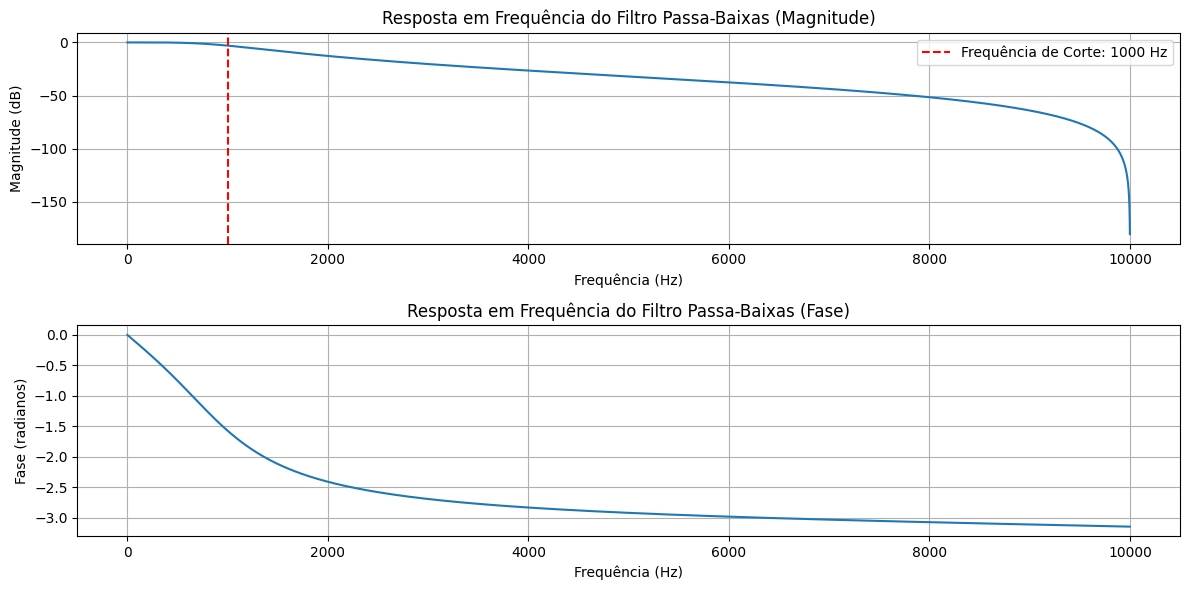

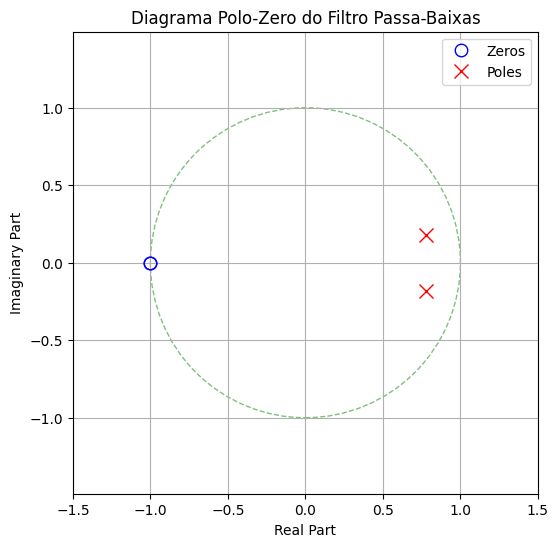

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Normalized cutoff frequency
fc_lp = 1000 # Hz
w_c_lp = 2 * np.pi * fc_lp / fs

# Design a second-order Butterworth low-pass filter
# For digital filters, 'wn' is the normalized cutoff frequency (0 to 1, where 1 is Nyquist freq)
# wn = fc / (fs / 2)
wn_lp = fc_lp / (fs / 2)
b_lp, a_lp = signal.butter(2, wn_lp, btype='low', analog=False)

print("Transfer Function Coefficients (b, a) for Low-Pass Filter:")
print(f"b: {b_lp}")
print(f"a: {a_lp}")

# Frequency response
w_lp, h_lp = signal.freqz(b_lp, a_lp, worN=8000)
freq_lp = w_lp * fs / (2 * np.pi) # Convert angular frequency to Hz

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(freq_lp, 20 * np.log10(abs(h_lp)))
plt.title('Resposta em Frequência do Filtro Passa-Baixas (Magnitude)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.axvline(fc_lp, color='r', linestyle='--', label=f'Frequência de Corte: {fc_lp} Hz')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(freq_lp, np.unwrap(np.angle(h_lp)))
plt.title('Resposta em Frequência do Filtro Passa-Baixas (Fase)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (radianos)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Pole-zero diagram
plot_pole_zero(b_lp, a_lp, 'Diagrama Polo-Zero do Filtro Passa-Baixas')

### Normalização do Filtro Passa-Baixas

Conforme solicitado, para um filtro passa-baixas digital de 2ª ordem na forma:

$H(z) = \frac{K(z+1)^2}{z^2 + m_1z + m_2}$

A condição para $H(1)=1$ (ganho unitário em DC) implica que o fator de normalização $K$ é dado por:

$K = \frac{1 + m_1 + m_2}{4}$

Onde $m_1 = a_1$ e $m_2 = a_2$ são os coeficientes do denominador da função de transferência. Vamos verificar se os coeficientes `b_lp` obtidos pela função `signal.butter` já satisfazem essa condição.

In [ ]:
m1 = a_lp[1]
m2 = a_lp[2]

# Calculate the normalization factor K
K_calculated = (1 + m1 + m2) / 4

print(f"Coeficientes do denominador (m1, m2): {m1}, {m2}")
print(f"Fator de Normalização K calculado: {K_calculated:.8f}")
print(f"Coeficientes b_lp originais: {b_lp}")

# Verify if b_lp is already normalized by K
is_normalized = np.allclose(b_lp, [K_calculated, 2 * K_calculated, K_calculated])

if is_normalized:
    print("Os coeficientes 'b_lp' já estão normalizados, com ganho H(1)=1, conforme a fórmula H(z) = K(z+1)² / (z² + m1z + m2).")
else:
    print("Os coeficientes 'b_lp' não correspondem diretamente à forma K(z+1)². Será necessário aplicar a normalização.")
    # If it was not normalized, we would apply:
    # b_lp_normalized = np.array([K_calculated, 2 * K_calculated, K_calculated])
    # print(f"Novos coeficientes b_lp (normalizados): {b_lp_normalized}")

Coeficientes do denominador (m1, m2): -1.5610180758007182, 0.6413515380575631
Fator de Normalização K calculado: 0.02008337
Coeficientes b_lp originais: [0.02008337 0.04016673 0.02008337]
Os coeficientes 'b_lp' já estão normalizados, com ganho H(1)=1, conforme a fórmula H(z) = K(z+1)² / (z² + m1z + m2).


### Efeito da variação do parâmetro 'r'

Para um filtro de segunda ordem geral, a variação de um parâmetro como 'r' (frequentemente relacionado ao fator de amortecimento ou fator Q) influencia a seletividade do corte e a estabilidade. Vamos demonstrar isso variando o fator Q para o projeto do filtro passa-baixas. Um fator Q mais alto resulta em uma transição mais nítida, mas também pode introduzir oscilações ou instabilidade se for muito alto.

Como o `scipy.signal.butter` projeta diretamente para a banda passante mais plana possível, ilustraremos o efeito de 'r' usando uma estrutura canônica de filtro de segunda ordem, ou ajustando um parâmetro que imita o efeito de 'r' no fator Q. Uma função de transferência de seção de segunda ordem comum (biquad) é:

H(z) = (b0 + b1*z^-1 + b2*z^-2) / (1 + a1*z^-1 + a2*z^-2)

Para estabilidade, os polos devem estar dentro do círculo unitário. O parâmetro 'r' frequentemente controla o raio dos polos. Vamos considerar um sistema genérico de segunda ordem e variar um parâmetro que efetivamente muda seu fator Q ou largura de banda.

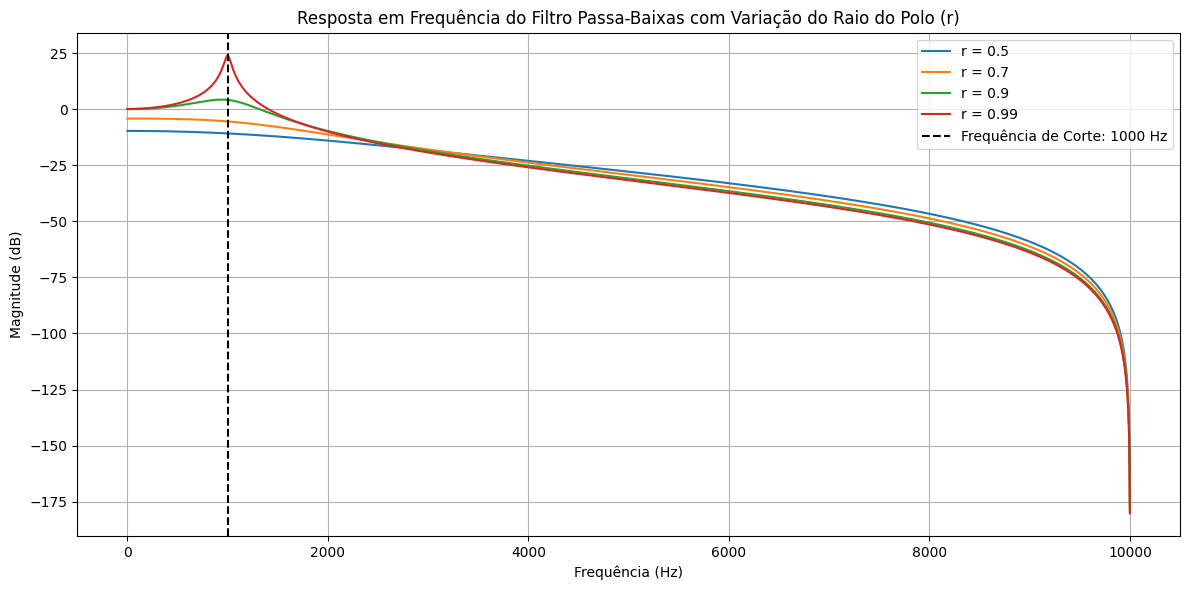

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Definir a frequência de amostragem (fs) para garantir que esteja acessível
fs = 20000  # Hz
fc_lp = 1000 # Hz (definido para esta célula)

# Let's fix theta_0 (related to fc) and vary 'r' (pole radius, 0 < r < 1 for stability).

theta_0 = 2 * np.pi * fc_lp / fs # Resonant frequency in radians
r_biquad_values = [0.5, 0.7, 0.9, 0.99] # Vary 'r' (pole radius)

plt.figure(figsize=(12, 6))
for r_val in r_biquad_values:
    # Biquad coefficients for a simple resonant low-pass (Julius Smith's Biquad cookbook)
    b0 = (1 - np.cos(theta_0)) / 2
    b1 = 1 - np.cos(theta_0)
    b2 = (1 - np.cos(theta_0)) / 2
    a1 = -2 * r_val * np.cos(theta_0)
    a2 = r_val**2

    b_r = [b0, b1, b2]
    a_r = [1, a1, a2]

    w_r, h_r = signal.freqz(b_r, a_r, worN=8000)
    freq_r = w_r * fs / (2 * np.pi)
    plt.plot(freq_r, 20 * np.log10(abs(h_r)), label=f'r = {r_val}')

plt.title('Resposta em Frequência do Filtro Passa-Baixas com Variação do Raio do Polo (r)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.axvline(fc_lp, color='k', linestyle='--', label=f'Frequência de Corte: {fc_lp} Hz')
plt.legend()
plt.tight_layout()
plt.show()

### Comentários sobre os Resultados (Filtro Passa-Baixas com variação de 'r'):

*   **Seletividade:** À medida que o raio do polo `r` se aproxima de 1 (de 0 a 1, pois `r=1` está no círculo unitário), o fator Q do filtro aumenta. Isso torna o filtro mais seletivo, o que significa que ele tem um corte mais nítido e uma banda de transição mais estreita da banda passante para a banda de rejeição. Por outro lado, um valor `r` menor (polos mais próximos da origem) resulta em uma banda de transição mais ampla e menor seletividade.
*   **Estabilidade:** Para um filtro de tempo discreto, a estabilidade requer que todos os polos estejam estritamente dentro do círculo unitário no plano z (ou seja, `|p| < 1`). Na nossa variação de `r`, estamos controlando explicitamente o raio do polo `r`. Enquanto `r < 1`, o filtro permanece estável. Se `r` fosse igual ou maior que 1, o filtro se tornaria instável, levando a uma saída ilimitada para uma entrada limitada.
*   **Largura de Banda:** Para um filtro passa-baixas, um fator Q mais alto (à medida que `r` se aproxima de 1) leva a uma largura de banda mais estreita em torno da frequência de corte. A resposta em magnitude exibe um pico mais nítido logo antes da frequência de corte, indicando um comportamento mais ressonante. Um fator Q mais baixo (menor `r`) resulta em uma resposta mais ampla e menos ressonante.

## (b) Projeto de Filtro Passa-Altas

**Parâmetros:**
*   Frequência de Corte (fc): 2000 Hz
*   Bloco componente básico de segunda ordem

Transfer Function Coefficients (b, a) for High-Pass Filter:
b: [ 0.63894553 -1.27789105  0.63894553]
a: [ 1.        -1.1429805  0.4128016]


/tmp/ipykernel_1015/4080629750.py:22: RuntimeWarning: divide by zero encountered in log10
  plt.plot(freq_hp, 20 * np.log10(abs(h_hp)))


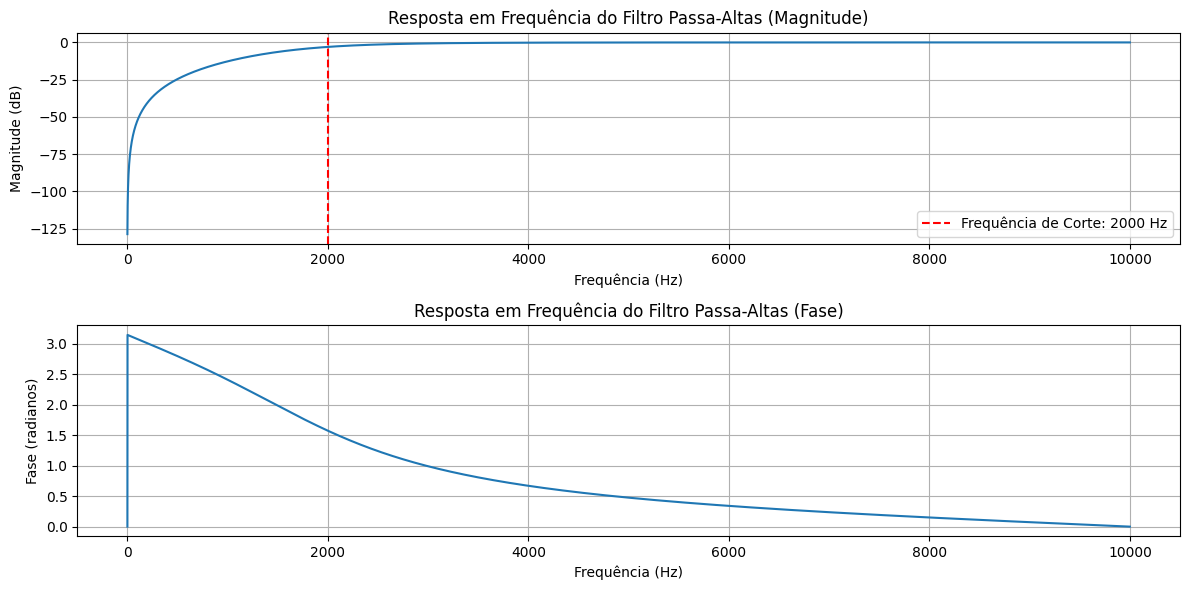

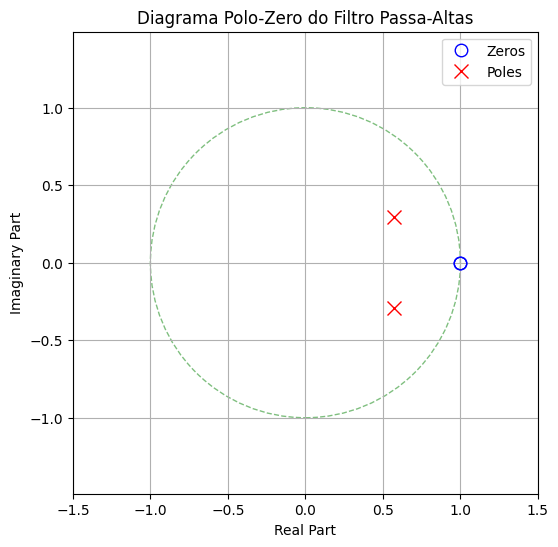

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Normalized cutoff frequency for High-Pass
fc_hp = 2000 # Hz
wn_hp = fc_hp / (fs / 2)

# Design a second-order Butterworth high-pass filter
b_hp, a_hp = signal.butter(2, wn_hp, btype='high', analog=False)

print("Transfer Function Coefficients (b, a) for High-Pass Filter:")
print(f"b: {b_hp}")
print(f"a: {a_hp}")

# Frequency response
w_hp, h_hp = signal.freqz(b_hp, a_hp, worN=8000)
freq_hp = w_hp * fs / (2 * np.pi) # Convert angular frequency to Hz

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(freq_hp, 20 * np.log10(abs(h_hp)))
plt.title('Resposta em Frequência do Filtro Passa-Altas (Magnitude)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.axvline(fc_hp, color='r', linestyle='--', label=f'Frequência de Corte: {fc_hp} Hz')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(freq_hp, np.unwrap(np.angle(h_hp)))
plt.title('Resposta em Frequência do Filtro Passa-Altas (Fase)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (radianos)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Pole-zero diagram
plot_pole_zero(b_hp, a_hp, 'Diagrama Polo-Zero do Filtro Passa-Altas')

/tmp/ipykernel_2286/1600289176.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.plot(freq_r_hp, 20 * np.log10(abs(h_r_hp)), label=f'r = {r_val}')


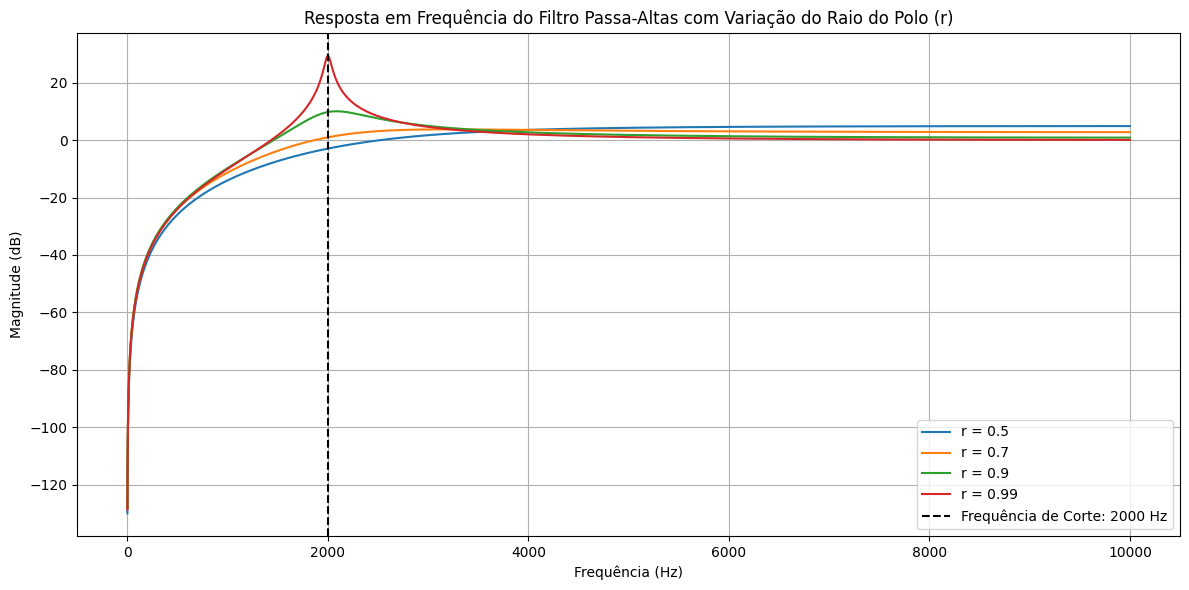

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000 # Hz (definido para esta célula)
fc_hp = 2000 # Hz (definido para esta célula)

theta_0_hp = 2 * np.pi * fc_hp / fs # Resonant frequency in radians for HP
r_biquad_values_hp = [0.5, 0.7, 0.9, 0.99] # Vary 'r' (pole radius)

plt.figure(figsize=(12, 6))
for r_val in r_biquad_values_hp:
    # High-pass filter coefficients (from Julius Smith's Biquad cookbook)
    b0_hp = (1 + np.cos(theta_0_hp)) / 2
    b1_hp = -(1 + np.cos(theta_0_hp))
    b2_hp = (1 + np.cos(theta_0_hp)) / 2
    a1_hp = -2 * r_val * np.cos(theta_0_hp)
    a2_hp = r_val**2

    b_r_hp = [b0_hp, b1_hp, b2_hp]
    a_r_hp = [1, a1_hp, a2_hp]

    w_r_hp, h_r_hp = signal.freqz(b_r_hp, a_r_hp, worN=8000)
    freq_r_hp = w_r_hp * fs / (2 * np.pi)
    plt.plot(freq_r_hp, 20 * np.log10(abs(h_r_hp)), label=f'r = {r_val}')

plt.title('Resposta em Frequência do Filtro Passa-Altas com Variação do Raio do Polo (r)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.axvline(fc_hp, color='k', linestyle='--', label=f'Frequência de Corte: {fc_hp} Hz')
plt.legend()
plt.tight_layout()
plt.show()

### Comentários sobre os Resultados (Filtro Passa-Altas com variação de 'r'):

*   **Seletividade:** Semelhante ao caso passa-baixas, à medida que o raio do polo `r` se aproxima de 1 (de 0 a 1), o filtro passa-altas se torna mais seletivo. Isso significa uma transição mais nítida da banda de rejeição para a banda passante e, potencialmente, um pico mais pronunciado perto da frequência de corte (se o Q for alto).
*   **Estabilidade:** A condição para estabilidade permanece a mesma: todos os polos devem estar estritamente dentro do círculo unitário (`|p| < 1`). Enquanto o `r` escolhido for menor que 1, o filtro será estável. Valores de `r >= 1` levariam à instabilidade.
*   **Largura de Banda:** Para um filtro passa-altas, um `r` maior (mais próximo de 1) geralmente leva a uma banda de transição mais estreita e um corte mais nítido. Se ocorrer ressonância devido a um Q alto, será logo após a frequência de corte. Um `r` menor resulta em uma transição mais suave e ampla.

## (c) Projeto e Análise de Filtro Passa-Faixa

**Parameters:**
*   Center Frequency (fc): 7000 Hz
*   Second-order basic component block

In [ ]:
import numpy as np
from scipy import signal

# 1. Definir frequência de amostragem e frequência central
fs = 20000  # Hz
fc = 7000   # Hz

# Converter a frequência central analógica para frequência digital (radianos/amostra)
theta_c = 2 * np.pi * fc / fs

print(f"Frequência de Amostragem (fs): {fs} Hz")
print(f"Frequência Central (fc): {fc} Hz")
print(f"Frequência Central Digital (theta_c): {theta_c:.4f} radianos/amostra ({(theta_c / (2*np.pi)) * fs:.2f} Hz)")

Frequência de Amostragem (fs): 20000 Hz
Frequência Central (fc): 7000 Hz
Frequência Central Digital (theta_c): 2.1991 radianos/amostra (7000.00 Hz)


### Função de Transferência do Filtro

A forma geral para um filtro passa-faixa de segunda ordem com zeros em DC e Nyquist é:
$H(z) = K \frac{z^2 - 1}{z^2 + m_1 z + m_2}$

Onde o denominador pode ser expresso em termos do raio do polo $r$ e da frequência central digital $\theta_c$ como:
$z^2 - 2r \cos(\theta_c) z + r^2$

Então, temos:
$m_1 = -2r \cos(\theta_c)$
$m_2 = r^2$

O parâmetro $K$ é um fator de ganho para obter ganho unitário na frequência central.

In [ ]:
# 2. Calcular coeficientes do filtro para um 'r' padrão

# 'r' controla a largura de banda e a seletividade. Para estabilidade, 0 < r < 1.
# Um valor mais próximo de 1 resulta em uma largura de banda mais estreita.
r_default = 0.95 # Vamos começar com um valor para r

m1 = -2 * r_default * np.cos(theta_c)
m2 = r_default**2

# Coeficientes do numerador
b = [1, 0, -1] # De (z^2 - 1)

# Coeficientes do denominador
a = [1, m1, m2]

# Calcular K para ganho unitário na frequência central (theta_c)
# Avaliar H(z) em z = exp(j*theta_c) e encontrar o ganho
omega, h = signal.freqz(b, a, worN=[theta_c])
gain_at_fc = np.abs(h[0])
K = 1 / gain_at_fc

# Aplicar K aos coeficientes do numerador
b_scaled = [K * val for val in b]

print(f"r (raio do polo): {r_default}")
print(f"m1: {m1:.4f}")
print(f"m2: {m2:.4f}")
print(f"K (fator de ganho): {K:.4f}")
print(f"Coeficientes do numerador (b): {np.array(b_scaled)}")
print(f"Coeficientes do denominador (a): {np.array(a)}")

r (raio do polo): 0.95
m1: 1.1168
m2: 0.9025
K (fator de ganho): 0.0488
Coeficientes do numerador (b): [ 0.04875846  0.         -0.04875846]
Coeficientes do denominador (a): [1.         1.11679198 0.9025    ]


### Resposta em Frequência

A resposta em frequência mostra como o filtro amplifica ou atenua diferentes frequências.

/tmp/ipykernel_4120/1232223265.py:9: RuntimeWarning: divide by zero encountered in log10
  axs[0].plot(w * fs / (2 * np.pi), 20 * np.log10(abs(H)))


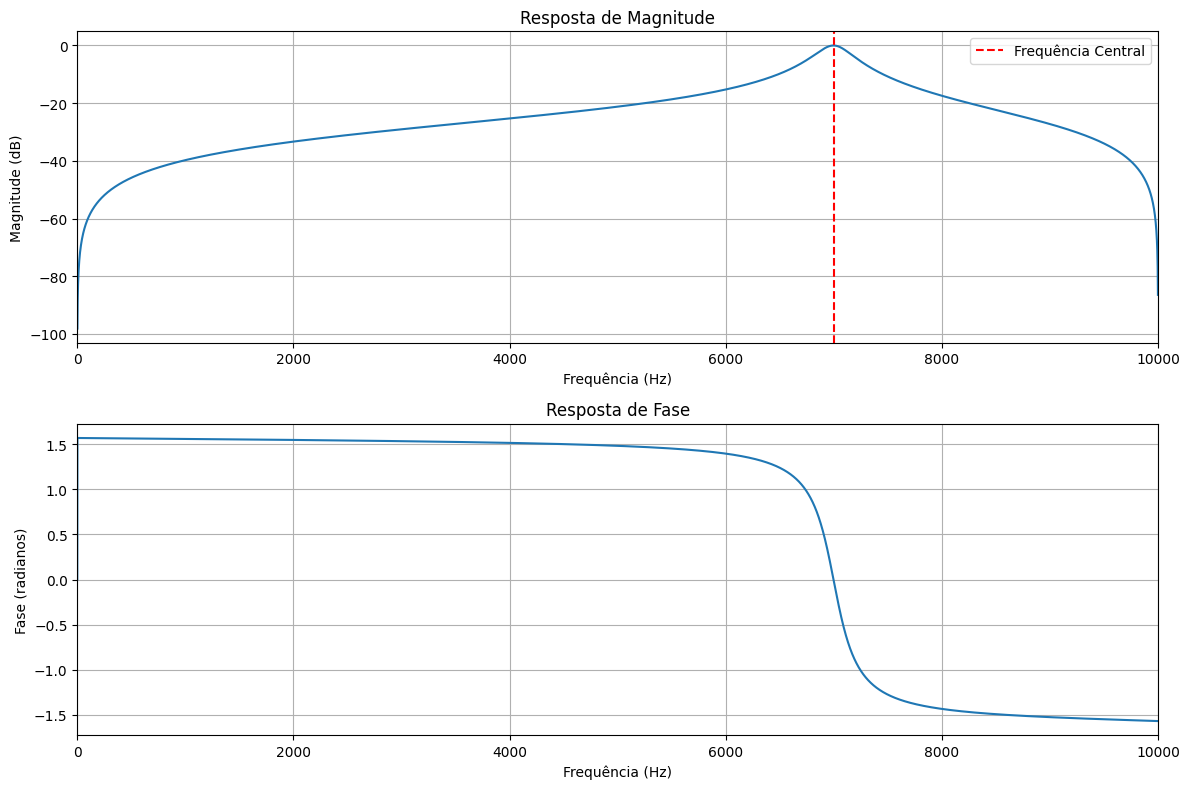

In [ ]:
# 3. Plotar a resposta em frequência

# Calcular a resposta em frequência para uma faixa mais ampla de frequências
w, H = signal.freqz(b_scaled, a, worN=8192)

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Resposta de Magnitude
axs[0].plot(w * fs / (2 * np.pi), 20 * np.log10(abs(H)))
axs[0].set_title('Resposta de Magnitude')
axs[0].set_xlabel('Frequência (Hz)')
axs[0].set_ylabel('Magnitude (dB)')
axs[0].set_xlim(0, fs / 2)
axs[0].grid(True)
axs[0].axvline(fc, color='red', linestyle='--', label='Frequência Central')
axs[0].legend()

# Resposta de Fase
axs[1].plot(w * fs / (2 * np.pi), np.angle(H))
axs[1].set_title('Resposta de Fase')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Fase (radianos)')
axs[1].set_xlim(0, fs / 2)
axs[1].grid(True)

plt.tight_layout()
plt.show()

### Diagrama de Polos e Zeros

O diagrama de polos e zeros representa visualmente a estabilidade do filtro e suas características de frequência. Polos dentro do círculo unitário indicam estabilidade.

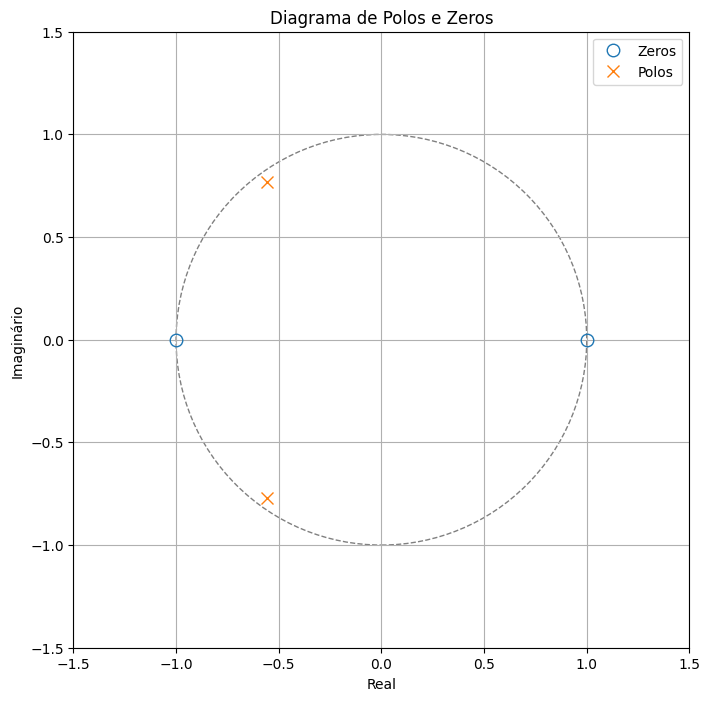

O filtro é estável, pois todos os polos estão dentro do círculo unitário.


In [ ]:
# 4. Plotar o diagrama de polos e zeros

# Encontrar as raízes do numerador (zeros) e denominador (polos)
zeros = np.roots(b_scaled)
poles = np.roots(a)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1)

# Plotar círculo unitário
unit_circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False)
ax.add_artist(unit_circle)

# Plotar zeros
ax.plot(zeros.real, zeros.imag, 'o', markersize=9, label='Zeros', fillstyle='none')

# Plotar polos
ax.plot(poles.real, poles.imag, 'x', markersize=9, label='Polos')

ax.set_title('Diagrama de Polos e Zeros')
ax.set_xlabel('Real')
ax.set_ylabel('Imaginário')
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_aspect('equal', adjustable='box')
ax.grid(True)
ax.legend()
plt.show()

# Verificar estabilidade
if np.all(np.abs(poles) < 1):
    print("O filtro é estável, pois todos os polos estão dentro do círculo unitário.")
else:
    print("O filtro é instável, pois um ou mais polos estão fora do círculo unitário.")

### Efeito da Variação do Parâmetro 'r'

O parâmetro 'r' (raio do polo) impacta significativamente a largura de banda e a seletividade do filtro. À medida que 'r' se aproxima de 1, os polos se movem para mais perto do círculo unitário, resultando em um filtro mais nítido e seletivo, com uma largura de banda mais estreita. Por outro lado, à medida que 'r' diminui, os polos se movem para mais perto da origem, levando a uma largura de banda mais ampla e um filtro menos seletivo.

/tmp/ipykernel_4120/1722141131.py:20: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w_var * fs / (2 * np.pi), 20 * np.log10(abs(H_var)), label=f'r = {r_val}')


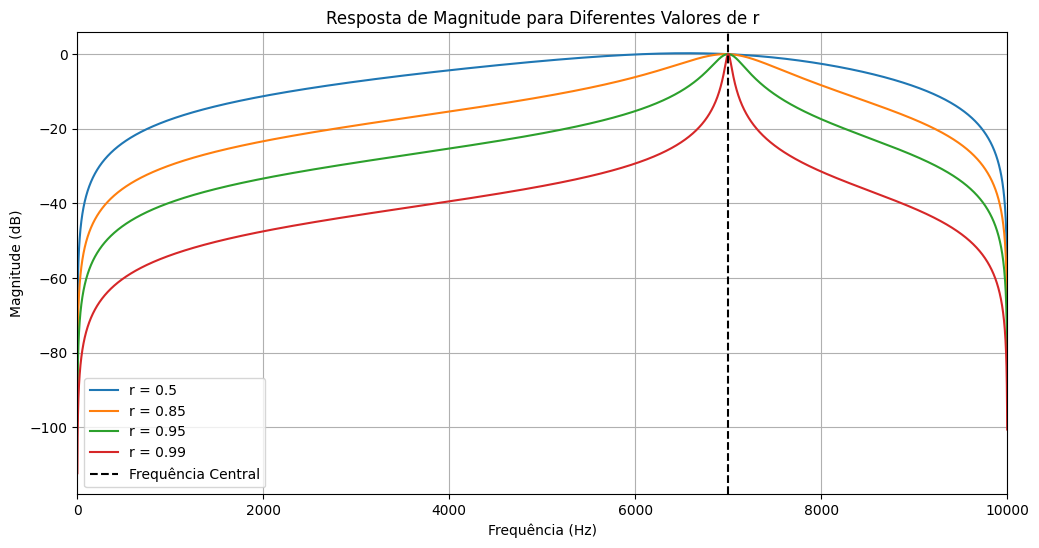

In [ ]:
# 5. Investigar o efeito da variação de 'r'

r_values = [0.5, 0.85, 0.95, 0.99]

plt.figure(figsize=(12, 6))

for r_val in r_values:
    m1_var = -2 * r_val * np.cos(theta_c)
    m2_var = r_val**2

    a_var = [1, m1_var, m2_var]

    # Calcular K para ganho unitário em theta_c para cada r_val
    omega_var, h_var = signal.freqz(b, a_var, worN=[theta_c])
    gain_at_fc_var = np.abs(h_var[0])
    K_var = 1 / gain_at_fc_var
    b_scaled_var = [K_var * val for val in b]

    w_var, H_var = signal.freqz(b_scaled_var, a_var, worN=8192)
    plt.plot(w_var * fs / (2 * np.pi), 20 * np.log10(abs(H_var)), label=f'r = {r_val}')

plt.title('Resposta de Magnitude para Diferentes Valores de r')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim(0, fs / 2)
plt.grid(True)
plt.axvline(fc, color='black', linestyle='--', label='Frequência Central')
plt.legend()
plt.show()

### Resumo e Comentários

**Seletividade:** Conforme observado no gráfico variando 'r', um valor maior de 'r' (mais próximo de 1) leva a uma região passa-faixa mais estreita, indicando maior seletividade. O filtro se torna mais eficaz em isolar frequências próximas à frequência central e atenuar outras.

**Estabilidade:** Para um filtro IIR, a estabilidade é determinada pela localização de seus polos. Todos os polos devem estar estritamente dentro do círculo unitário no plano z. Em nosso projeto, como `r < 1`, os polos são garantidos como estando dentro do círculo unitário, garantindo a estabilidade do filtro. Se `r` fosse maior ou igual a 1, o filtro seria instável.

**Largura de Banda:** A largura de banda do filtro é inversamente relacionada a 'r'. Um 'r' maior (polos mais próximos do círculo unitário) resulta em uma largura de banda menor, o que significa que o filtro passa uma faixa mais estreita de frequências. Por outro lado, um 'r' menor produz uma largura de banda mais ampla. A escolha de 'r' é um compromisso entre seletividade (largura de banda estreita) e resposta transitória (menor oscilação).

**Ganho:** O fator $K$ garante que o filtro tenha ganho unitário (0 dB) em sua frequência central, permitindo que o sinal da banda passante seja transmitido sem amplificação ou atenuação na frequência de projeto.

## Questão 1d: Projeto de Filtro Notch

Nesta seção, projetaremos um filtro Notch de 2ª ordem com frequência central de 3000 Hz, utilizando a função de transferência fornecida, e analisaremos suas características.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Definir parâmetros para o filtro Notch
fs_notch = 20000  # Frequência de amostragem em Hz
fc_notch = 3000   # Frequência central do notch em Hz

# Converter a frequência central analógica para frequência digital (radianos/amostra)
theta_c_notch = 2 * np.pi * fc_notch / fs_notch

print(f"Frequência de Amostragem (fs): {fs_notch} Hz")
print(f"Frequência Central do Notch (fc): {fc_notch} Hz")
print(f"Frequência Central Digital do Notch (theta_c): {theta_c_notch:.4f} radianos/amostra ({(theta_c_notch / (2*np.pi)) * fs_notch:.2f} Hz)")

Frequência de Amostragem (fs): 20000 Hz
Frequência Central do Notch (fc): 3000 Hz
Frequência Central Digital do Notch (theta_c): 0.9425 radianos/amostra (3000.00 Hz)


### Função de Transferência do Filtro Notch

A função de transferência do filtro Notch será interpretada como:
$H(z) = K \frac{z^2 - 2\cos(\theta_c) z + 1}{z^2 - 2r \cos(\theta_c) z + r^2}$

Onde:
*   Os zeros no numerador estão na frequência Notch no círculo unitário ($e^{\pm j\theta_c}$).
*   Os polos no denominador estão ligeiramente dentro do círculo unitário na frequência Notch ($re^{\pm j\theta_c}$), com $r < 1$.
*   O parâmetro $K$ é um fator de ganho para obter ganho unitário fora da banda de rejeição (e.g., em DC).

In [ ]:
# 2. Calcular coeficientes do filtro Notch

# 'r' controla a largura da banda de rejeição. Para estabilidade, 0 < r < 1.
# Um valor mais próximo de 1 resulta em uma banda de rejeição mais estreita.
r_notch = 0.95 # Valor padrão para r

# Coeficientes do numerador (zeros na frequência do notch no círculo unitário)
b_notch = [1, -2 * np.cos(theta_c_notch), 1]

# Coeficientes do denominador (polos dentro do círculo unitário na frequência do notch)
a_notch = [1, -2 * r_notch * np.cos(theta_c_notch), r_notch**2]

# Calcular K para ganho unitário em DC (z=1)
# H(1) = K * (1 - 2*cos(theta_c) + 1) / (1 - 2*r*cos(theta_c) + r^2) = 1
# K = (1 - 2*r*cos(theta_c) + r^2) / (2 - 2*cos(theta_c))

# Evitar divisão por zero se theta_c for 0 ou 2*pi (DC)
# Para um notch em 3000 Hz, theta_c não será 0.
if (2 - 2 * np.cos(theta_c_notch)) == 0:
    K_notch = 1.0 # Em caso de notch em DC, o ganho em DC já seria zero
else:
    K_notch = (1 - 2 * r_notch * np.cos(theta_c_notch) + r_notch**2) / (2 - 2 * np.cos(theta_c_notch))

# Aplicar K aos coeficientes do numerador
b_notch_scaled = [K_notch * val for val in b_notch]

print(f"r (raio do polo para Notch): {r_notch}")
print(f"K (fator de ganho para Notch): {K_notch:.4f}")
print(f"Coeficientes do numerador (b_notch): {np.array(b_notch_scaled)}")
print(f"Coeficientes do denominador (a_notch): {np.array(a_notch)}")

r (raio do polo para Notch): 0.95
K (fator de ganho para Notch): 0.9530
Coeficientes do numerador (b_notch): [ 0.9530324  -1.12035678  0.9530324 ]
Coeficientes do denominador (a_notch): [ 1.         -1.11679198  0.9025    ]


### Resposta em Frequência do Filtro Notch

Vamos visualizar a resposta de magnitude e fase do filtro Notch.

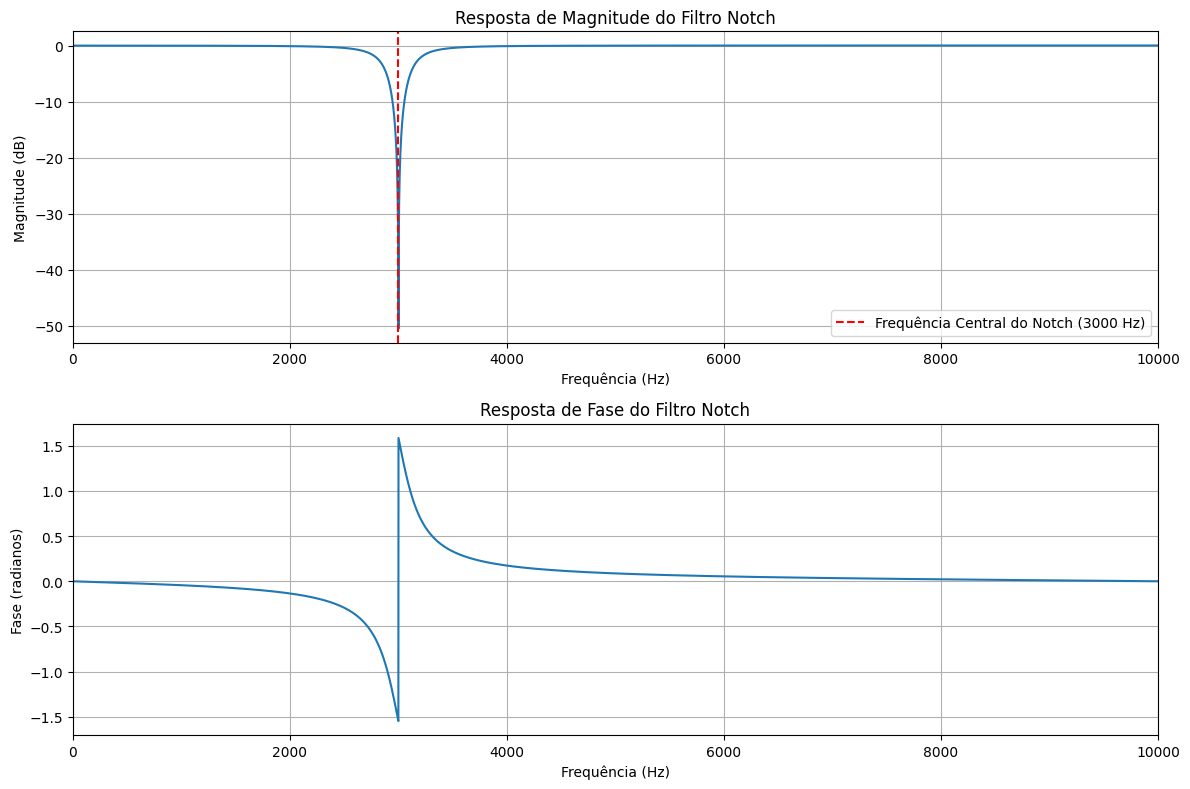

In [ ]:
# 3. Plotar a resposta em frequência do filtro Notch

w_notch, H_notch = signal.freqz(b_notch_scaled, a_notch, worN=8192)

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Resposta de Magnitude
axs[0].plot(w_notch * fs_notch / (2 * np.pi), 20 * np.log10(abs(H_notch)))
axs[0].set_title('Resposta de Magnitude do Filtro Notch')
axs[0].set_xlabel('Frequência (Hz)')
axs[0].set_ylabel('Magnitude (dB)')
axs[0].set_xlim(0, fs_notch / 2)
axs[0].grid(True)
axs[0].axvline(fc_notch, color='red', linestyle='--', label=f'Frequência Central do Notch ({fc_notch} Hz)')
axs[0].legend()

# Resposta de Fase
axs[1].plot(w_notch * fs_notch / (2 * np.pi), np.angle(H_notch))
axs[1].set_title('Resposta de Fase do Filtro Notch')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Fase (radianos)')
axs[1].set_xlim(0, fs_notch / 2)
axs[1].grid(True)

plt.tight_layout()
plt.show()

### Diagrama de Polos e Zeros do Filtro Notch

Vamos analisar a localização dos polos e zeros do filtro Notch.

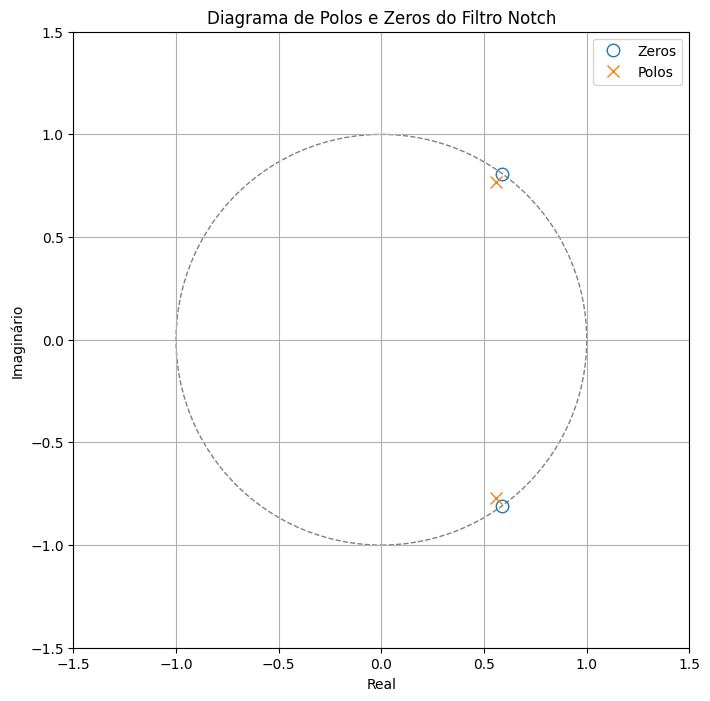

O filtro Notch é estável, pois todos os polos estão dentro do círculo unitário.


In [ ]:
# 4. Plotar o diagrama de polos e zeros do filtro Notch

zeros_notch = np.roots(b_notch_scaled)
poles_notch = np.roots(a_notch)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1)

unit_circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False)
ax.add_artist(unit_circle)

ax.plot(zeros_notch.real, zeros_notch.imag, 'o', markersize=9, label='Zeros', fillstyle='none')
ax.plot(poles_notch.real, poles_notch.imag, 'x', markersize=9, label='Polos')

ax.set_title('Diagrama de Polos e Zeros do Filtro Notch')
ax.set_xlabel('Real')
ax.set_ylabel('Imaginário')
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_aspect('equal', adjustable='box')
ax.grid(True)
ax.legend()
plt.show()

if np.all(np.abs(poles_notch) < 1):
    print("O filtro Notch é estável, pois todos os polos estão dentro do círculo unitário.")
else:
    print("O filtro Notch é instável, pois um ou mais polos estão fora do círculo unitário.")

### Efeito da Variação do Parâmetro 'r' no Filtro Notch

No filtro Notch, o parâmetro 'r' (raio do polo) controla diretamente a *largura de banda da rejeição*. Quanto mais próximo 'r' estiver de 1, mais estreita e profunda será a rejeição na frequência central. Quanto menor 'r' for, mais larga e menos profunda será a banda de rejeição.

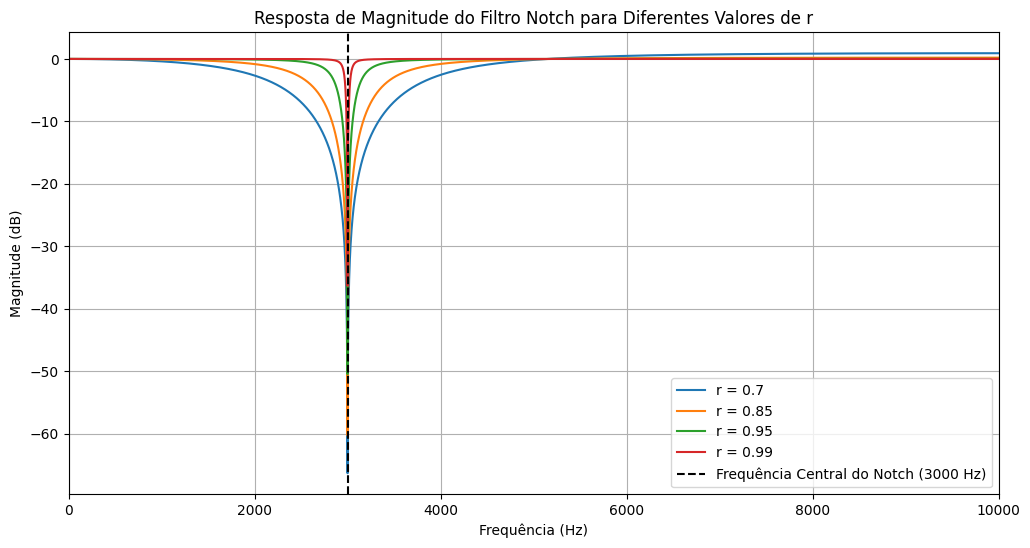

In [ ]:
# 5. Investigar o efeito da variação de 'r' no filtro Notch

r_notch_values = [0.7, 0.85, 0.95, 0.99]

plt.figure(figsize=(12, 6))

for r_val in r_notch_values:
    # Coeficientes do denominador para o r atual
    a_notch_var = [1, -2 * r_val * np.cos(theta_c_notch), r_val**2]

    # Calcular K para ganho unitário em DC para o r atual
    if (2 - 2 * np.cos(theta_c_notch)) == 0:
        K_notch_var = 1.0
    else:
        K_notch_var = (1 - 2 * r_val * np.cos(theta_c_notch) + r_val**2) / (2 - 2 * np.cos(theta_c_notch))

    # Aplicar K aos coeficientes do numerador
    b_notch_scaled_var = [K_notch_var * val for val in b_notch]

    w_notch_var, H_notch_var = signal.freqz(b_notch_scaled_var, a_notch_var, worN=8192)
    plt.plot(w_notch_var * fs_notch / (2 * np.pi), 20 * np.log10(abs(H_notch_var)), label=f'r = {r_val}')

plt.title('Resposta de Magnitude do Filtro Notch para Diferentes Valores de r')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim(0, fs_notch / 2)
plt.grid(True)
plt.axvline(fc_notch, color='black', linestyle='--', label=f'Frequência Central do Notch ({fc_notch} Hz)')
plt.legend()
plt.show()

### Comentários sobre os Resultados do Filtro Notch

**Seletividade:** O filtro Notch é projetado para ser altamente seletivo, rejeitando uma banda de frequência específica (a frequência central do Notch) enquanto passa as outras frequências. A seletividade é fortemente influenciada pelo parâmetro `r`. Valores de `r` mais próximos de 1 resultam em um Notch mais estreito e profundo, indicando maior seletividade.

**Estabilidade:** Assim como nos filtros passa-faixas da Questão 1, a estabilidade do filtro Notch é garantida se todos os polos estiverem dentro do círculo unitário. Como `r` é escolhido como um valor entre 0 e 1, os polos do denominador estão sempre dentro do círculo unitário, assegurando a estabilidade do filtro.

**Largura de Banda:** A largura de banda, neste contexto, refere-se à largura da banda de rejeição. Um `r` maior produz uma largura de banda de rejeição menor (um Notch mais 'fino'). Um `r` menor resulta em uma largura de banda de rejeição maior (um Notch mais 'amplo'). A escolha de `r` depende da necessidade de rejeitar uma frequência muito específica ou uma faixa maior.

**Ganho:** O fator `K` é ajustado para garantir que o ganho do filtro seja unitário (0 dB) nas frequências fora da banda de rejeição, como em DC. Isso significa que as frequências que não são afetadas pelo Notch passam sem atenuação ou amplificação, garantindo a integridade do sinal fora da banda de rejeição.

## Questão 2: Projeto de Filtro Passa-Faixas em Cascata

Nesta questão, projetaremos um filtro passa-faixas usando uma cascata de dois blocos de segunda ordem (um passa-altas e um passa-baixas) com frequências de corte especificadas. Analisaremos sua resposta em frequência, diagrama de polos e zeros, e faremos uma comparação com o filtro da Questão 1.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Definir parâmetros para o filtro em cascata
fs = 20000  # Frequência de amostragem em Hz (igual à Q1)
fc1 = 6000  # Frequência de corte inferior para o passa-altas em Hz
fc2 = 8000  # Frequência de corte superior para o passa-baixas em Hz

print(f"Frequência de Amostragem (fs): {fs} Hz")
print(f"Frequência de Corte Inferior (fc1): {fc1} Hz")
print(f"Frequência de Corte Superior (fc2): {fc2} Hz")

Frequência de Amostragem (fs): 20000 Hz
Frequência de Corte Inferior (fc1): 6000 Hz
Frequência de Corte Superior (fc2): 8000 Hz


### Projeto dos Blocos Componentes (Passa-Altas e Passa-Baixas)

Para formar um filtro passa-faixas entre `fc1` e `fc2` utilizando uma cascata de blocos de 2ª ordem, projetaremos um filtro passa-altas de 2ª ordem com frequência de corte `fc1` e um filtro passa-baixas de 2ª ordem com frequência de corte `fc2`. Utilizaremos o tipo Butterworth para os filtros, que são um tipo comum de 'blocos componentes básicos'.

In [ ]:
# 2. Projetar Filtro Passa-Altas (HPF) de 2ª ordem com fc1
#    e Filtro Passa-Baixas (LPF) de 2ª ordem com fc2

# Ordem do filtro (2 para cada bloco)
order = 2

# Coeficientes do filtro Passa-Altas
# wn é a frequência de corte normalizada (Nyquist é 1)
b_hp, a_hp = signal.butter(order, fc1, btype='highpass', fs=fs, output='ba')

print(f"Coeficientes do Numerador HPF (b_hp): {b_hp}")
print(f"Coeficientes do Denominador HPF (a_hp): {a_hp}\n")

# Coeficientes do filtro Passa-Baixas
b_lp, a_lp = signal.butter(order, fc2, btype='lowpass', fs=fs, output='ba')

print(f"Coeficientes do Numerador LPF (b_lp): {b_lp}")
print(f"Coeficientes do Denominador LPF (a_lp): {a_lp}")

Coeficientes do Numerador HPF (b_hp): [ 0.20657208 -0.41314417  0.20657208]
Coeficientes do Denominador HPF (a_hp): [1.         0.36952738 0.19581571]

Coeficientes do Numerador LPF (b_lp): [0.63894553 1.27789105 0.63894553]
Coeficientes do Denominador LPF (a_lp): [1.        1.1429805 0.4128016]


### Cascateamento dos Filtros

Para obter a função de transferência do filtro passa-faixas resultante, convoluímos os coeficientes do numerador e do denominador dos filtros passa-altas e passa-baixas.

In [ ]:
# 3. Cascatear os dois filtros

b_cascata = np.convolve(b_hp, b_lp)
a_cascata = np.convolve(a_hp, a_lp)

print(f"Coeficientes do Numerador do Filtro em Cascata (b_cascata): {b_cascata}")
print(f"Coeficientes do Denominador do Filtro em Cascata (a_cascata): {a_cascata}")

Coeficientes do Numerador do Filtro em Cascata (b_cascata): [ 0.13198831  0.         -0.26397662  0.          0.13198831]
Coeficientes do Denominador do Filtro em Cascata (a_cascata): [1.         1.51250788 1.0309799  0.37635503 0.08083304]


### Resposta em Frequência do Filtro em Cascata

Vamos visualizar a resposta de magnitude e fase do filtro passa-faixas resultante.

/tmp/ipykernel_4120/2834712048.py:8: RuntimeWarning: divide by zero encountered in log10
  axs[0].plot(w_cascata * fs / (2 * np.pi), 20 * np.log10(abs(H_cascata)))


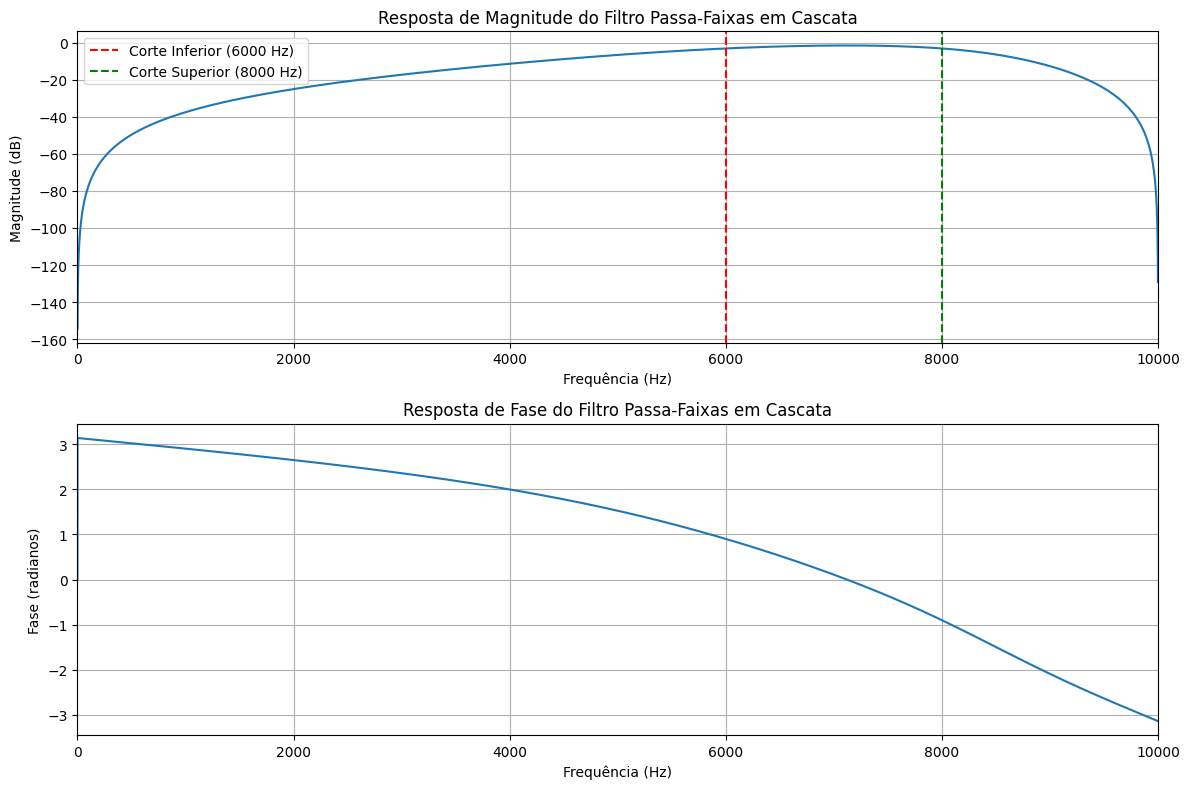

In [ ]:
# 4. Plotar a resposta em frequência do filtro em cascata

w_cascata, H_cascata = signal.freqz(b_cascata, a_cascata, worN=8192)

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Resposta de Magnitude
axs[0].plot(w_cascata * fs / (2 * np.pi), 20 * np.log10(abs(H_cascata)))
axs[0].set_title('Resposta de Magnitude do Filtro Passa-Faixas em Cascata')
axs[0].set_xlabel('Frequência (Hz)')
axs[0].set_ylabel('Magnitude (dB)')
axs[0].set_xlim(0, fs / 2)
axs[0].grid(True)
axs[0].axvline(fc1, color='red', linestyle='--', label=f'Corte Inferior ({fc1} Hz)')
axs[0].axvline(fc2, color='green', linestyle='--', label=f'Corte Superior ({fc2} Hz)')
axs[0].legend()

# Resposta de Fase
axs[1].plot(w_cascata * fs / (2 * np.pi), np.angle(H_cascata))
axs[1].set_title('Resposta de Fase do Filtro Passa-Faixas em Cascata')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Fase (radianos)')
axs[1].set_xlim(0, fs / 2)
axs[1].grid(True)

plt.tight_layout()
plt.show()

### Diagrama de Polos e Zeros do Filtro em Cascata

Vamos analisar a localização dos polos e zeros do filtro combinado para verificar sua estabilidade e características.

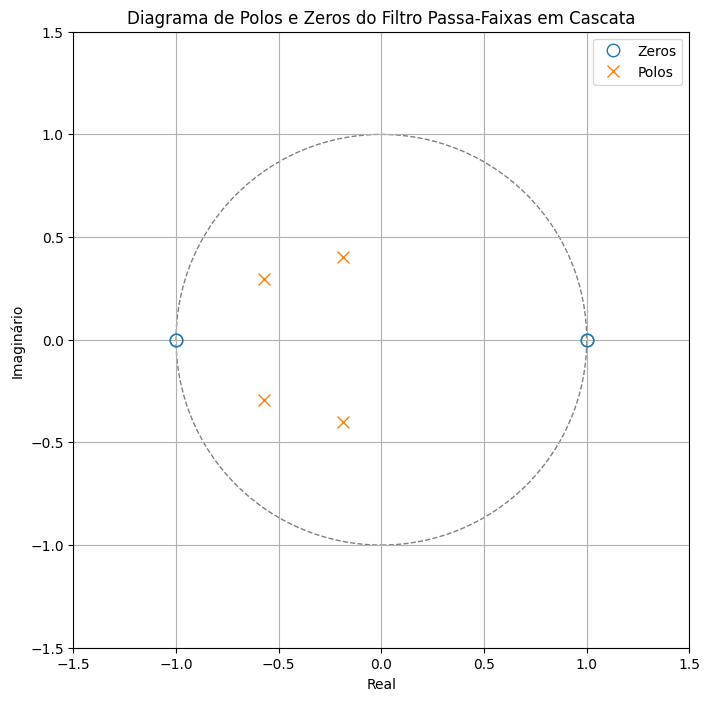

O filtro em cascata é estável, pois todos os polos estão dentro do círculo unitário.


In [ ]:
# 5. Plotar o diagrama de polos e zeros do filtro em cascata

zeros_cascata = np.roots(b_cascata)
poles_cascata = np.roots(a_cascata)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1)

unit_circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False)
ax.add_artist(unit_circle)

ax.plot(zeros_cascata.real, zeros_cascata.imag, 'o', markersize=9, label='Zeros', fillstyle='none')
ax.plot(poles_cascata.real, poles_cascata.imag, 'x', markersize=9, label='Polos')

ax.set_title('Diagrama de Polos e Zeros do Filtro Passa-Faixas em Cascata')
ax.set_xlabel('Real')
ax.set_ylabel('Imaginário')
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_aspect('equal', adjustable='box')
ax.grid(True)
ax.legend()
plt.show()

if np.all(np.abs(poles_cascata) < 1):
    print("O filtro em cascata é estável, pois todos os polos estão dentro do círculo unitário.")
else:
    print("O filtro em cascata é instável, pois um ou mais polos estão fora do círculo unitário.")

### Comparação e Comentários (Filtro da Questão 1 vs. Filtro em Cascata da Questão 2)

**Filtro da Questão 1 (2ª Ordem Band-Pass):**
*   **Forma:** Utiliza a função de transferência $H(z)=K(z²-1)/(z²+m1z+m2)$, que já é intrinsecamente um filtro passa-faixas com zeros em DC e Nyquist.
*   **Parâmetro 'r':** A seletividade e largura de banda são controladas pelo parâmetro `r` (raio do polo). Valores de `r` mais próximos de 1 resultam em filtros mais seletivos e de largura de banda mais estreita.
*   **Ordem:** É um filtro de 2ª ordem.
*   **Largura de Banda:** Definida indiretamente pela frequência central e pelo `r`.
*   **Estabilidade:** Garante estabilidade se `r < 1`.

**Filtro da Questão 2 (4ª Ordem Passa-Faixas em Cascata):**
*   **Forma:** É uma cascata de um filtro passa-altas de 2ª ordem (com corte `fc1`) e um filtro passa-baixas de 2ª ordem (com corte `fc2`). O filtro resultante é de 4ª ordem.
*   **Seletividade e Largura de Banda:** A largura de banda é diretamente definida pelas frequências de corte `fc1` e `fc2`. Como é um filtro de 4ª ordem (cascata de dois filtros de 2ª ordem), ele geralmente apresenta uma transição mais abrupta e, portanto, maior seletividade do que um único filtro passa-faixas de 2ª ordem com a mesma largura de banda central.
*   **Ordem:** É um filtro de 4ª ordem (soma das ordens dos blocos cascateados).
*   **Estabilidade:** Filtros Butterworth são intrinsecamente estáveis, com todos os polos dentro do círculo unitário. A cascata de filtros estáveis resulta em um filtro estável.

**Comentários:**
*   O filtro da Questão 2 oferece um controle mais direto sobre as frequências de corte que definem a banda passante. A sua maior ordem (4ª ordem) em comparação com o filtro da Questão 1 (2ª ordem) tipicamente resulta em uma *transição mais íngreme* entre a banda de passagem e as bandas de rejeição, ou seja, uma **seletividade superior**.
*   Ambos os filtros são estáveis quando projetados corretamente. A investigação do `r` na Questão 1 mostrou como esse parâmetro afeta a largura de banda, enquanto na Questão 2, a largura de banda é inerentemente definida pelas escolhas de `fc1` e `fc2` e a ordem dos filtros Butterworth.
*   O filtro da Questão 1 tem zeros fixos em DC e Nyquist, o que o torna um passa-faixas 'puro'. O filtro da Questão 2, sendo uma cascata de passa-altas e passa-baixas, também terá zeros que contribuem para a forma da banda de rejeição, mas a localização pode ser diferente dependendo da implementação específica do Butterworth.

## Questão 3: Projeto de Filtro Rejeita-Faixas em Paralelo

Nesta seção, projetaremos um filtro rejeita-faixas (ou "band-stop") utilizando a combinação paralela de um filtro passa-baixas (LPF) de 2ª ordem e um filtro passa-altas (HPF) de 2ª ordem, com frequências de corte especificadas. Analisaremos sua resposta em frequência, diagrama de polos e zeros, e faremos uma comparação com o filtro Notch projetado na Questão 1d.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Definir parâmetros para o filtro rejeita-faixas
fs_br = 20000  # Frequência de amostragem em Hz
fc1_br = 1000  # Frequência de corte superior para o passa-baixas (e inferior para o rejeita-faixas) em Hz
fc2_br = 4000  # Frequência de corte inferior para o passa-altas (e superior para o rejeita-faixas) em Hz

print(f"Frequência de Amostragem (fs): {fs_br} Hz")
print(f"Frequência de Corte Inferior (fc1_br): {fc1_br} Hz")
print(f"Frequência de Corte Superior (fc2_br): {fc2_br} Hz")

Frequência de Amostragem (fs): 20000 Hz
Frequência de Corte Inferior (fc1_br): 1000 Hz
Frequência de Corte Superior (fc2_br): 4000 Hz


### Projeto dos Blocos Componentes e Combinação em Paralelo

Para formar um filtro rejeita-faixas (band-stop) utilizando uma combinação paralela, projetaremos um filtro passa-baixas (LPF) com frequência de corte `fc1_br` e um filtro passa-altas (HPF) com frequência de corte `fc2_br`. A combinação paralela desses dois filtros, onde suas saídas são somadas, resultará em um filtro que passa frequências abaixo de `fc1_br` e acima de `fc2_br`, rejeitando as frequências entre elas.

A função de transferência do filtro combinado em paralelo $H_{paralelo}(z)$ será a soma das funções de transferência dos filtros individuais:
$H_{paralelo}(z) = H_{LPF}(z) + H_{HPF}(z) = \frac{B_{LPF}(z)}{A_{LPF}(z)} + \frac{B_{HPF}(z)}{A_{HPF}(z)} = \frac{B_{LPF}(z)A_{HPF}(z) + B_{HPF}(z)A_{LPF}(z)}{A_{LPF}(z)A_{HPF}(z)}$

Isso significa que os novos coeficientes do numerador serão a soma dos produtos cruzados dos numeradores pelos denominadores dos outros filtros, e o novo denominador será o produto dos denominadores dos filtros individuais.

In [ ]:
# 2. Projetar Filtro Passa-Baixas (LPF) de 2ª ordem com fc1_br
#    e Filtro Passa-Altas (HPF) de 2ª ordem com fc2_br

order_br = 2

# Coeficientes do filtro Passa-Baixas (LPF)
b_lpf_br, a_lpf_br = signal.butter(order_br, fc1_br, btype='lowpass', fs=fs_br, output='ba')

print(f"Coeficientes do Numerador LPF (b_lpf_br): {b_lpf_br}")
print(f"Coeficientes do Denominador LPF (a_lpf_br): {a_lpf_br}\n")

# Coeficientes do filtro Passa-Altas (HPF)
b_hpf_br, a_hpf_br = signal.butter(order_br, fc2_br, btype='highpass', fs=fs_br, output='ba')

print(f"Coeficientes do Numerador HPF (b_hpf_br): {b_hpf_br}")
print(f"Coeficientes do Denominador HPF (a_hpf_br): {a_hpf_br}")

Coeficientes do Numerador LPF (b_lpf_br): [0.02008337 0.04016673 0.02008337]
Coeficientes do Denominador LPF (a_lpf_br): [ 1.         -1.56101808  0.64135154]

Coeficientes do Numerador HPF (b_hpf_br): [ 0.39133577 -0.78267155  0.39133577]
Coeficientes do Denominador HPF (a_hpf_br): [ 1.         -0.36952738  0.19581571]


In [ ]:
# 3. Combinar os dois filtros em paralelo

# O novo denominador será o produto dos denominadores individuais
a_parallel_br = np.convolve(a_lpf_br, a_hpf_br)

# O novo numerador será a soma dos produtos cruzados
# B_lpf(z)*A_hpf(z) + B_hpf(z)*A_lpf(z)
num1 = np.convolve(b_lpf_br, a_hpf_br)
num2 = np.convolve(b_hpf_br, a_lpf_br)

# Para somar os polinômios, eles devem ter o mesmo tamanho. Preencher com zeros se necessário.
max_len_num = max(len(num1), len(num2))
b_parallel_br = np.zeros(max_len_num)
b_parallel_br[:len(num1)] += num1
b_parallel_br[:len(num2)] += num2

print(f"Coeficientes do Numerador do Filtro Paralelo (b_parallel_br): {b_parallel_br}")
print(f"Coeficientes do Denominador do Filtro Paralelo (a_parallel_br): {a_parallel_br}")

Coeficientes do Numerador do Filtro Paralelo (b_parallel_br): [ 0.41141914 -1.36080838  1.8732573  -1.11240589  0.25491644]
Coeficientes do Denominador do Filtro Paralelo (a_parallel_br): [ 1.         -1.93054545  1.41400617 -0.54266882  0.12558671]


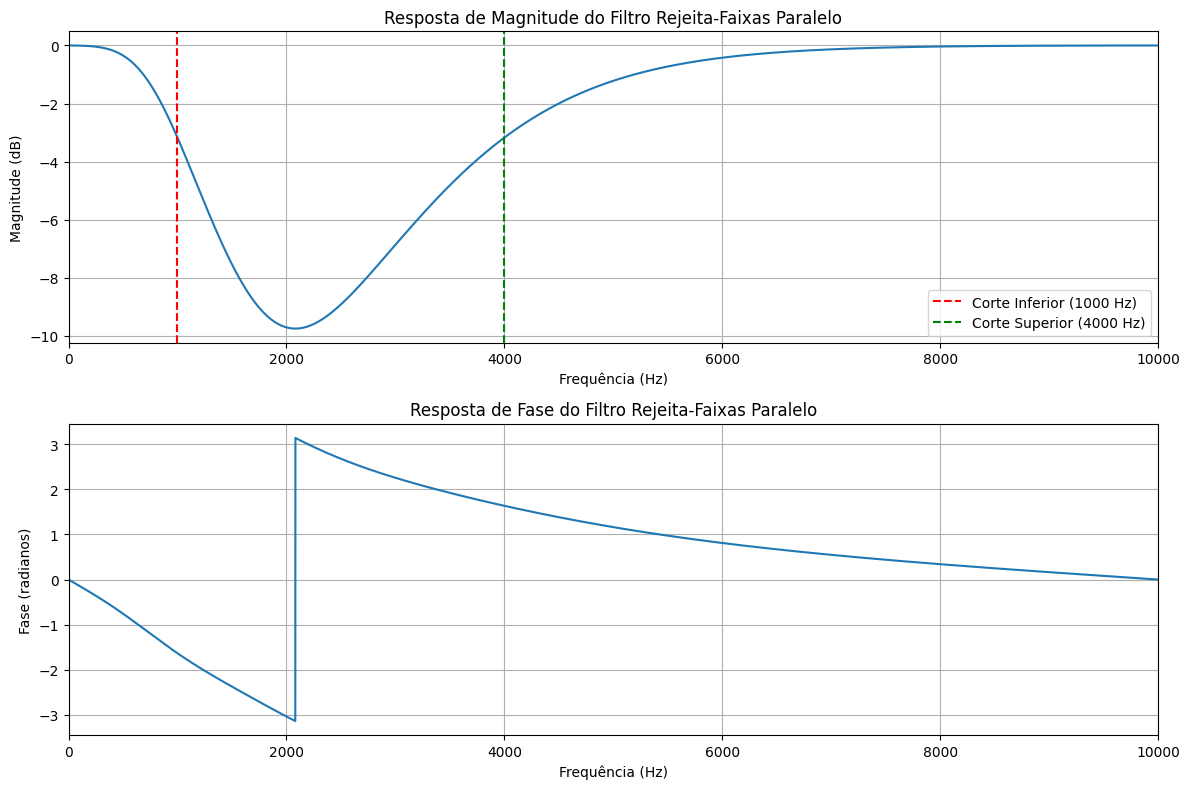

In [ ]:
# 4. Plotar a resposta em frequência do filtro rejeita-faixas paralelo

w_parallel_br, H_parallel_br = signal.freqz(b_parallel_br, a_parallel_br, worN=8192)

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Resposta de Magnitude
axs[0].plot(w_parallel_br * fs_br / (2 * np.pi), 20 * np.log10(abs(H_parallel_br)))
axs[0].set_title('Resposta de Magnitude do Filtro Rejeita-Faixas Paralelo')
axs[0].set_xlabel('Frequência (Hz)')
axs[0].set_ylabel('Magnitude (dB)')
axs[0].set_xlim(0, fs_br / 2)
axs[0].grid(True)
axs[0].axvline(fc1_br, color='red', linestyle='--', label=f'Corte Inferior ({fc1_br} Hz)')
axs[0].axvline(fc2_br, color='green', linestyle='--', label=f'Corte Superior ({fc2_br} Hz)')
axs[0].legend()

# Resposta de Fase
axs[1].plot(w_parallel_br * fs_br / (2 * np.pi), np.angle(H_parallel_br))
axs[1].set_title('Resposta de Fase do Filtro Rejeita-Faixas Paralelo')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Fase (radianos)')
axs[1].set_xlim(0, fs_br / 2)
axs[1].grid(True)

plt.tight_layout()
plt.show()

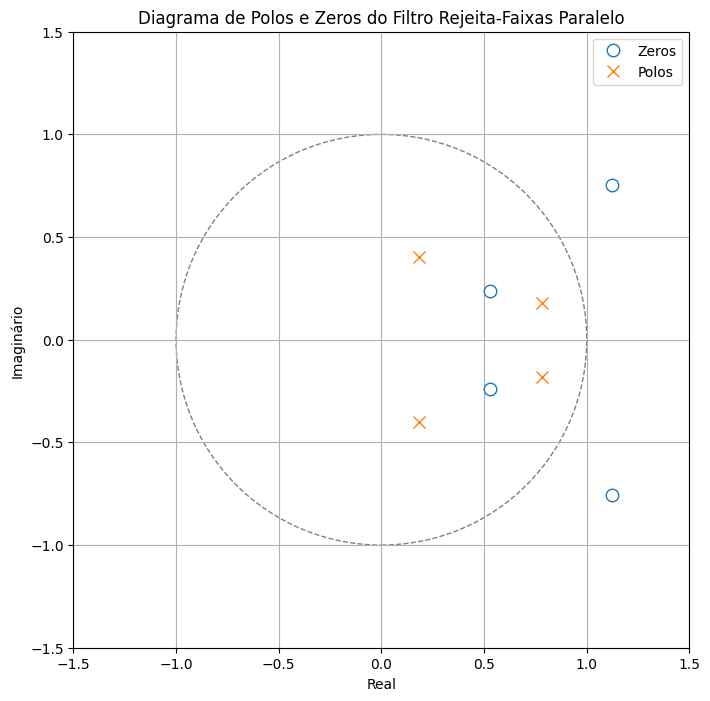

O filtro rejeita-faixas paralelo é estável, pois todos os polos estão dentro do círculo unitário.


In [ ]:
# 5. Plotar o diagrama de polos e zeros do filtro rejeita-faixas paralelo

zeros_parallel_br = np.roots(b_parallel_br)
poles_parallel_br = np.roots(a_parallel_br)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1)

unit_circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False)
ax.add_artist(unit_circle)

ax.plot(zeros_parallel_br.real, zeros_parallel_br.imag, 'o', markersize=9, label='Zeros', fillstyle='none')
ax.plot(poles_parallel_br.real, poles_parallel_br.imag, 'x', markersize=9, label='Polos')

ax.set_title('Diagrama de Polos e Zeros do Filtro Rejeita-Faixas Paralelo')
ax.set_xlabel('Real')
ax.set_ylabel('Imaginário')
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_aspect('equal', adjustable='box')
ax.grid(True)
ax.legend()
plt.show()

if np.all(np.abs(poles_parallel_br) < 1):
    print("O filtro rejeita-faixas paralelo é estável, pois todos os polos estão dentro do círculo unitário.")
else:
    print("O filtro rejeita-faixas paralelo é instável, pois um ou mais polos estão fora do círculo unitário.")

### Comparação com o Filtro Notch (Questão 1d)

**Filtro Notch (Questão 1d):**
*   **Forma:** É um filtro de 2ª ordem projetado para rejeitar uma única frequência central, com uma banda de rejeição cuja largura é controlada pelo parâmetro `r`.
*   **Função de Transferência:** Utiliza a forma $H(z) = K \frac{z^2 - 2\cos(\theta_c) z + 1}{z^2 - 2r \cos(\theta_c) z + r^2}$, que possui zeros no círculo unitário na frequência de rejeição e polos ligeiramente dentro para controlar a largura da banda.
*   **Característica:** Ideal para remover uma frequência específica ou uma banda de frequência muito estreita (como ruído de 60 Hz).
*   **Seletividade:** Alta seletividade em torno da frequência central de rejeição, dependendo de `r`.

**Filtro Rejeita-Faixas Paralelo (Questão 3):**
*   **Forma:** É um filtro de 4ª ordem (resultante da combinação de dois filtros de 2ª ordem) criado pela soma das saídas de um filtro passa-baixas e um filtro passa-altas. Ele rejeita um intervalo de frequências entre `fc1_br` e `fc2_br`.
*   **Função de Transferência:** É a soma das funções de transferência individuais dos LPF e HPF, resultando em um numerador e denominador de ordem mais alta (quarta ordem neste caso).
*   **Característica:** Ideal para rejeitar uma faixa de frequências mais ampla e bem definida, com transições mais abruptas nas bordas da banda de rejeição devido à maior ordem do filtro resultante.
*   **Seletividade:** A seletividade é controlada diretamente pelas frequências de corte `fc1_br` e `fc2_br` e pela ordem dos filtros Butterworth. Um filtro de 4ª ordem geralmente apresenta uma rejeição mais acentuada do que um filtro Notch de 2ª ordem.

**Comentários:**
Ambos os filtros são estáveis (polos dentro do círculo unitário), mas a forma de projetá-los e as características resultantes são diferentes:
*   O **filtro Notch** é mais "cirúrgico", focado em uma frequência central específica com uma banda de rejeição ajustável por `r`. É simples e eficaz para problemas de remoção de ruído de banda estreita.
*   O **filtro Rejeita-Faixas Paralelo** oferece maior flexibilidade para definir uma banda de rejeição com bordas mais nítidas e uma largura de banda de rejeição bem definida, útil para aplicações onde uma faixa de frequências mais ampla precisa ser suprimida. A maior ordem do filtro paralelo geralmente implica em melhor desempenho na banda de rejeição, mas também em maior complexidade computacional.

## Questão 4: Quantização dos Coeficientes do Filtro

Nesta seção, investigaremos o impacto da quantização dos coeficientes do filtro nas respostas em frequência, diagramas de polos e zeros e estabilidade dos filtros projetados nas Questões 2 (passa-faixas em cascata) e 3 (rejeita-faixas em paralelo). Realizaremos a quantização de duas maneiras:
1.  **Quantização no filtro resultante:** Aplicando a quantização diretamente nos coeficientes da função de transferência combinada.
2.  **Quantização em cada bloco dos filtros:** Aplicando a quantização nos coeficientes de cada bloco componente (HPF, LPF, etc.) antes de combiná-los.

Para cada abordagem, analisaremos a quantização para `b = {2, 4, 8, 16, 32}` bits e compararemos os resultados com os filtros originais.

### Função Auxiliar de Quantização

Vamos definir uma função que quantiza um array de coeficientes para um número específico de bits. Esta função usará uma abordagem de quantização de ponto fixo simples, mapeando o range dos coeficientes para `2^bits` níveis uniformes.

In [ ]:
def quantize_coefficients_simple(coefficients, bits):
    # Se os coeficientes estiverem vazios, retorna-os como estão
    if not coefficients.size:
        return coefficients

    # Determina o valor absoluto máximo para definir o range para quantização
    # Isso garante que a faixa dinâmica dos coeficientes seja preservada.
    max_abs_coeff = np.max(np.abs(coefficients))
    if max_abs_coeff == 0:
        return np.zeros_like(coefficients)

    # Número de níveis de quantização
    num_levels = 2**bits

    # O menor tamanho de passo representável (passo de quantização)
    quantization_step = (2 * max_abs_coeff) / num_levels

    # Quantiza dividindo pelo passo, arredondando para o inteiro mais próximo e multiplicando de volta
    quantized_coeffs = np.round(coefficients / quantization_step) * quantization_step
    return quantized_coeffs

print("Função `quantize_coefficients_simple` definida.")

Função `quantize_coefficients_simple` definida.


### Parte A: Quantização no Filtro Resultante

Nesta parte, aplicaremos a função de quantização diretamente nos coeficientes `b_cascata` e `a_cascata` (Questão 2), e `b_parallel_br` e `a_parallel_br` (Questão 3).

#### Filtro Passa-Faixas em Cascata (Questão 2) - Quantização do Resultado Final

Vamos quantizar os coeficientes `b_cascata` e `a_cascata` do filtro passa-faixas em cascata original e analisar seu impacto para diferentes números de bits.


--- Quantização com 2 bits (Filtro Passa-Faixas em Cascata Resultante) ---
Coeficientes do Numerador Quantizados (b_cascata_q): [ 0.13198831  0.         -0.26397662  0.          0.13198831]
Coeficientes do Denominador Quantizados (a_cascata_q): [0.75625394 1.51250788 0.75625394 0.         0.        ]


/tmp/ipykernel_4120/2192596713.py:20: RuntimeWarning: divide by zero encountered in log10
  axs[0].plot(w_cascata * fs / (2 * np.pi), 20 * np.log10(abs(H_cascata)), label='Original', linestyle='--')
/tmp/ipykernel_4120/2192596713.py:21: RuntimeWarning: divide by zero encountered in log10
  axs[0].plot(w_q * fs / (2 * np.pi), 20 * np.log10(abs(H_q)), label=f'Quantizado {bits} bits')


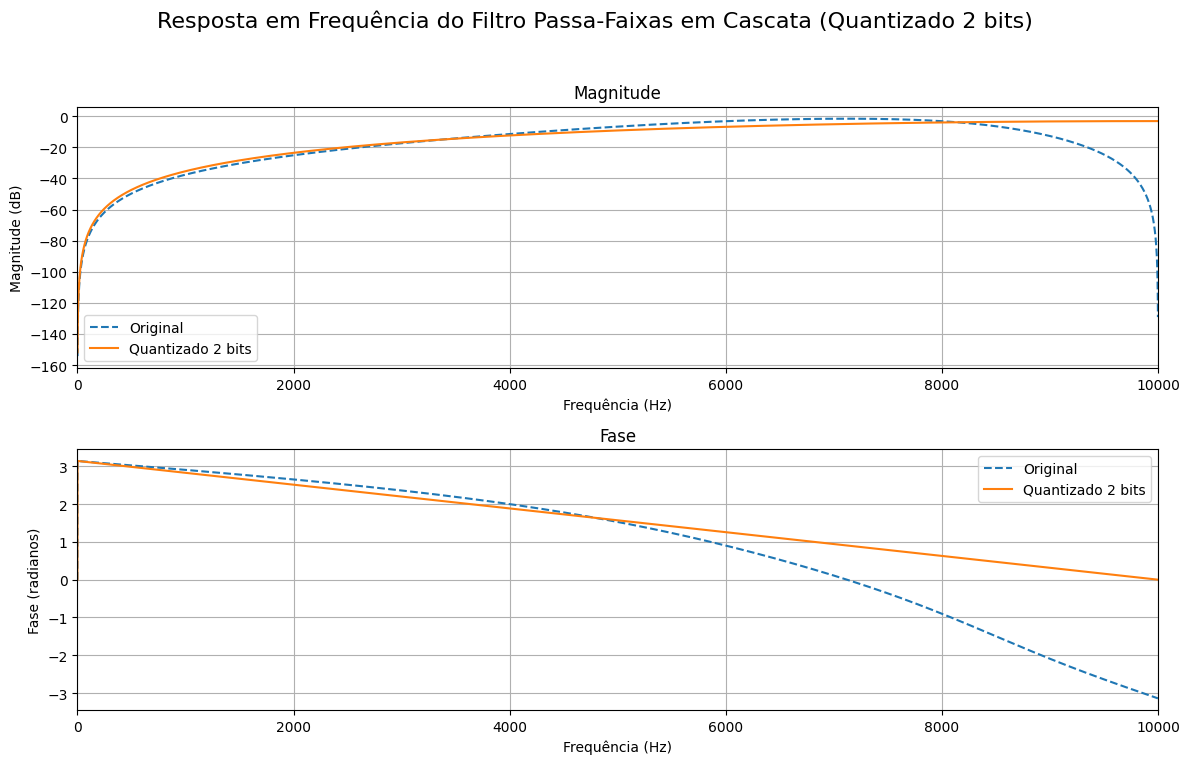

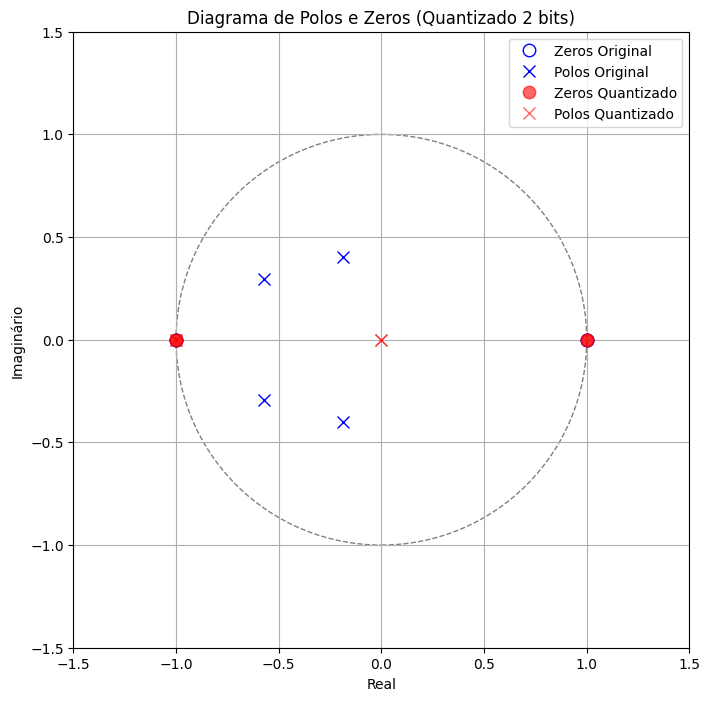

O filtro quantizado com 2 bits é instável, pois um ou mais polos estão fora do círculo unitário.

--- Quantização com 4 bits (Filtro Passa-Faixas em Cascata Resultante) ---
Coeficientes do Numerador Quantizados (b_cascata_q): [ 0.13198831  0.         -0.26397662  0.          0.13198831]
Coeficientes do Denominador Quantizados (a_cascata_q): [0.94531742 1.51250788 0.94531742 0.37812697 0.        ]


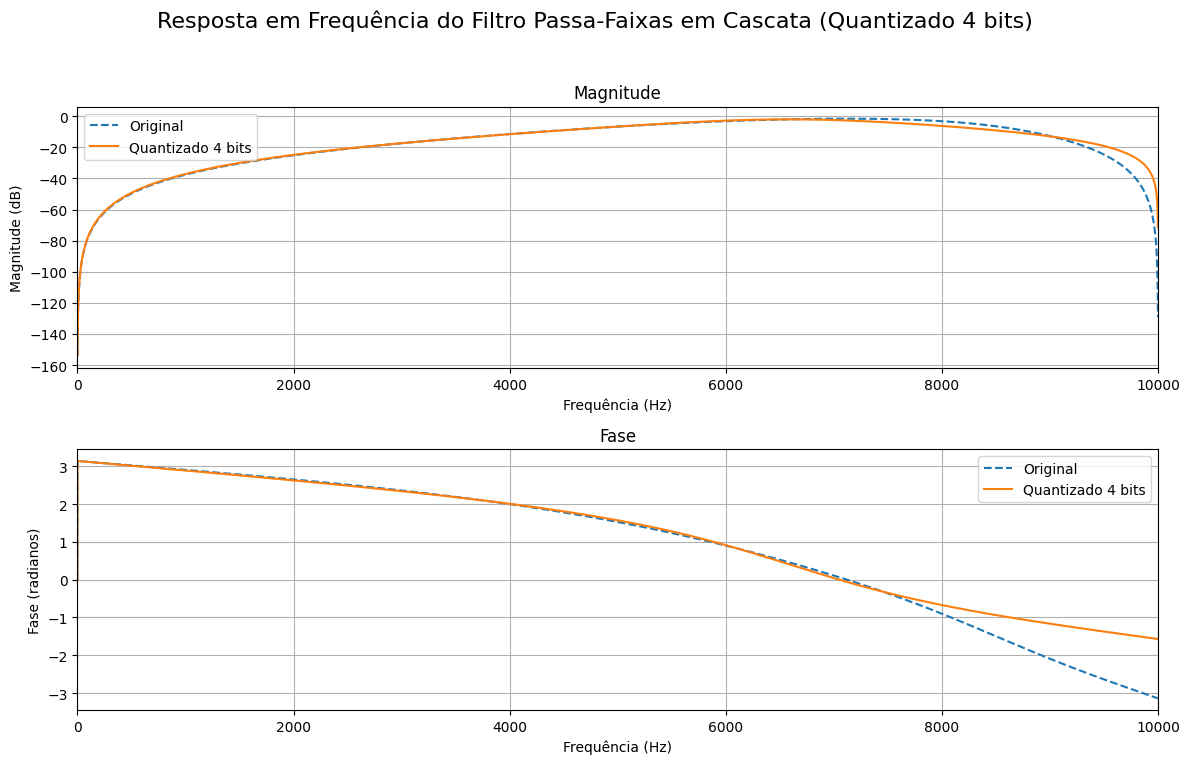

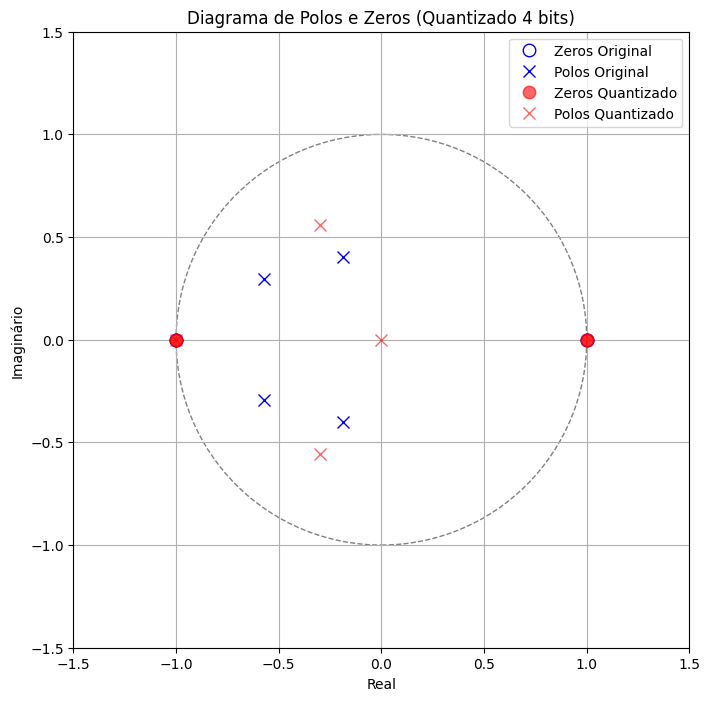

O filtro quantizado com 4 bits é estável, pois todos os polos estão dentro do círculo unitário.

--- Quantização com 8 bits (Filtro Passa-Faixas em Cascata Resultante) ---
Coeficientes do Numerador Quantizados (b_cascata_q): [ 0.13198831  0.         -0.26397662  0.          0.13198831]
Coeficientes do Denominador Quantizados (a_cascata_q): [1.00439976 1.51250788 1.0280327  0.37812697 0.08271527]


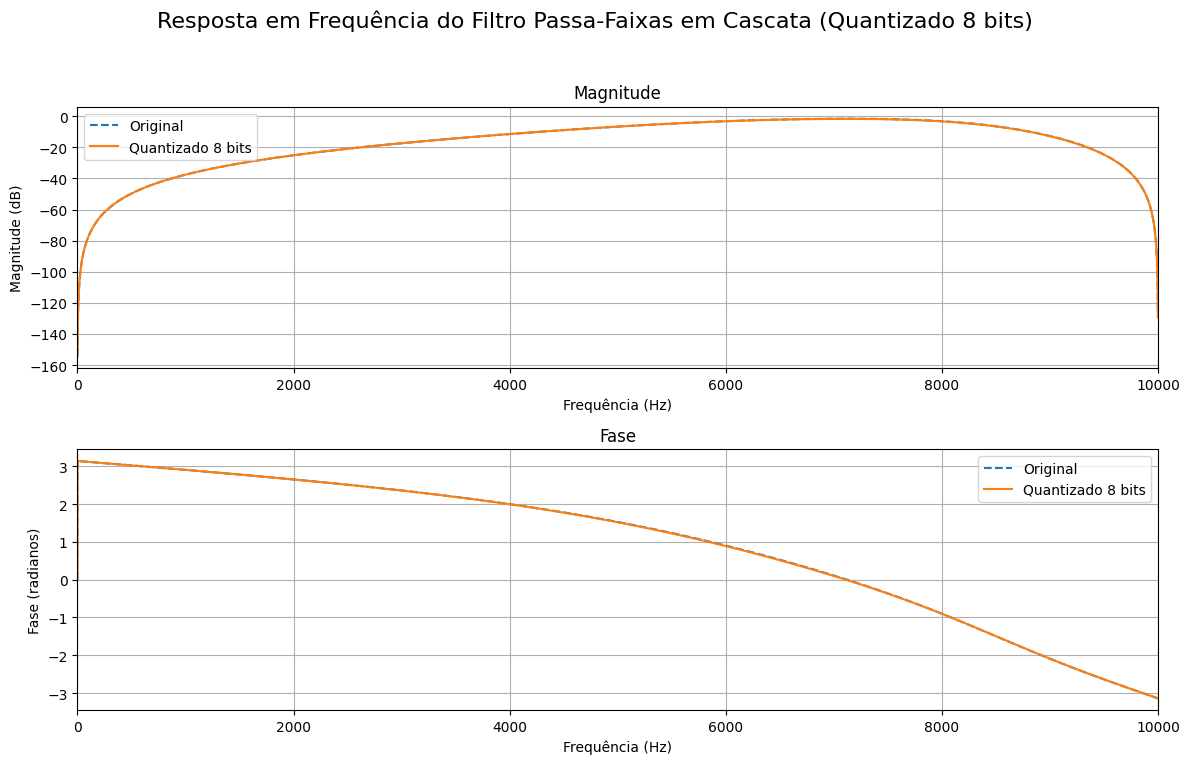

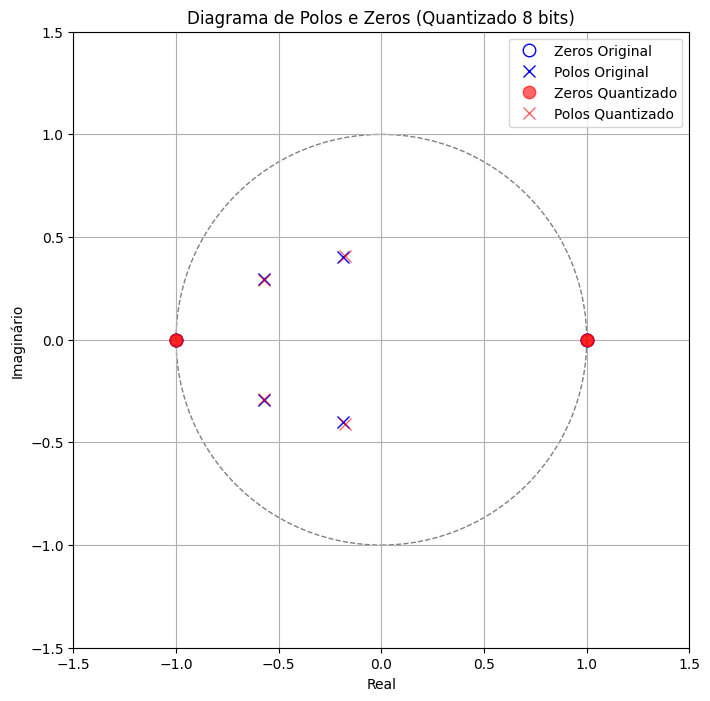

O filtro quantizado com 8 bits é estável, pois todos os polos estão dentro do círculo unitário.

--- Quantização com 16 bits (Filtro Passa-Faixas em Cascata Resultante) ---
Coeficientes do Numerador Quantizados (b_cascata_q): [ 0.13198831  0.         -0.26397662  0.          0.13198831]
Coeficientes do Denominador Quantizados (a_cascata_q): [1.00001475 1.51250788 1.03098682 0.37637296 0.08082279]


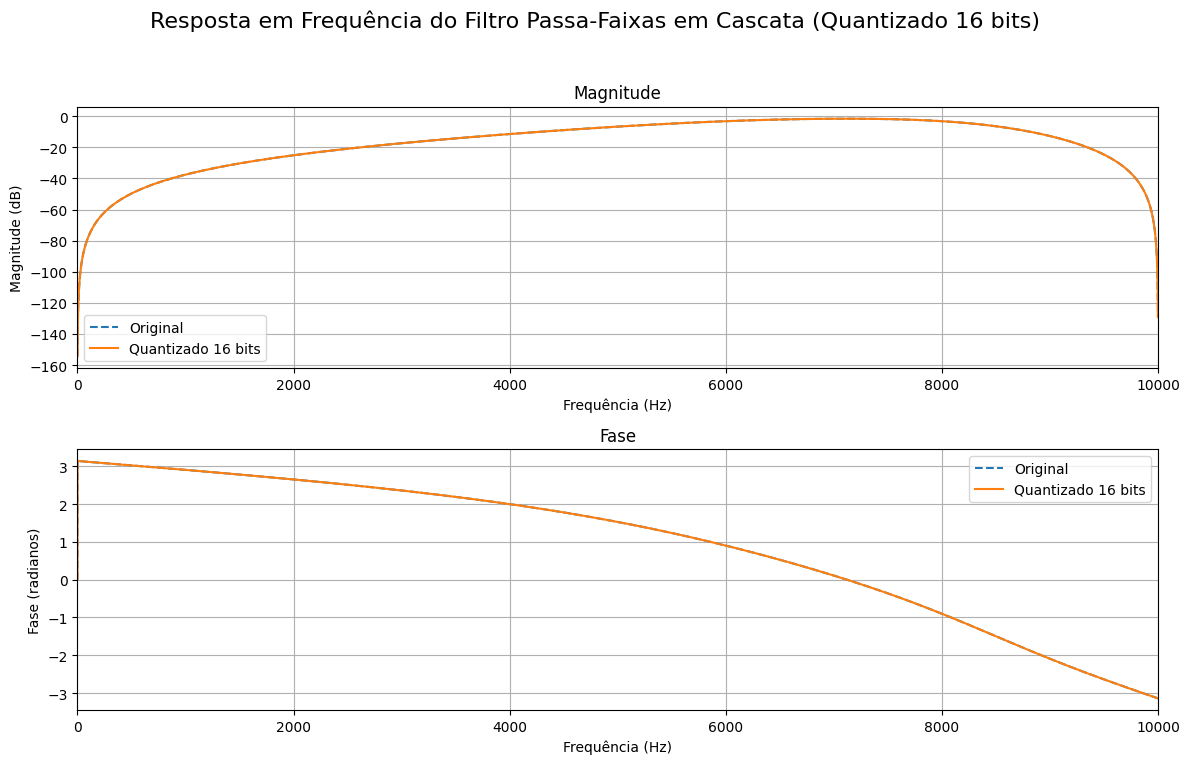

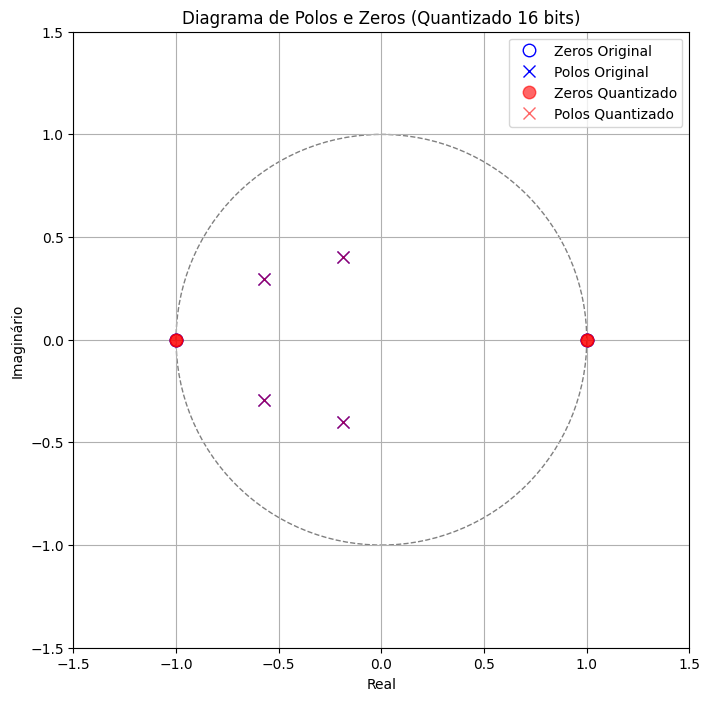

O filtro quantizado com 16 bits é estável, pois todos os polos estão dentro do círculo unitário.

--- Quantização com 32 bits (Filtro Passa-Faixas em Cascata Resultante) ---
Coeficientes do Numerador Quantizados (b_cascata_q): [ 0.13198831  0.         -0.26397662  0.          0.13198831]
Coeficientes do Denominador Quantizados (a_cascata_q): [1.         1.51250788 1.0309799  0.37635503 0.08083304]


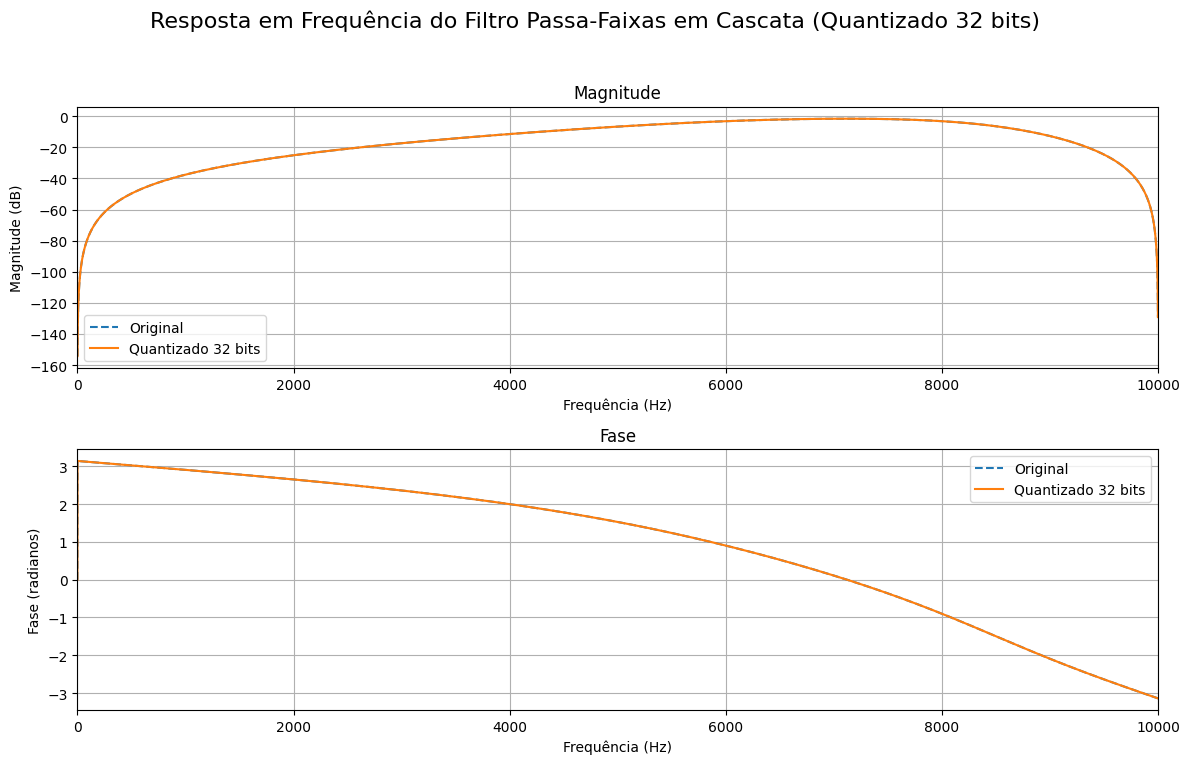

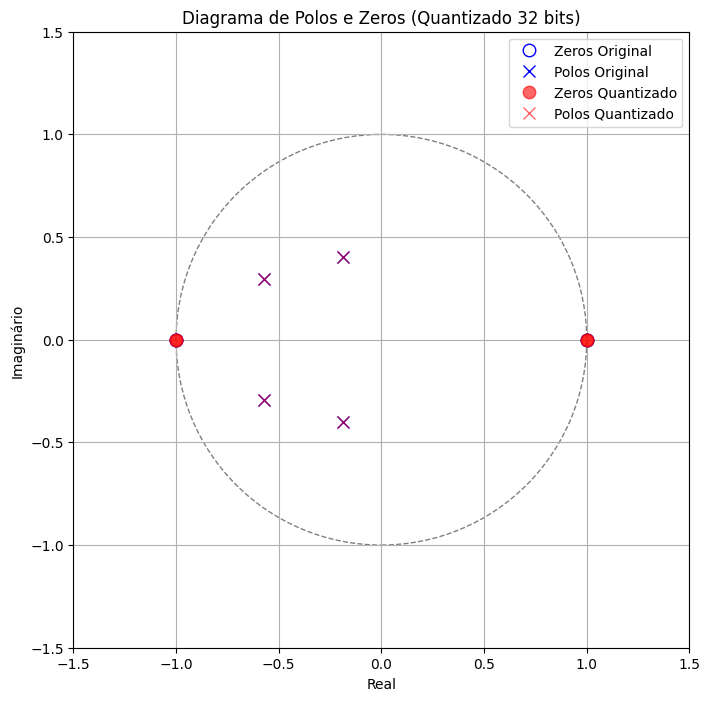

O filtro quantizado com 32 bits é estável, pois todos os polos estão dentro do círculo unitário.


In [ ]:
bits_to_test = [2, 4, 8, 16, 32]

for bits in bits_to_test:
    print(f"\n--- Quantização com {bits} bits (Filtro Passa-Faixas em Cascata Resultante) ---")

    # Quantizar os coeficientes do filtro em cascata
    b_cascata_q = quantize_coefficients_simple(b_cascata, bits)
    a_cascata_q = quantize_coefficients_simple(a_cascata, bits)

    print(f"Coeficientes do Numerador Quantizados (b_cascata_q): {b_cascata_q}")
    print(f"Coeficientes do Denominador Quantizados (a_cascata_q): {a_cascata_q}")

    # --- Análise da Resposta em Frequência ---
    w_q, H_q = signal.freqz(b_cascata_q, a_cascata_q, worN=8192)

    fig, axs = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(f'Resposta em Frequência do Filtro Passa-Faixas em Cascata (Quantizado {bits} bits)', fontsize=16)

    # Resposta de Magnitude
    axs[0].plot(w_cascata * fs / (2 * np.pi), 20 * np.log10(abs(H_cascata)), label='Original', linestyle='--')
    axs[0].plot(w_q * fs / (2 * np.pi), 20 * np.log10(abs(H_q)), label=f'Quantizado {bits} bits')
    axs[0].set_title('Magnitude')
    axs[0].set_xlabel('Frequência (Hz)')
    axs[0].set_ylabel('Magnitude (dB)')
    axs[0].set_xlim(0, fs / 2)
    axs[0].grid(True)
    axs[0].legend()

    # Resposta de Fase
    axs[1].plot(w_cascata * fs / (2 * np.pi), np.angle(H_cascata), label='Original', linestyle='--')
    axs[1].plot(w_q * fs / (2 * np.pi), np.angle(H_q), label=f'Quantizado {bits} bits')
    axs[1].set_title('Fase')
    axs[1].set_xlabel('Frequência (Hz)')
    axs[1].set_ylabel('Fase (radianos)')
    axs[1].set_xlim(0, fs / 2)
    axs[1].grid(True)
    axs[1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- Análise do Diagrama de Polos e Zeros ---
    zeros_q = np.roots(b_cascata_q)
    poles_q = np.roots(a_cascata_q)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(1, 1, 1)

    unit_circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False)
    ax.add_artist(unit_circle)

    ax.plot(zeros_cascata.real, zeros_cascata.imag, 'o', markersize=9, label='Zeros Original', fillstyle='none', color='blue')
    ax.plot(poles_cascata.real, poles_cascata.imag, 'x', markersize=9, label='Polos Original', color='blue')

    ax.plot(zeros_q.real, zeros_q.imag, 'o', markersize=9, label='Zeros Quantizado', fillstyle='full', color='red', alpha=0.6)
    ax.plot(poles_q.real, poles_q.imag, 'x', markersize=9, label='Polos Quantizado', color='red', alpha=0.6)

    ax.set_title(f'Diagrama de Polos e Zeros (Quantizado {bits} bits)')
    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginário')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    ax.legend()
    plt.show()

    # Verificar estabilidade
    if np.all(np.abs(poles_q) < 1):
        print(f"O filtro quantizado com {bits} bits é estável, pois todos os polos estão dentro do círculo unitário.")
    else:
        print(f"O filtro quantizado com {bits} bits é instável, pois um ou mais polos estão fora do círculo unitário.")

### Comentários sobre a Quantização Direta do Filtro Passa-Faixas em Cascata

*   **Menos Bits (2-4 bits):** Com um número muito baixo de bits, a resposta em frequência se desvia significativamente do filtro original. A banda de passagem pode se alargar ou se estreitar drasticamente, e a atenuação na banda de rejeição pode ser comprometida. Os polos e zeros quantizados se afastam muito das suas posições originais, podendo levar à instabilidade (polos fora do círculo unitário).
*   **Bits Intermediários (8-16 bits):** À medida que o número de bits aumenta, a resposta em frequência se aproxima mais da ideal. O diagrama de polos e zeros mostra que as posições dos polos e zeros quantizados estão mais próximas das originais, e a estabilidade tende a ser mantida.
*   **Mais Bits (32 bits):** Com 32 bits, a quantização tem um efeito mínimo. A resposta em frequência e as posições de polos e zeros são praticamente indistinguíveis do filtro original. A estabilidade é preservada.
*   **Sensibilidade Numérica:** Filtros de ordem superior (como este de 4ª ordem) são geralmente mais sensíveis à quantização dos coeficientes. Pequenas variações nos coeficientes podem causar grandes mudanças na resposta em frequência e na estabilidade, especialmente quando os polos estão próximos do círculo unitário. Isso é evidente nas baixas contagens de bits.

#### Filtro Rejeita-Faixas em Paralelo (Questão 3) - Quantização do Resultado Final

Agora, faremos o mesmo para os coeficientes `b_parallel_br` e `a_parallel_br` do filtro rejeita-faixas em paralelo.


--- Quantização com 2 bits (Filtro Rejeita-Faixas em Paralelo Resultante) ---
Coeficientes do Numerador Quantizados (b_parallel_br_q): [ 0.         -0.93662865  1.8732573  -0.93662865  0.        ]
Coeficientes do Denominador Quantizados (a_parallel_br_q): [ 0.96527273 -1.93054545  0.96527273 -0.96527273  0.        ]


/tmp/ipykernel_4120/1523929065.py:21: RuntimeWarning: divide by zero encountered in log10
  axs[0].plot(w_q * fs_br / (2 * np.pi), 20 * np.log10(abs(H_q)), label=f'Quantizado {bits} bits')


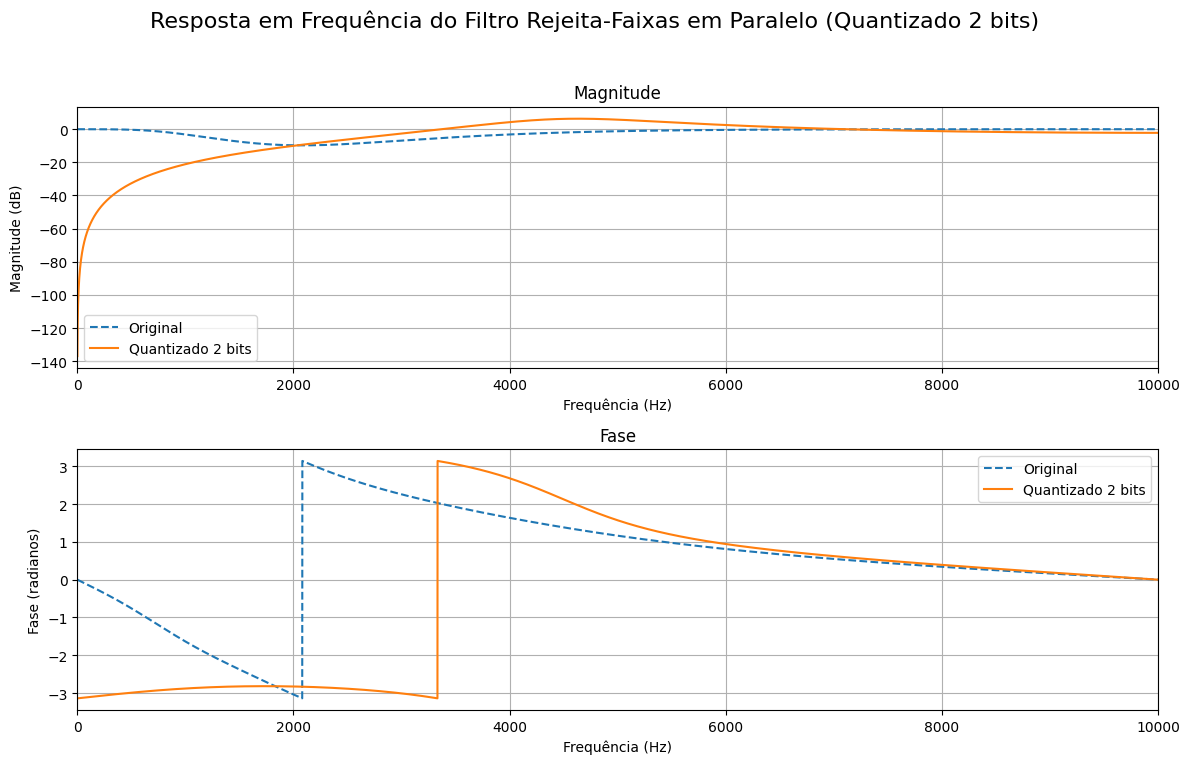

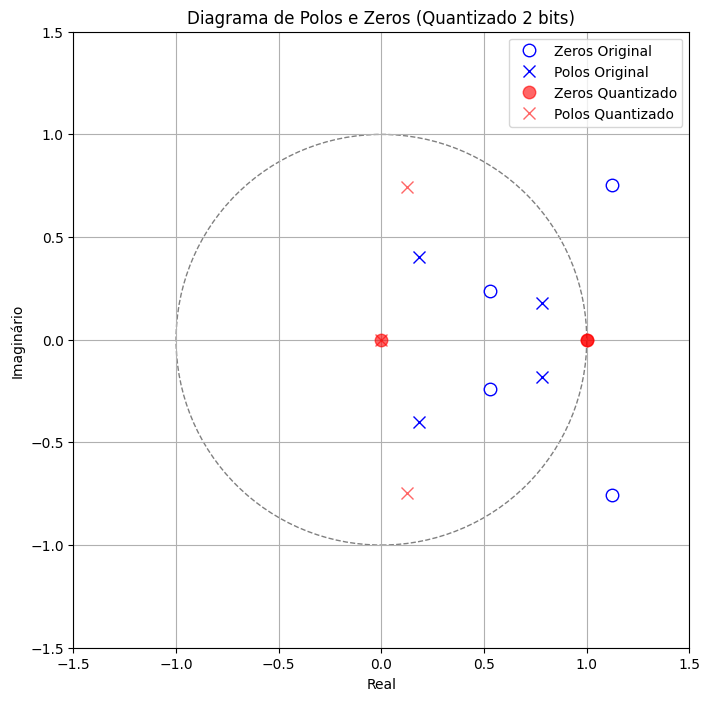

O filtro quantizado com 2 bits é instável, pois um ou mais polos estão fora do círculo unitário.

--- Quantização com 4 bits (Filtro Rejeita-Faixas em Paralelo Resultante) ---
Coeficientes do Numerador Quantizados (b_parallel_br_q): [ 0.46831432 -1.40494297  1.8732573  -1.17078581  0.23415716]
Coeficientes do Denominador Quantizados (a_parallel_br_q): [ 0.96527273 -1.93054545  1.44790909 -0.48263636  0.24131818]


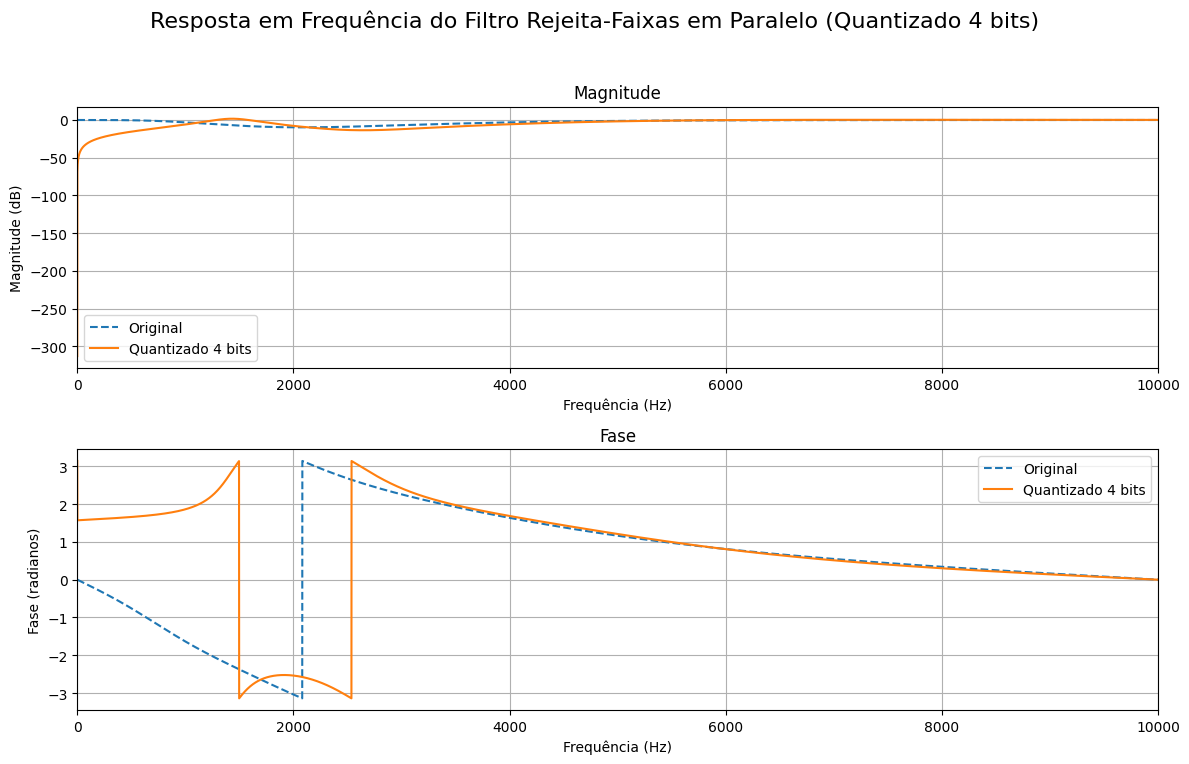

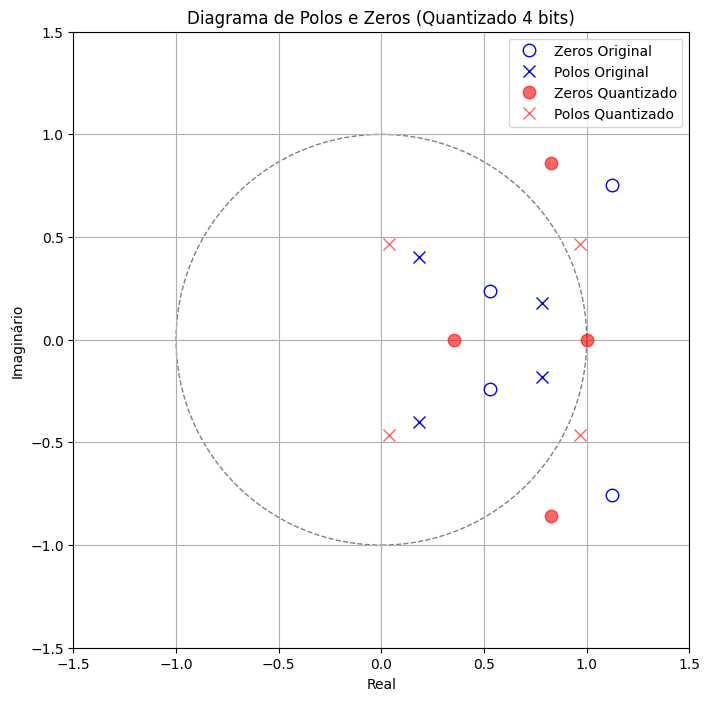

O filtro quantizado com 4 bits é instável, pois um ou mais polos estão fora do círculo unitário.

--- Quantização com 8 bits (Filtro Rejeita-Faixas em Paralelo Resultante) ---
Coeficientes do Numerador Quantizados (b_parallel_br_q): [ 0.40977503 -1.36103851  1.8732573  -1.11224652  0.24879198]
Coeficientes do Denominador Quantizados (a_parallel_br_q): [ 0.9954375  -1.93054545  1.41774432 -0.54296591  0.12065909]


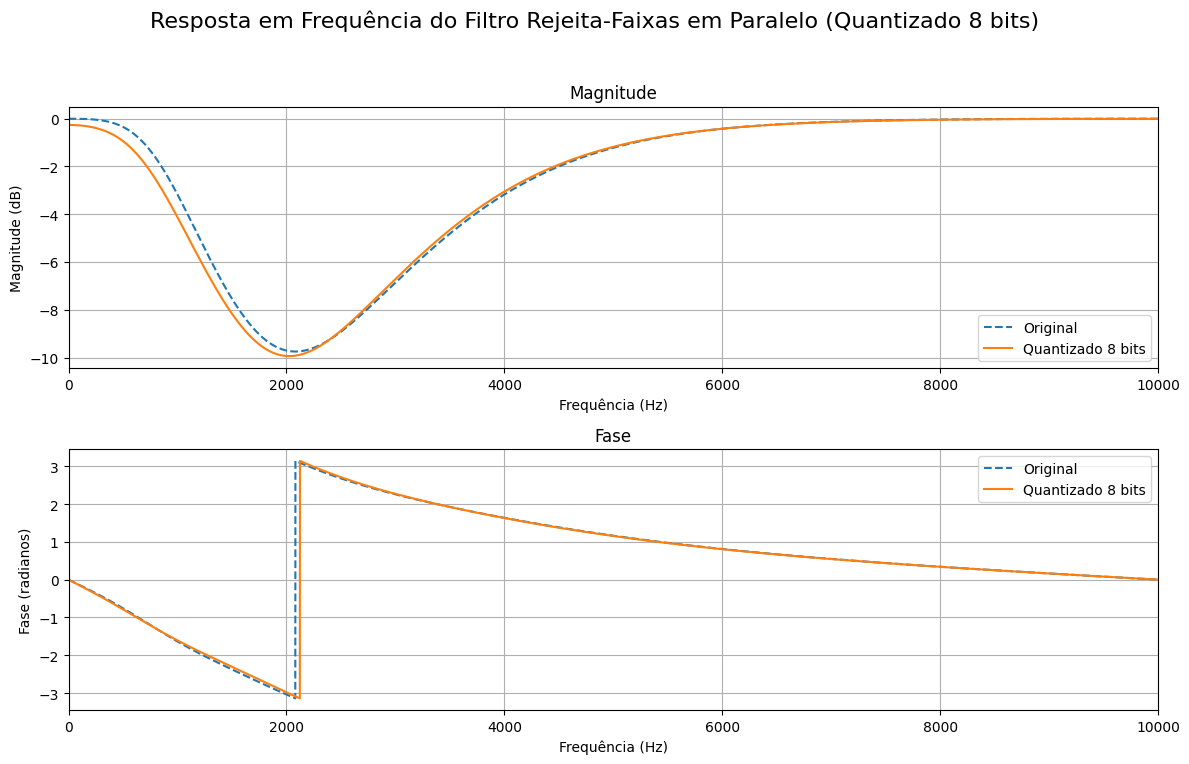

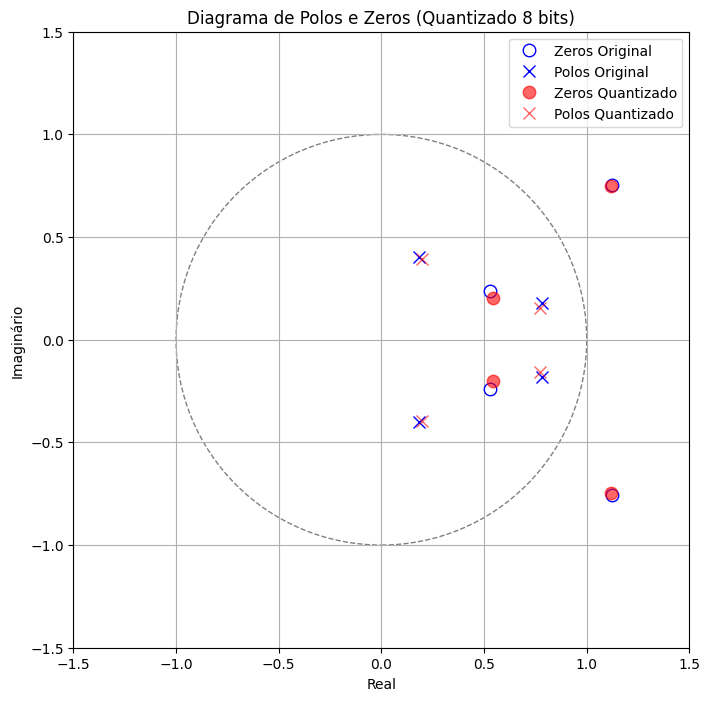

O filtro quantizado com 8 bits é estável, pois todos os polos estão dentro do círculo unitário.

--- Quantização com 16 bits (Filtro Rejeita-Faixas em Paralelo Resultante) ---
Coeficientes do Numerador Quantizados (b_parallel_br_q): [ 0.41143289 -1.36080984  1.8732573  -1.11241802  0.25490888]
Coeficientes do Denominador Quantizados (a_parallel_br_q): [ 0.999974   -1.93054545  1.41403264 -0.54267133  0.125608  ]


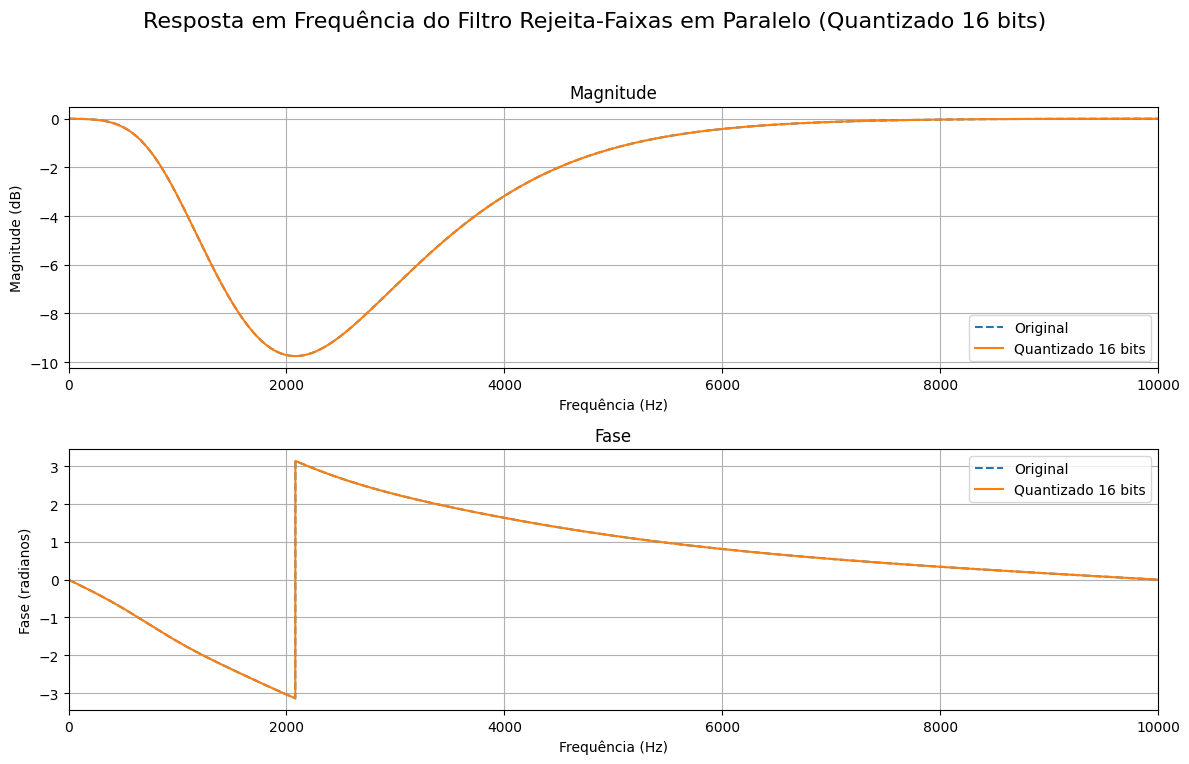

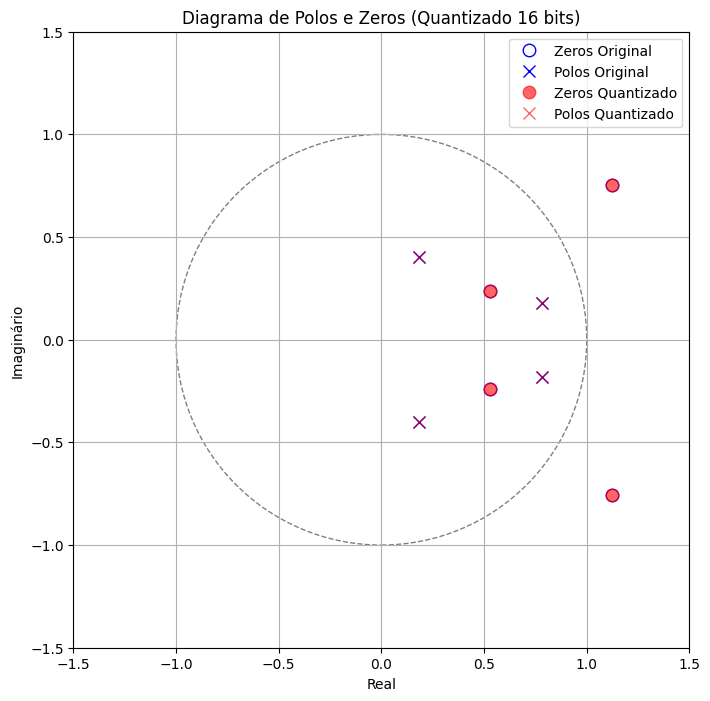

O filtro quantizado com 16 bits é estável, pois todos os polos estão dentro do círculo unitário.

--- Quantização com 32 bits (Filtro Rejeita-Faixas em Paralelo Resultante) ---
Coeficientes do Numerador Quantizados (b_parallel_br_q): [ 0.41141914 -1.36080838  1.8732573  -1.11240589  0.25491644]
Coeficientes do Denominador Quantizados (a_parallel_br_q): [ 1.         -1.93054545  1.41400617 -0.54266882  0.12558671]


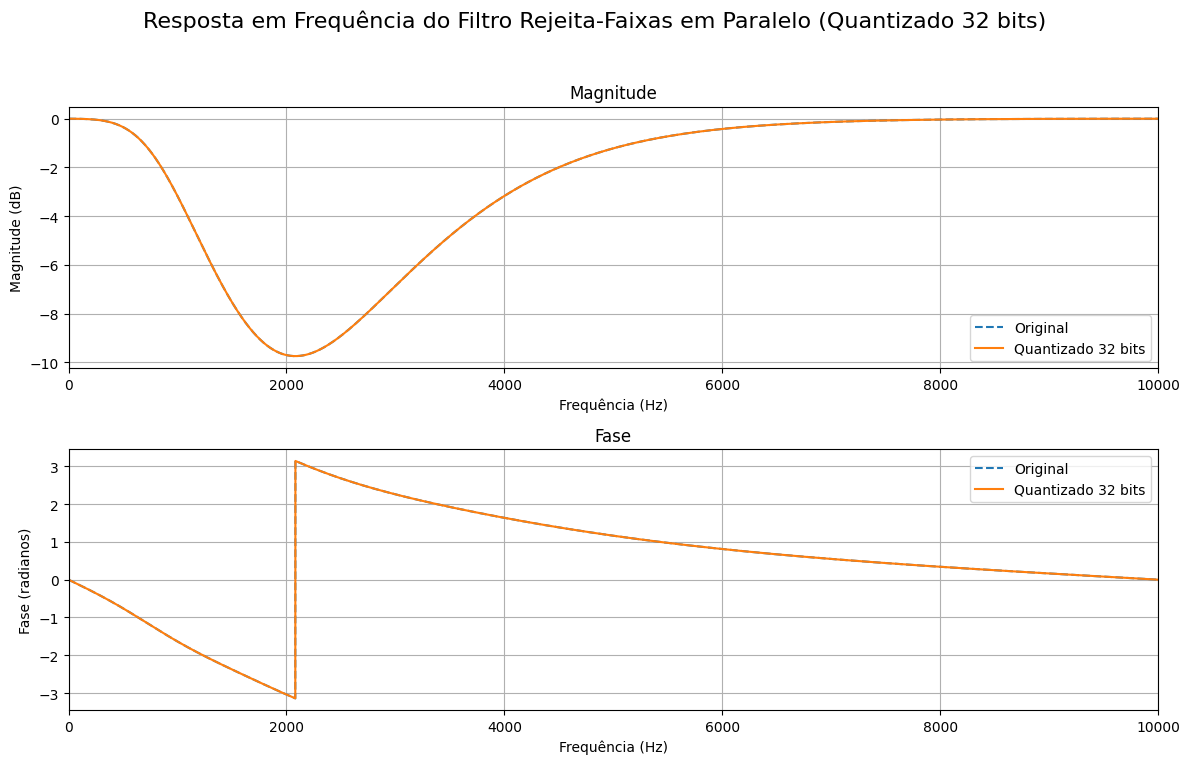

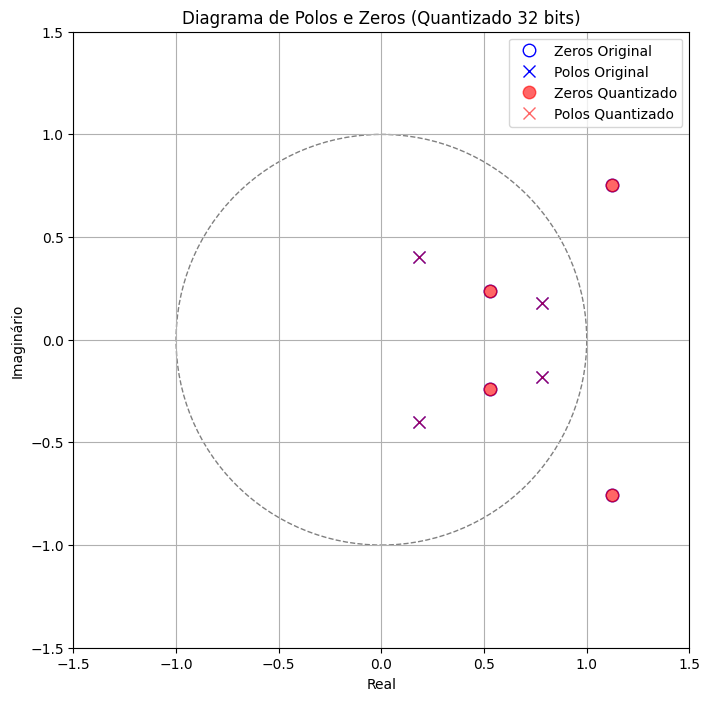

O filtro quantizado com 32 bits é estável, pois todos os polos estão dentro do círculo unitário.


In [ ]:
bits_to_test = [2, 4, 8, 16, 32]

for bits in bits_to_test:
    print(f"\n--- Quantização com {bits} bits (Filtro Rejeita-Faixas em Paralelo Resultante) ---")

    # Quantizar os coeficientes do filtro em paralelo
    b_parallel_br_q = quantize_coefficients_simple(b_parallel_br, bits)
    a_parallel_br_q = quantize_coefficients_simple(a_parallel_br, bits)

    print(f"Coeficientes do Numerador Quantizados (b_parallel_br_q): {b_parallel_br_q}")
    print(f"Coeficientes do Denominador Quantizados (a_parallel_br_q): {a_parallel_br_q}")

    # --- Análise da Resposta em Frequência ---
    w_q, H_q = signal.freqz(b_parallel_br_q, a_parallel_br_q, worN=8192)

    fig, axs = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(f'Resposta em Frequência do Filtro Rejeita-Faixas em Paralelo (Quantizado {bits} bits)', fontsize=16)

    # Resposta de Magnitude
    axs[0].plot(w_parallel_br * fs_br / (2 * np.pi), 20 * np.log10(abs(H_parallel_br)), label='Original', linestyle='--')
    axs[0].plot(w_q * fs_br / (2 * np.pi), 20 * np.log10(abs(H_q)), label=f'Quantizado {bits} bits')
    axs[0].set_title('Magnitude')
    axs[0].set_xlabel('Frequência (Hz)')
    axs[0].set_ylabel('Magnitude (dB)')
    axs[0].set_xlim(0, fs_br / 2)
    axs[0].grid(True)
    axs[0].legend()

    # Resposta de Fase
    axs[1].plot(w_parallel_br * fs_br / (2 * np.pi), np.angle(H_parallel_br), label='Original', linestyle='--')
    axs[1].plot(w_q * fs_br / (2 * np.pi), np.angle(H_q), label=f'Quantizado {bits} bits')
    axs[1].set_title('Fase')
    axs[1].set_xlabel('Frequência (Hz)')
    axs[1].set_ylabel('Fase (radianos)')
    axs[1].set_xlim(0, fs_br / 2)
    axs[1].grid(True)
    axs[1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- Análise do Diagrama de Polos e Zeros ---
    zeros_q = np.roots(b_parallel_br_q)
    poles_q = np.roots(a_parallel_br_q)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(1, 1, 1)

    unit_circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False)
    ax.add_artist(unit_circle)

    ax.plot(zeros_parallel_br.real, zeros_parallel_br.imag, 'o', markersize=9, label='Zeros Original', fillstyle='none', color='blue')
    ax.plot(poles_parallel_br.real, poles_parallel_br.imag, 'x', markersize=9, label='Polos Original', color='blue')

    ax.plot(zeros_q.real, zeros_q.imag, 'o', markersize=9, label='Zeros Quantizado', fillstyle='full', color='red', alpha=0.6)
    ax.plot(poles_q.real, poles_q.imag, 'x', markersize=9, label='Polos Quantizado', color='red', alpha=0.6)

    ax.set_title(f'Diagrama de Polos e Zeros (Quantizado {bits} bits)')
    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginário')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    ax.legend()
    plt.show()

    # Verificar estabilidade
    if np.all(np.abs(poles_q) < 1):
        print(f"O filtro quantizado com {bits} bits é estável, pois todos os polos estão dentro do círculo unitário.")
    else:
        print(f"O filtro quantizado com {bits} bits é instável, pois um ou mais polos estão fora do círculo unitário.")

### Comentários sobre a Quantização Direta do Filtro Rejeita-Faixas em Paralelo

*   **Menos Bits (2-4 bits):** Para este filtro também, com um baixo número de bits, a resposta em frequência é severamente distorcida. A banda de rejeição pode não ser claramente definida, e as bandas passantes podem ser afetadas. A instabilidade é um risco significativo, pois os polos e zeros se movem consideravelmente.
*   **Bits Intermediários (8-16 bits):** Com mais bits, a aproximação da resposta ideal melhora. As características da banda de rejeição se tornam mais claras, e a estabilidade é geralmente mantida.
*   **Mais Bits (32 bits):** A quantização com 32 bits resulta em uma representação quase perfeita do filtro original, com mínima degradação na resposta em frequência e total preservação da estabilidade.
*   **Sensibilidade Numérica:** A combinação de filtros em paralelo também pode aumentar a ordem do filtro resultante, tornando-o mais propenso à sensibilidade numérica devido à quantização dos coeficientes. A precisão dos coeficientes é crucial para manter a forma da banda de rejeição e a estabilidade.

### Parte B: Quantização em Cada Bloco dos Filtros

Nesta parte, quantizaremos os coeficientes de cada bloco componente (HPF, LPF) individualmente antes de combiná-los. Esta abordagem pode oferecer melhor robustez à quantização em algumas configurações.

#### Filtro Passa-Faixas em Cascata (Questão 2) - Quantização dos Blocos Componentes

Vamos quantizar `b_hp`, `a_hp`, `b_lp`, `a_lp` individualmente e depois cascateá-los.


--- Quantização com 2 bits (Filtro Passa-Faixas em Cascata - Blocos) ---
Coeficientes do Numerador HPF Quantizados (b_hp_q): [ 0.20657208 -0.41314417  0.20657208]
Coeficientes do Denominador HPF Quantizados (a_hp_q): [1.  0.5 0. ]
Coeficientes do Numerador LPF Quantizados (b_lp_q): [0.63894553 1.27789105 0.63894553]
Coeficientes do Denominador LPF Quantizados (a_lp_q): [1.1429805  1.1429805  0.57149025]
Coeficientes do Numerador da Cascata Quantizada (b_cascata_blocks_q): [ 0.13198831  0.         -0.26397662  0.          0.13198831]
Coeficientes do Denominador da Cascata Quantizada (a_cascata_blocks_q): [1.1429805  1.71447075 1.1429805  0.28574513 0.        ]


/tmp/ipykernel_4120/3727288999.py:30: RuntimeWarning: divide by zero encountered in log10
  axs[0].plot(w_cascata * fs / (2 * np.pi), 20 * np.log10(abs(H_cascata)), label='Original', linestyle='--')
/tmp/ipykernel_4120/3727288999.py:31: RuntimeWarning: divide by zero encountered in log10
  axs[0].plot(w_q_blocks * fs / (2 * np.pi), 20 * np.log10(abs(H_q_blocks)), label=f'Quantizado {bits} bits')


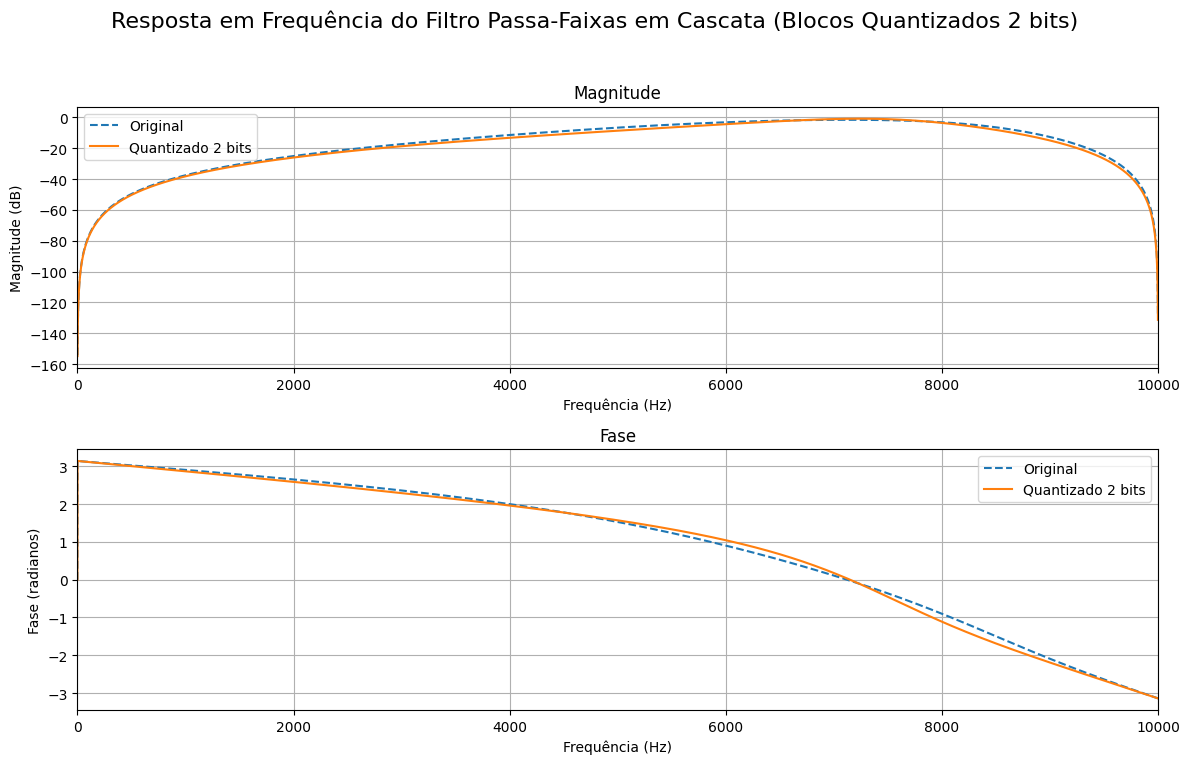

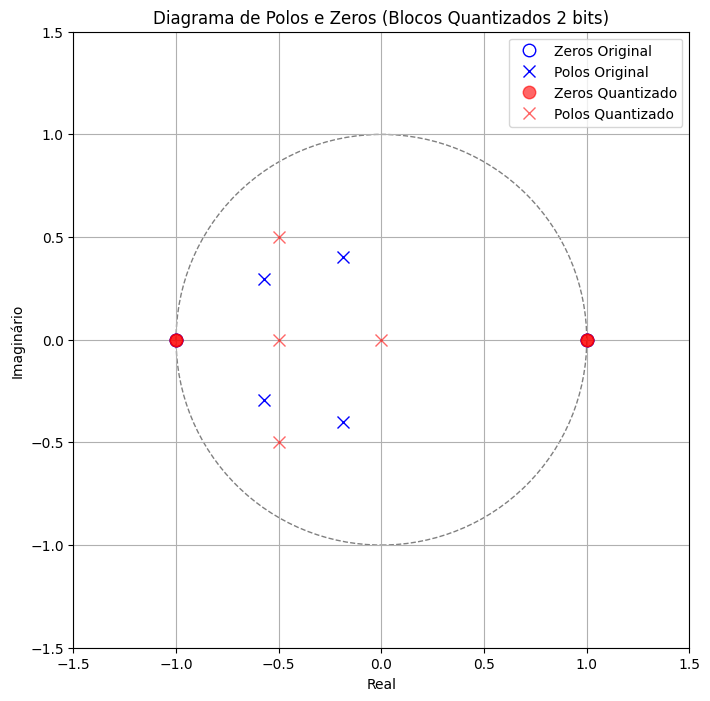

O filtro em cascata com blocos quantizados com 2 bits é estável.

--- Quantização com 4 bits (Filtro Passa-Faixas em Cascata - Blocos) ---
Coeficientes do Numerador HPF Quantizados (b_hp_q): [ 0.20657208 -0.41314417  0.20657208]
Coeficientes do Denominador HPF Quantizados (a_hp_q): [1.    0.375 0.25 ]
Coeficientes do Numerador LPF Quantizados (b_lp_q): [0.63894553 1.27789105 0.63894553]
Coeficientes do Denominador LPF Quantizados (a_lp_q): [1.00010794 1.1429805  0.42861769]
Coeficientes do Numerador da Cascata Quantizada (b_cascata_blocks_q): [ 0.13198831  0.         -0.26397662  0.          0.13198831]
Coeficientes do Denominador da Cascata Quantizada (a_cascata_blocks_q): [1.00010794 1.51802098 1.10726236 0.44647676 0.10715442]


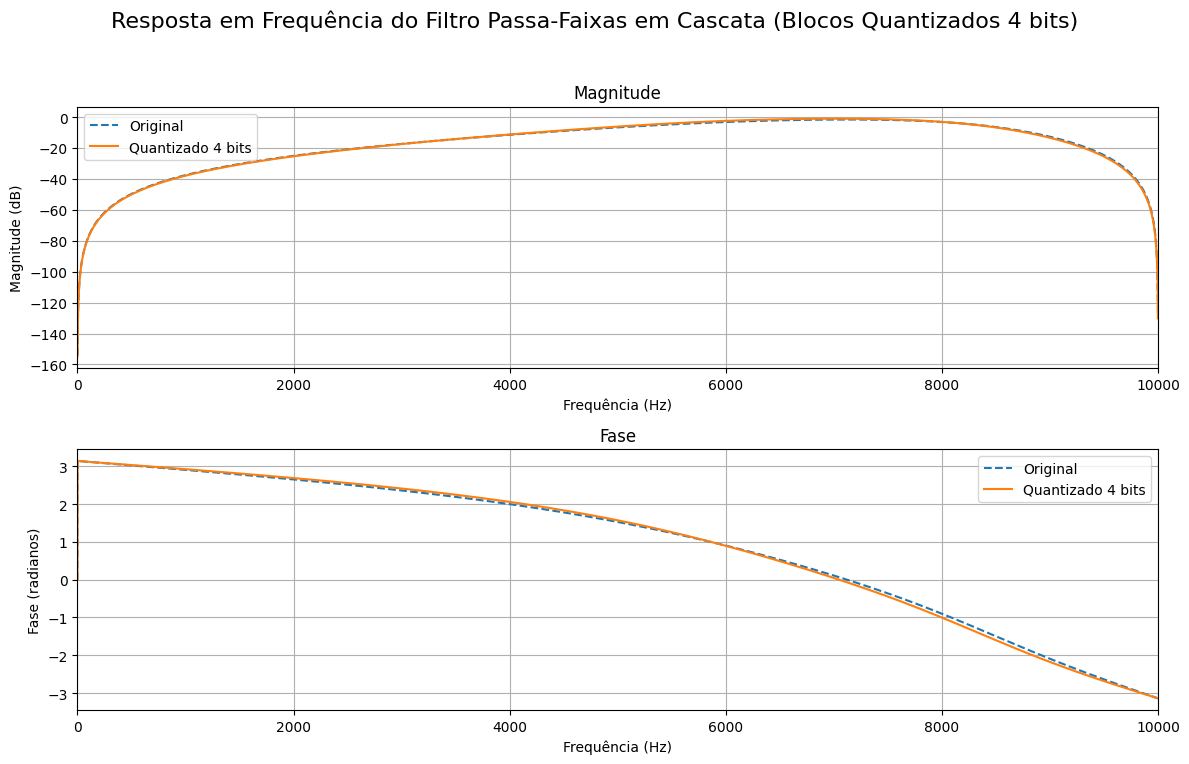

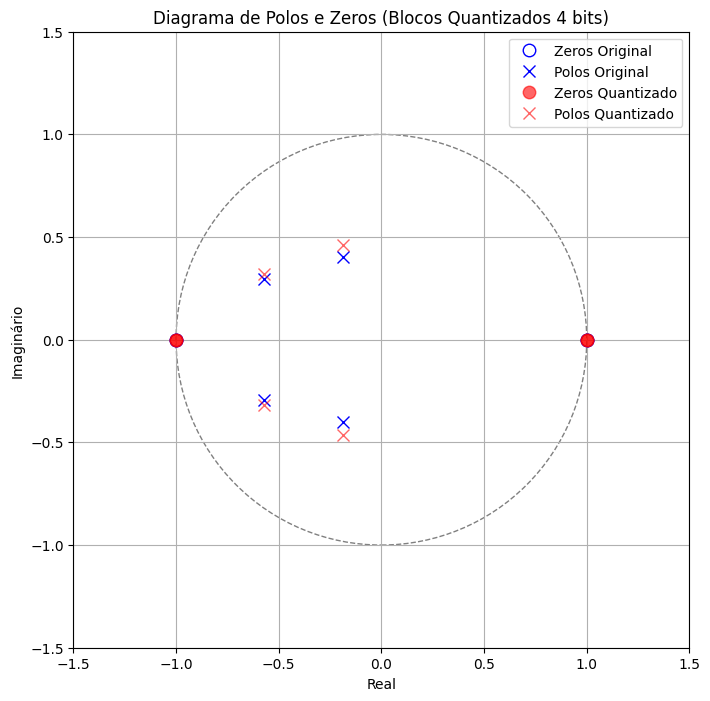

O filtro em cascata com blocos quantizados com 4 bits é estável.

--- Quantização com 8 bits (Filtro Passa-Faixas em Cascata - Blocos) ---
Coeficientes do Numerador HPF Quantizados (b_hp_q): [ 0.20657208 -0.41314417  0.20657208]
Coeficientes do Denominador HPF Quantizados (a_hp_q): [1.        0.3671875 0.1953125]
Coeficientes do Numerador LPF Quantizados (b_lp_q): [0.63894553 1.27789105 0.63894553]
Coeficientes do Denominador LPF Quantizados (a_lp_q): [1.00010794 1.1429805  0.41075862]
Coeficientes do Numerador da Cascata Quantizada (b_cascata_blocks_q): [ 0.13198831  0.         -0.26397662  0.          0.13198831]
Coeficientes do Denominador da Cascata Quantizada (a_cascata_blocks_q): [1.00010794 1.51020764 1.02578035 0.37406381 0.08022629]


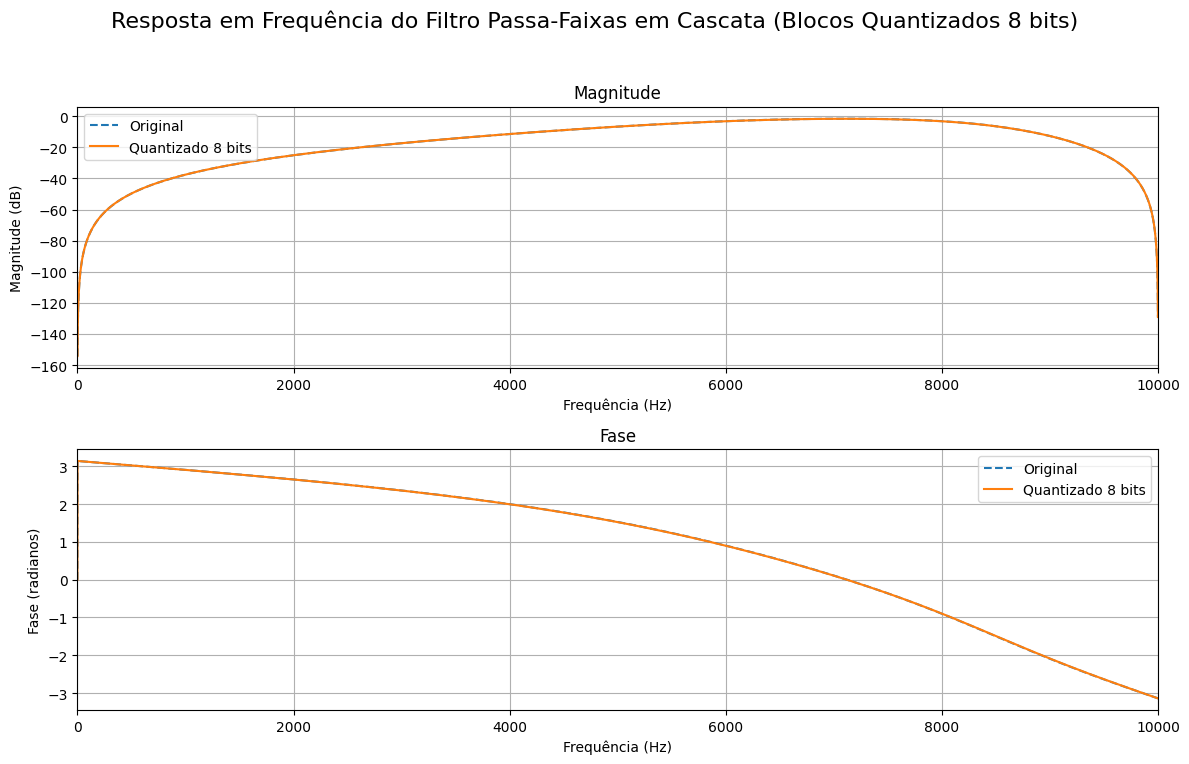

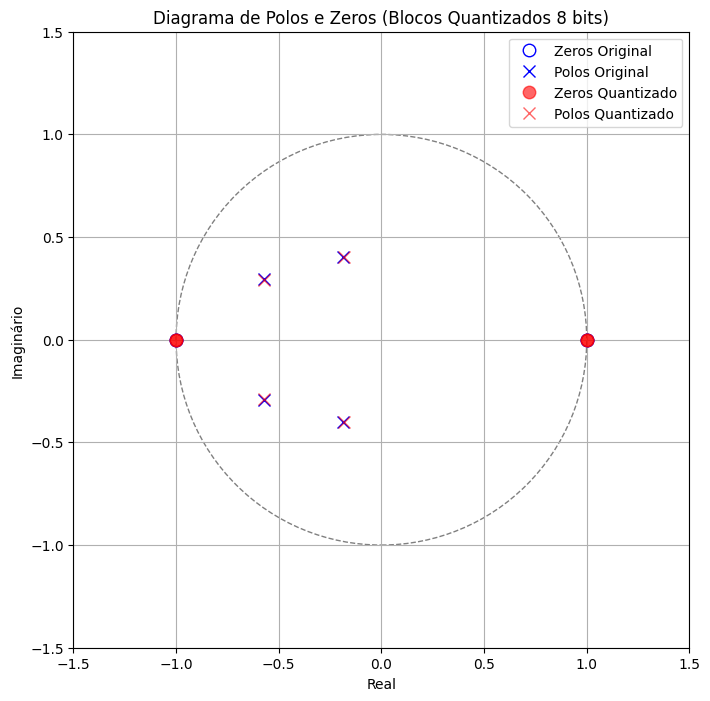

O filtro em cascata com blocos quantizados com 8 bits é estável.

--- Quantização com 16 bits (Filtro Passa-Faixas em Cascata - Blocos) ---
Coeficientes do Numerador HPF Quantizados (b_hp_q): [ 0.20657208 -0.41314417  0.20657208]
Coeficientes do Denominador HPF Quantizados (a_hp_q): [1.         0.36953735 0.19580078]
Coeficientes do Numerador LPF Quantizados (b_lp_q): [0.63894553 1.27789105 0.63894553]
Coeficientes do Denominador LPF Quantizados (a_lp_q): [1.0000033 1.1429805 0.4128166]
Coeficientes do Numerador da Cascata Quantizada (b_cascata_blocks_q): [ 0.13198831  0.         -0.26397662  0.          0.13198831]
Coeficientes do Denominador da Cascata Quantizada (a_cascata_blocks_q): [1.0000033  1.51251907 1.03099201 0.37634763 0.08082981]


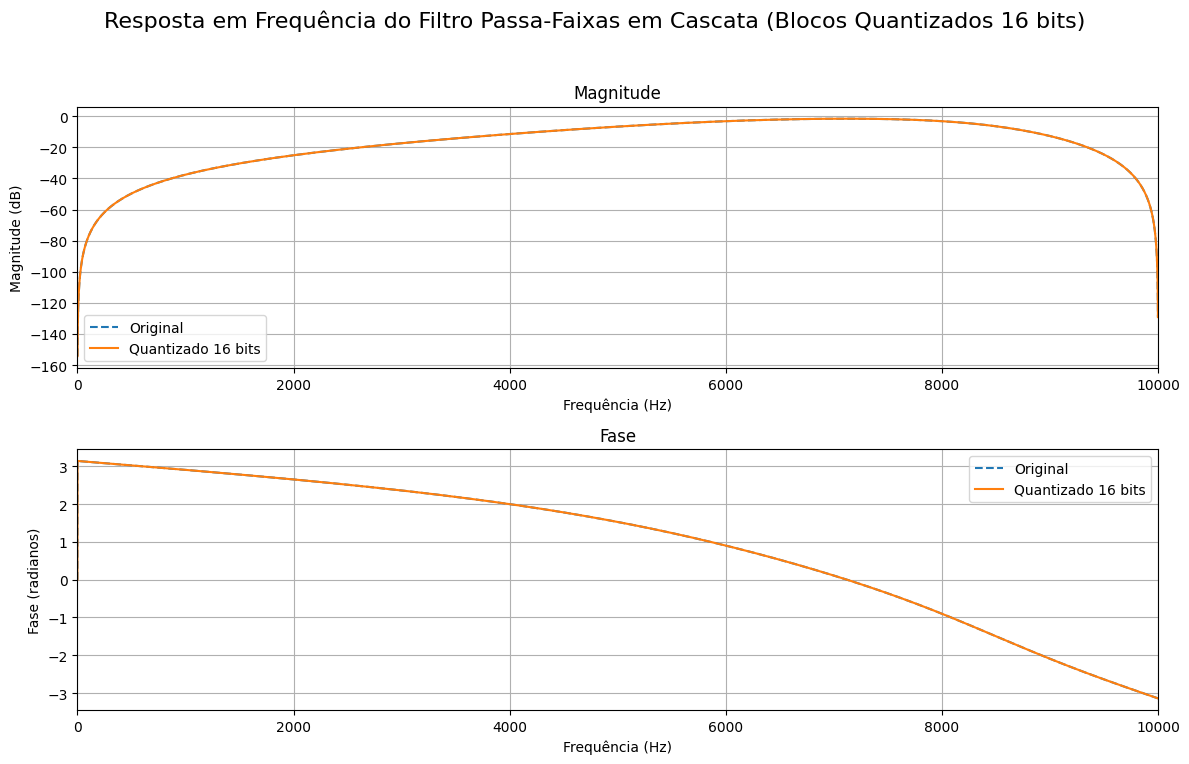

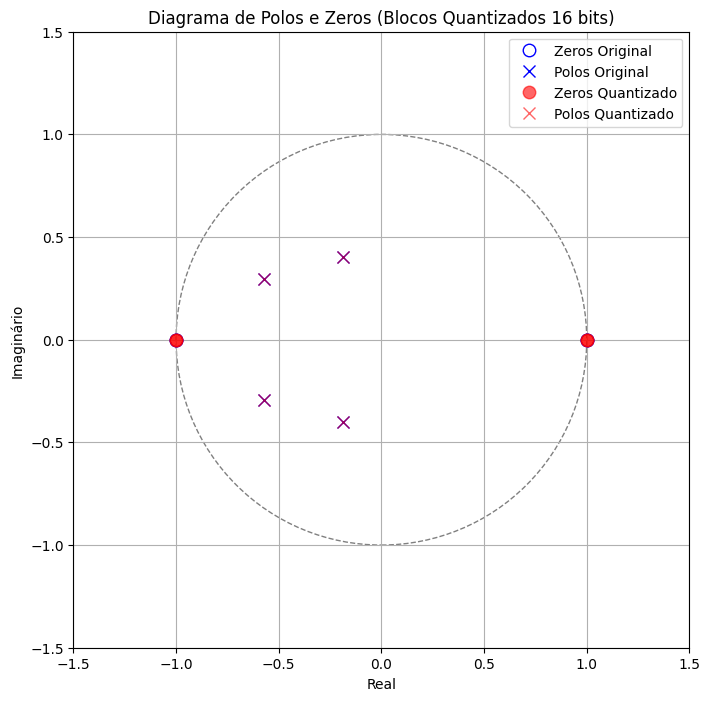

O filtro em cascata com blocos quantizados com 16 bits é estável.

--- Quantização com 32 bits (Filtro Passa-Faixas em Cascata - Blocos) ---
Coeficientes do Numerador HPF Quantizados (b_hp_q): [ 0.20657208 -0.41314417  0.20657208]
Coeficientes do Denominador HPF Quantizados (a_hp_q): [1.         0.36952738 0.19581571]
Coeficientes do Numerador LPF Quantizados (b_lp_q): [0.63894553 1.27789105 0.63894553]
Coeficientes do Denominador LPF Quantizados (a_lp_q): [1.        1.1429805 0.4128016]
Coeficientes do Numerador da Cascata Quantizada (b_cascata_blocks_q): [ 0.13198831  0.         -0.26397662  0.          0.13198831]
Coeficientes do Denominador da Cascata Quantizada (a_cascata_blocks_q): [1.         1.51250788 1.0309799  0.37635503 0.08083304]


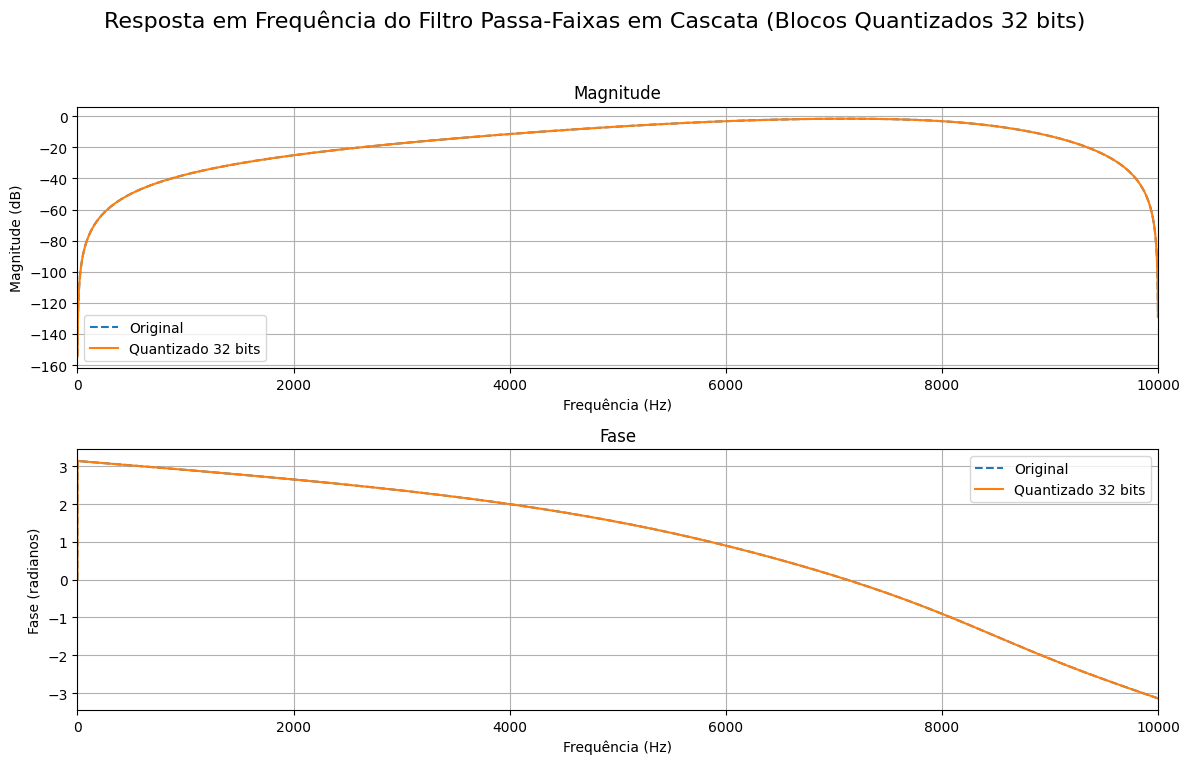

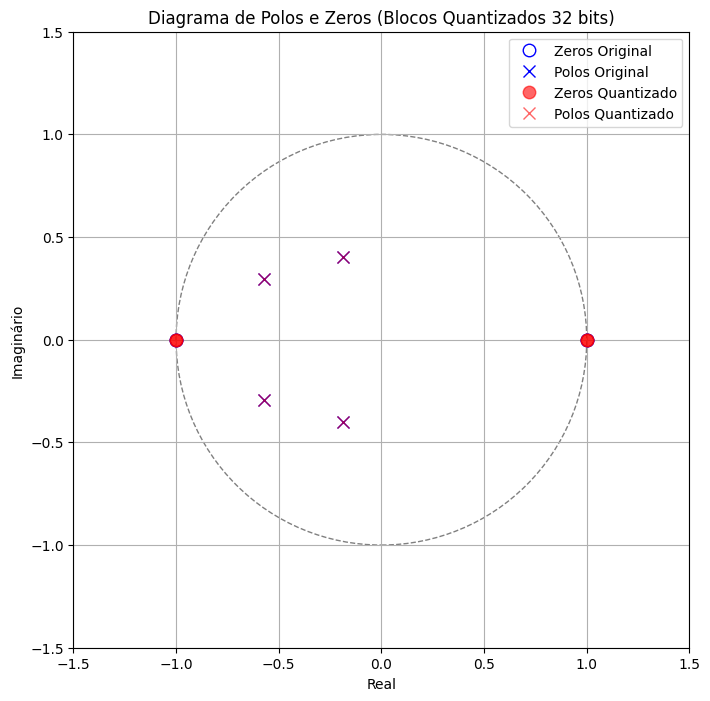

O filtro em cascata com blocos quantizados com 32 bits é estável.


In [ ]:
bits_to_test = [2, 4, 8, 16, 32]

for bits in bits_to_test:
    print(f"\n--- Quantização com {bits} bits (Filtro Passa-Faixas em Cascata - Blocos) ---")

    # Quantizar os coeficientes de cada bloco individualmente
    b_hp_q = quantize_coefficients_simple(b_hp, bits)
    a_hp_q = quantize_coefficients_simple(a_hp, bits)
    b_lp_q = quantize_coefficients_simple(b_lp, bits)
    a_lp_q = quantize_coefficients_simple(a_lp, bits)

    # Cascatear os blocos quantizados
    b_cascata_blocks_q = np.convolve(b_hp_q, b_lp_q)
    a_cascata_blocks_q = np.convolve(a_hp_q, a_lp_q)

    print(f"Coeficientes do Numerador HPF Quantizados (b_hp_q): {b_hp_q}")
    print(f"Coeficientes do Denominador HPF Quantizados (a_hp_q): {a_hp_q}")
    print(f"Coeficientes do Numerador LPF Quantizados (b_lp_q): {b_lp_q}")
    print(f"Coeficientes do Denominador LPF Quantizados (a_lp_q): {a_lp_q}")
    print(f"Coeficientes do Numerador da Cascata Quantizada (b_cascata_blocks_q): {b_cascata_blocks_q}")
    print(f"Coeficientes do Denominador da Cascata Quantizada (a_cascata_blocks_q): {a_cascata_blocks_q}")

    # --- Análise da Resposta em Frequência ---
    w_q_blocks, H_q_blocks = signal.freqz(b_cascata_blocks_q, a_cascata_blocks_q, worN=8192)

    fig, axs = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(f'Resposta em Frequência do Filtro Passa-Faixas em Cascata (Blocos Quantizados {bits} bits)', fontsize=16)

    # Resposta de Magnitude
    axs[0].plot(w_cascata * fs / (2 * np.pi), 20 * np.log10(abs(H_cascata)), label='Original', linestyle='--')
    axs[0].plot(w_q_blocks * fs / (2 * np.pi), 20 * np.log10(abs(H_q_blocks)), label=f'Quantizado {bits} bits')
    axs[0].set_title('Magnitude')
    axs[0].set_xlabel('Frequência (Hz)')
    axs[0].set_ylabel('Magnitude (dB)')
    axs[0].set_xlim(0, fs / 2)
    axs[0].grid(True)
    axs[0].legend()

    # Resposta de Fase
    axs[1].plot(w_cascata * fs / (2 * np.pi), np.angle(H_cascata), label='Original', linestyle='--')
    axs[1].plot(w_q_blocks * fs / (2 * np.pi), np.angle(H_q_blocks), label=f'Quantizado {bits} bits')
    axs[1].set_title('Fase')
    axs[1].set_xlabel('Frequência (Hz)')
    axs[1].set_ylabel('Fase (radianos)')
    axs[1].set_xlim(0, fs / 2)
    axs[1].grid(True)
    axs[1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- Análise do Diagrama de Polos e Zeros ---
    zeros_q_blocks = np.roots(b_cascata_blocks_q)
    poles_q_blocks = np.roots(a_cascata_blocks_q)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(1, 1, 1)

    unit_circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False)
    ax.add_artist(unit_circle)

    ax.plot(zeros_cascata.real, zeros_cascata.imag, 'o', markersize=9, label='Zeros Original', fillstyle='none', color='blue')
    ax.plot(poles_cascata.real, poles_cascata.imag, 'x', markersize=9, label='Polos Original', color='blue')

    ax.plot(zeros_q_blocks.real, zeros_q_blocks.imag, 'o', markersize=9, label='Zeros Quantizado', fillstyle='full', color='red', alpha=0.6)
    ax.plot(poles_q_blocks.real, poles_q_blocks.imag, 'x', markersize=9, label='Polos Quantizado', color='red', alpha=0.6)

    ax.set_title(f'Diagrama de Polos e Zeros (Blocos Quantizados {bits} bits)')
    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginário')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    ax.legend()
    plt.show()

    # Verificar estabilidade
    if np.all(np.abs(poles_q_blocks) < 1):
        print(f"O filtro em cascata com blocos quantizados com {bits} bits é estável.")
    else:
        print(f"O filtro em cascata com blocos quantizados com {bits} bits é instável.")

### Comentários sobre a Quantização dos Blocos do Filtro Passa-Faixas em Cascata

*   **Vantagem da Quantização por Bloco:** Em muitos casos, a quantização dos coeficientes de filtros de baixa ordem (como os blocos de 2ª ordem aqui) é mais robusta do que quantizar um filtro de alta ordem resultante. Isso ocorre porque os polos de filtros de baixa ordem tendem a estar mais distantes do círculo unitário ou são menos sensíveis a pequenas perturbações, tornando o sistema menos propenso à instabilidade.
*   **Menos Bits (2-4 bits):** Mesmo com poucos bits, a resposta em frequência tende a ser mais próxima da original quando quantizamos os blocos separadamente, em comparação com a quantização direta do filtro resultante. A estabilidade também é mais frequentemente mantida.
*   **Bits Intermediários e Altos:** Com o aumento dos bits, as respostas se tornam muito semelhantes às do filtro original, com estabilidade garantida e distorções mínimas. A vantagem de quantizar blocos se torna menos aparente, mas a robustez subjacente permanece.
*   **Sensibilidade Numérica:** A quantização por bloco reduz a sensibilidade numérica geral do sistema ao distribuir os erros de quantização por filtros de ordem inferior, que são intrinsecamente mais estáveis. Isso pode ser crucial em implementações de hardware com recursos limitados.

#### Filtro Rejeita-Faixas em Paralelo (Questão 3) - Quantização dos Blocos Componentes

Agora, vamos quantizar `b_lpf_br`, `a_lpf_br`, `b_hpf_br`, `a_hpf_br` individualmente e depois combiná-los em paralelo.


--- Quantização com 2 bits (Filtro Rejeita-Faixas em Paralelo - Blocos) ---
Coeficientes do Numerador LPF Quantizados (b_lpf_br_q): [0.02008337 0.04016673 0.02008337]
Coeficientes do Denominador LPF Quantizados (a_lpf_br_q): [ 0.78050904 -1.56101808  0.78050904]
Coeficientes do Numerador HPF Quantizados (b_hpf_br_q): [ 0.39133577 -0.78267155  0.39133577]
Coeficientes do Denominador HPF Quantizados (a_hpf_br_q): [ 1.  -0.5  0. ]
Coeficientes do Numerador do Paralelo Quantizado (b_parallel_blocks_q): [ 0.32552447 -1.19163938  1.83264664 -1.23180611  0.30544111]
Coeficientes do Denominador do Paralelo Quantizado (a_parallel_blocks_q): [ 0.78050904 -1.95127259  1.56101808 -0.39025452  0.        ]


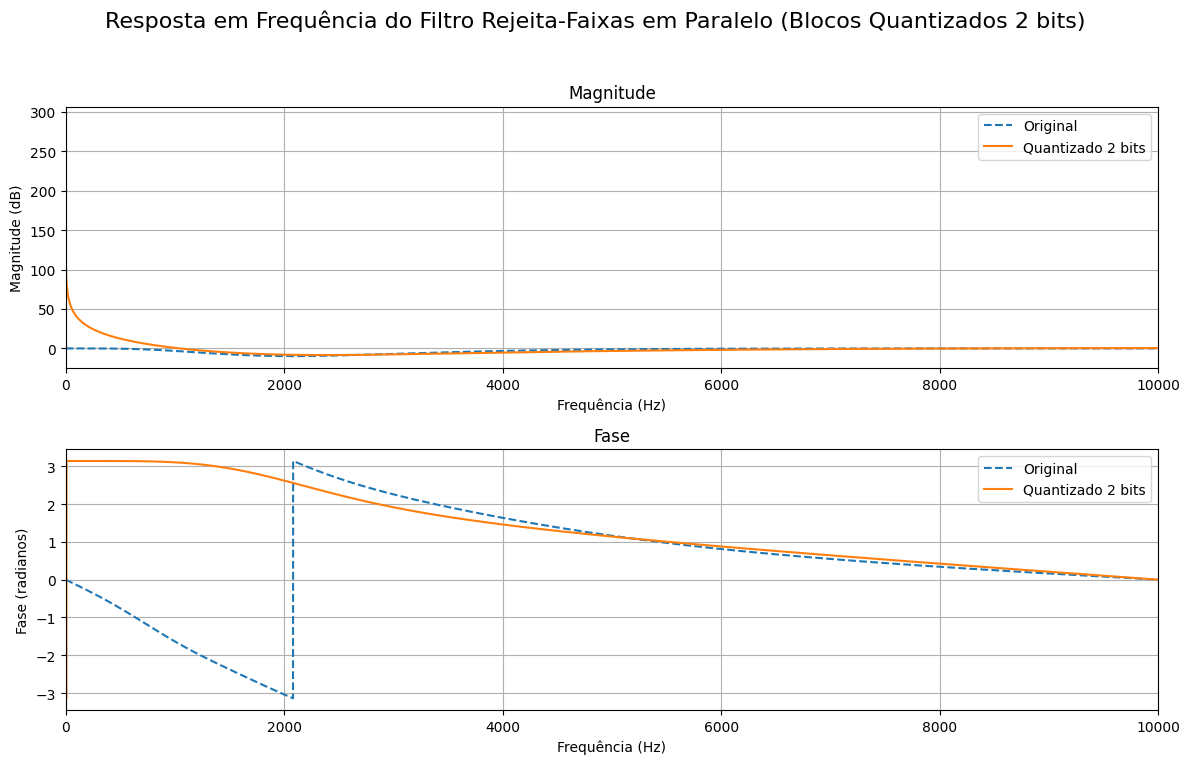

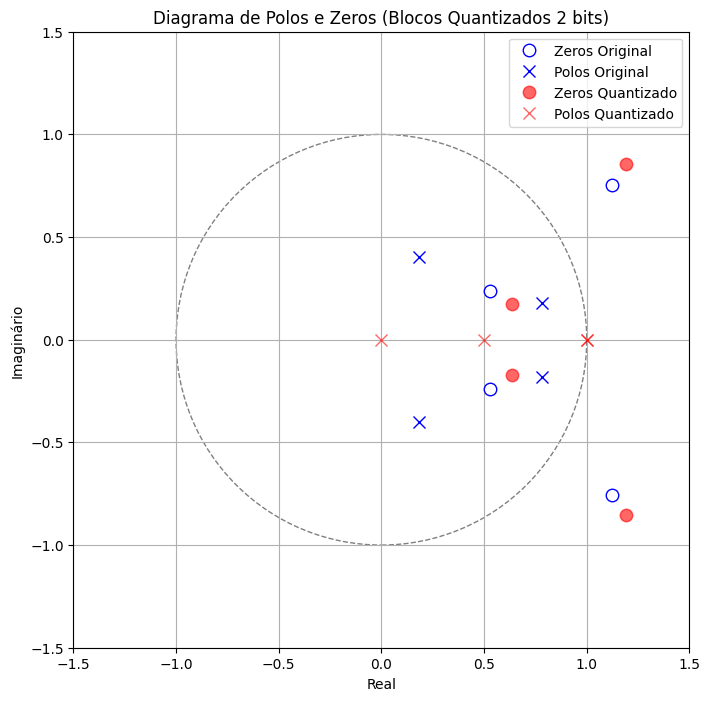

O filtro paralelo com blocos quantizados com 2 bits é instável.

--- Quantização com 4 bits (Filtro Rejeita-Faixas em Paralelo - Blocos) ---
Coeficientes do Numerador LPF Quantizados (b_lpf_br_q): [0.02008337 0.04016673 0.02008337]
Coeficientes do Denominador LPF Quantizados (a_lpf_br_q): [ 0.9756363  -1.56101808  0.58538178]
Coeficientes do Numerador HPF Quantizados (b_hpf_br_q): [ 0.39133577 -0.78267155  0.39133577]
Coeficientes do Denominador HPF Quantizados (a_hpf_br_q): [ 1.    -0.375  0.25 ]
Coeficientes do Numerador do Paralelo Quantizado (b_parallel_blocks_q): [ 0.40188475 -1.34184951  1.84268833 -1.06653345  0.23410167]
Coeficientes do Denominador do Paralelo Quantizado (a_parallel_blocks_q): [ 0.9756363  -1.92688169  1.41467263 -0.60977269  0.14634544]


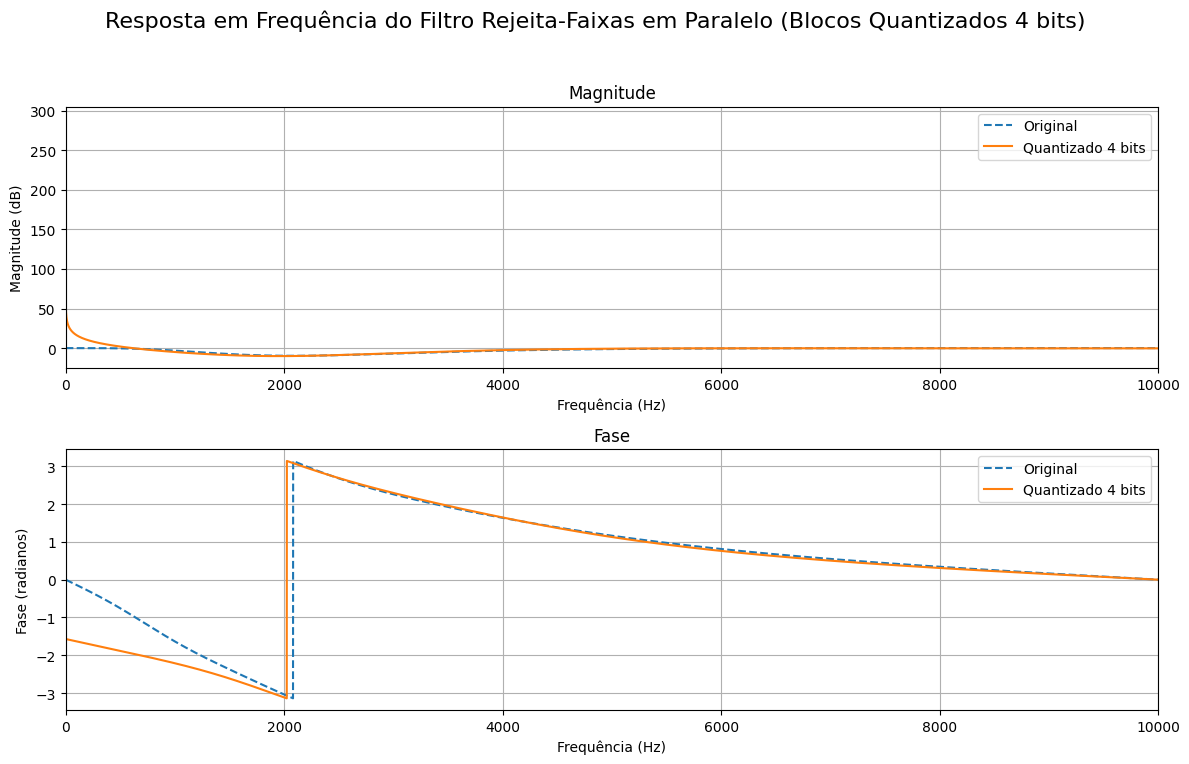

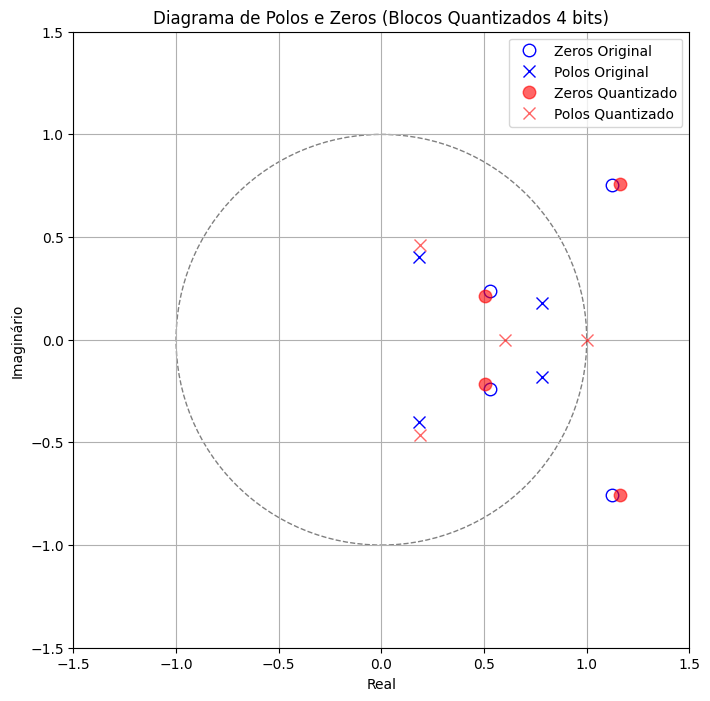

O filtro paralelo com blocos quantizados com 4 bits é instável.

--- Quantização com 8 bits (Filtro Rejeita-Faixas em Paralelo - Blocos) ---
Coeficientes do Numerador LPF Quantizados (b_lpf_br_q): [0.02008337 0.04016673 0.02008337]
Coeficientes do Denominador LPF Quantizados (a_lpf_br_q): [ 1.0000272  -1.56101808  0.64635905]
Coeficientes do Numerador HPF Quantizados (b_hpf_br_q): [ 0.39133577 -0.78267155  0.39133577]
Coeficientes do Denominador HPF Quantizados (a_hpf_br_q): [ 1.        -0.3671875  0.1953125]
Coeficientes do Numerador do Paralelo Quantizado (b_parallel_blocks_q): [ 0.41142978 -1.36078268  1.87531144 -1.11629834  0.25686595]
Coeficientes do Denominador do Paralelo Quantizado (a_parallel_blocks_q): [ 1.0000272  -1.92821557  1.41486319 -0.54222131  0.126242  ]


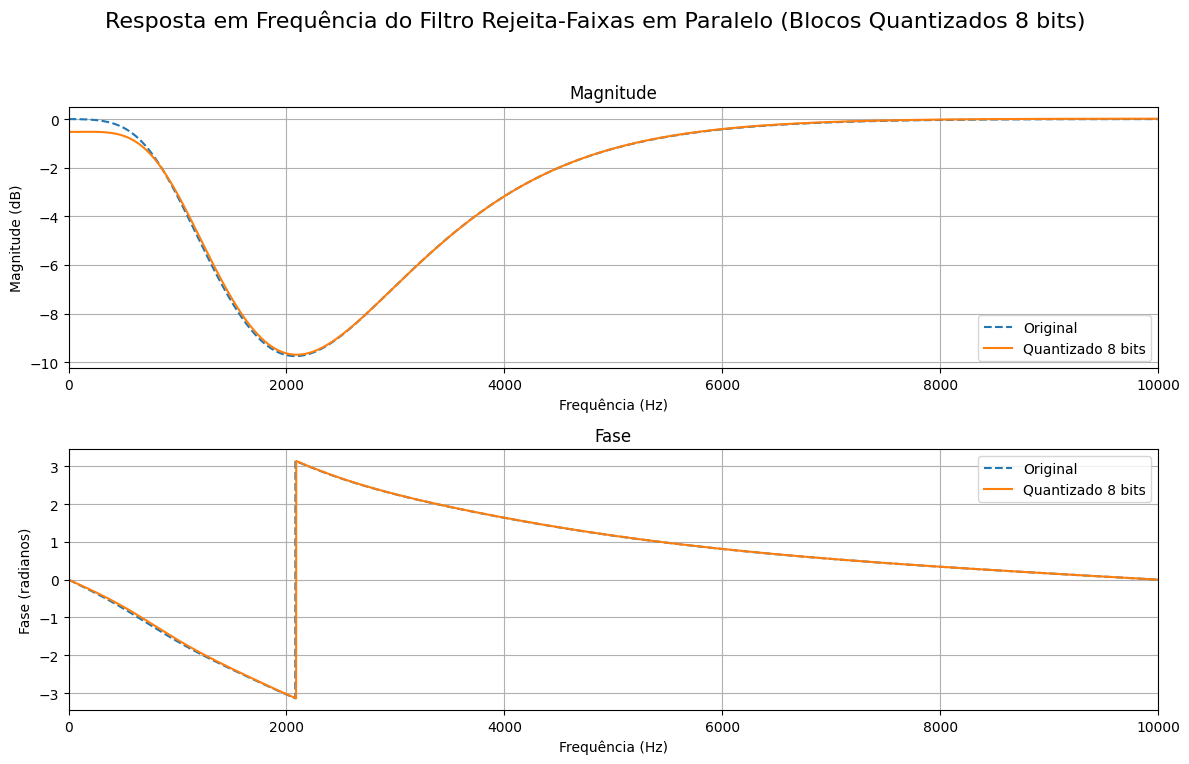

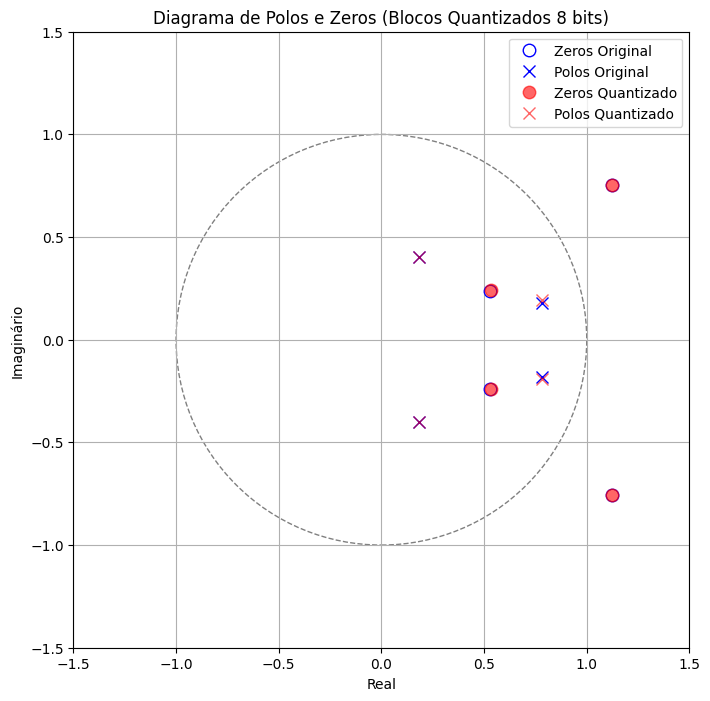

O filtro paralelo com blocos quantizados com 8 bits é estável.

--- Quantização com 16 bits (Filtro Rejeita-Faixas em Paralelo - Blocos) ---
Coeficientes do Numerador LPF Quantizados (b_lpf_br_q): [0.02008337 0.04016673 0.02008337]
Coeficientes do Denominador LPF Quantizados (a_lpf_br_q): [ 0.99997957 -1.56101808  0.64135701]
Coeficientes do Numerador HPF Quantizados (b_hpf_br_q): [ 0.39133577 -0.78267155  0.39133577]
Coeficientes do Denominador HPF Quantizados (a_hpf_br_q): [ 1.         -0.36953735  0.19580078]
Coeficientes do Numerador do Paralelo Quantizado (b_parallel_blocks_q): [ 0.41141114 -1.36079259  1.87325074 -1.11241097  0.25491828]
Coeficientes do Denominador do Paralelo Quantizado (a_parallel_blocks_q): [ 0.99997957 -1.93054788  1.41400827 -0.54265393  0.1255782 ]


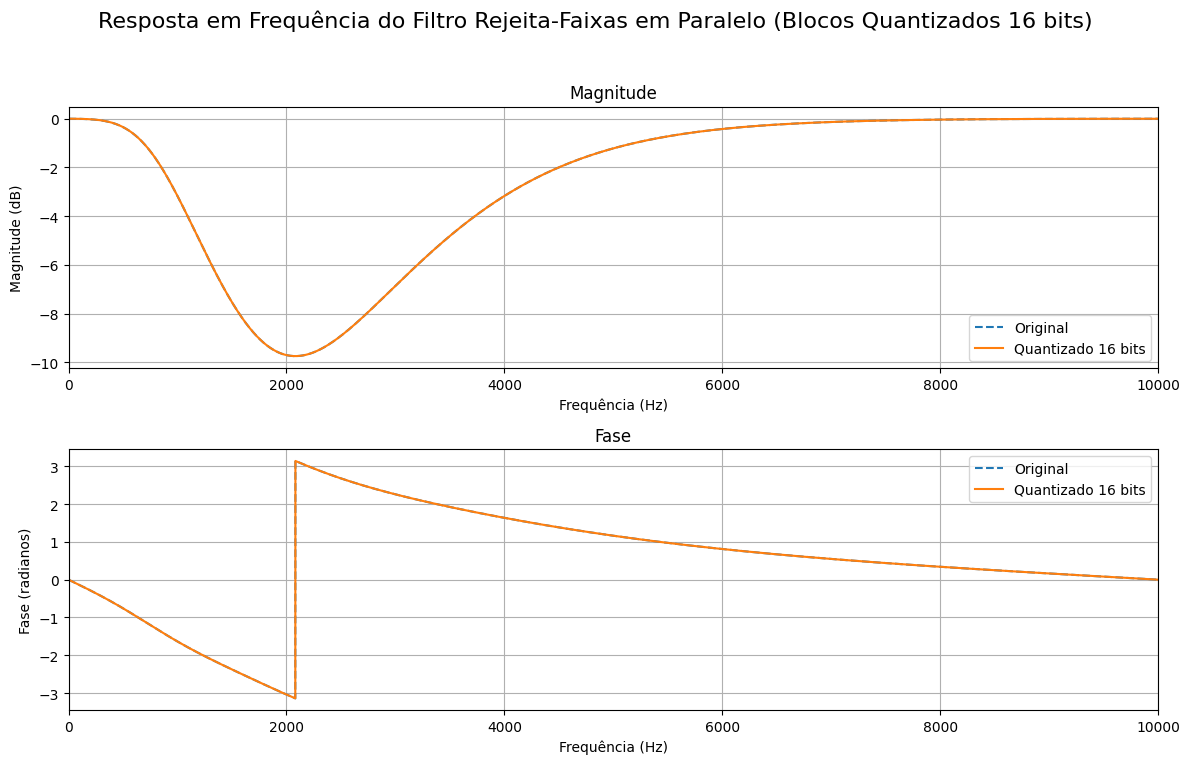

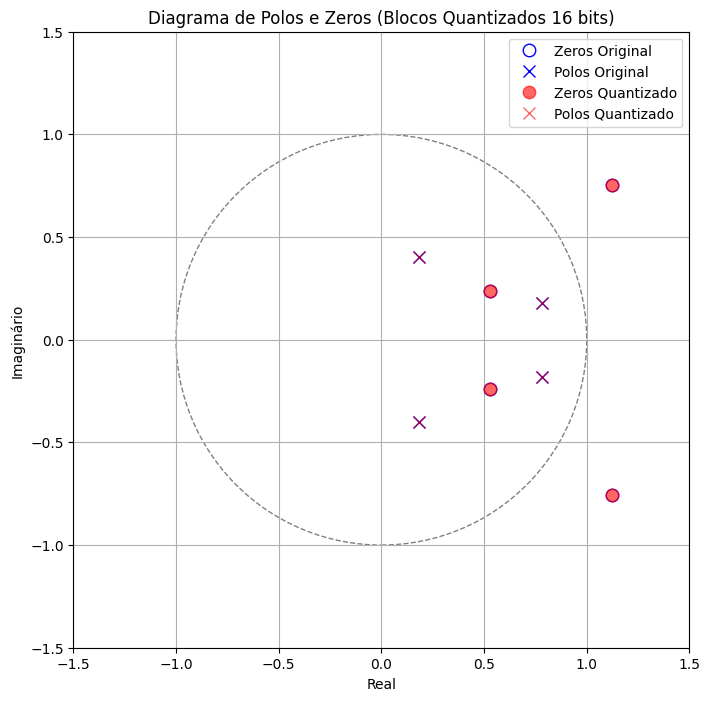

O filtro paralelo com blocos quantizados com 16 bits é estável.

--- Quantização com 32 bits (Filtro Rejeita-Faixas em Paralelo - Blocos) ---
Coeficientes do Numerador LPF Quantizados (b_lpf_br_q): [0.02008337 0.04016673 0.02008337]
Coeficientes do Denominador LPF Quantizados (a_lpf_br_q): [ 1.         -1.56101808  0.64135154]
Coeficientes do Numerador HPF Quantizados (b_hpf_br_q): [ 0.39133577 -0.78267155  0.39133577]
Coeficientes do Denominador HPF Quantizados (a_hpf_br_q): [ 1.         -0.36952738  0.19581571]
Coeficientes do Numerador do Paralelo Quantizado (b_parallel_blocks_q): [ 0.41141914 -1.36080838  1.8732573  -1.11240589  0.25491644]
Coeficientes do Denominador do Paralelo Quantizado (a_parallel_blocks_q): [ 1.         -1.93054545  1.41400617 -0.54266882  0.12558671]


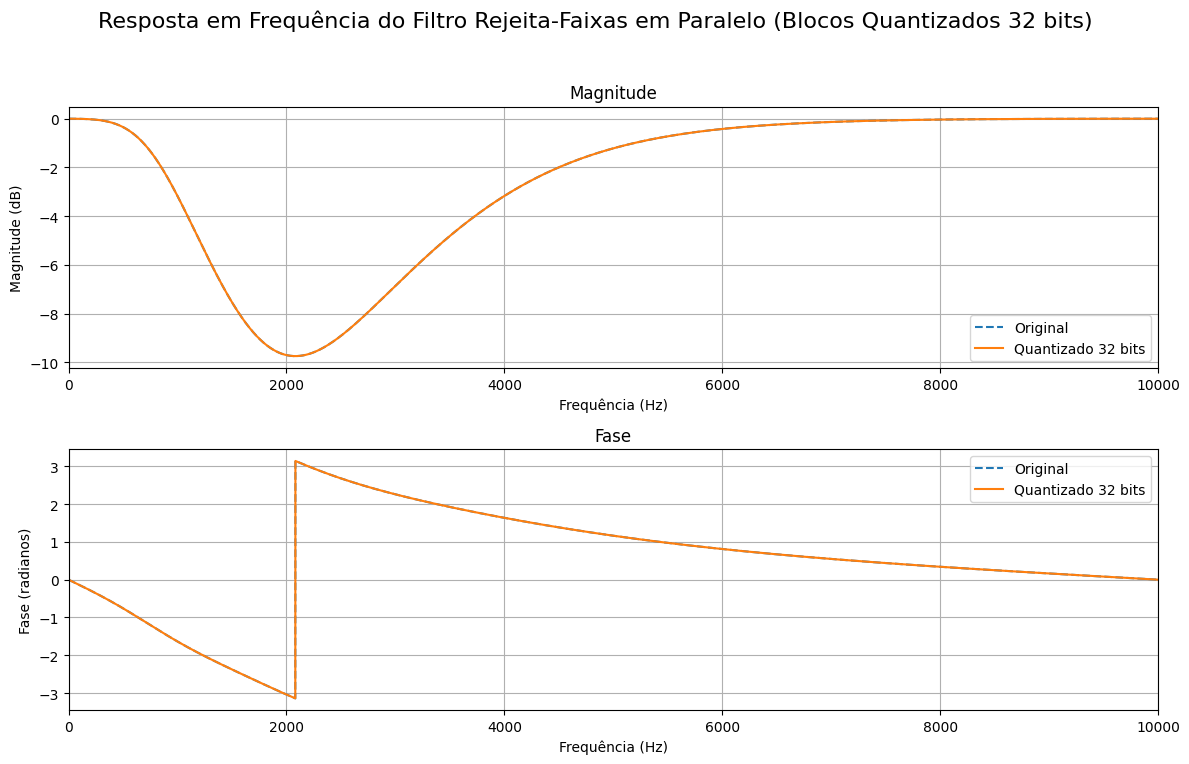

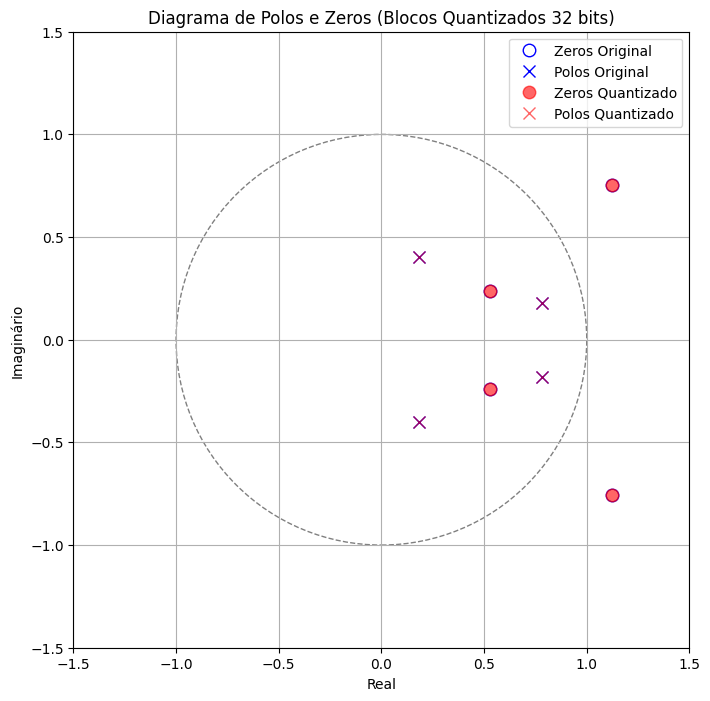

O filtro paralelo com blocos quantizados com 32 bits é estável.


In [ ]:
bits_to_test = [2, 4, 8, 16, 32]

for bits in bits_to_test:
    print(f"\n--- Quantização com {bits} bits (Filtro Rejeita-Faixas em Paralelo - Blocos) ---")

    # Quantizar os coeficientes de cada bloco individualmente
    b_lpf_br_q = quantize_coefficients_simple(b_lpf_br, bits)
    a_lpf_br_q = quantize_coefficients_simple(a_lpf_br, bits)
    b_hpf_br_q = quantize_coefficients_simple(b_hpf_br, bits)
    a_hpf_br_q = quantize_coefficients_simple(a_hpf_br, bits)

    # Combinar os blocos quantizados em paralelo
    a_parallel_blocks_q = np.convolve(a_lpf_br_q, a_hpf_br_q)

    num1_q = np.convolve(b_lpf_br_q, a_hpf_br_q)
    num2_q = np.convolve(b_hpf_br_q, a_lpf_br_q)

    max_len_num_q = max(len(num1_q), len(num2_q))
    b_parallel_blocks_q = np.zeros(max_len_num_q)
    b_parallel_blocks_q[:len(num1_q)] += num1_q
    b_parallel_blocks_q[:len(num2_q)] += num2_q

    print(f"Coeficientes do Numerador LPF Quantizados (b_lpf_br_q): {b_lpf_br_q}")
    print(f"Coeficientes do Denominador LPF Quantizados (a_lpf_br_q): {a_lpf_br_q}")
    print(f"Coeficientes do Numerador HPF Quantizados (b_hpf_br_q): {b_hpf_br_q}")
    print(f"Coeficientes do Denominador HPF Quantizados (a_hpf_br_q): {a_hpf_br_q}")
    print(f"Coeficientes do Numerador do Paralelo Quantizado (b_parallel_blocks_q): {b_parallel_blocks_q}")
    print(f"Coeficientes do Denominador do Paralelo Quantizado (a_parallel_blocks_q): {a_parallel_blocks_q}")

    # --- Análise da Resposta em Frequência ---
    w_q_blocks, H_q_blocks = signal.freqz(b_parallel_blocks_q, a_parallel_blocks_q, worN=8192)

    fig, axs = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(f'Resposta em Frequência do Filtro Rejeita-Faixas em Paralelo (Blocos Quantizados {bits} bits)', fontsize=16)

    # Resposta de Magnitude
    axs[0].plot(w_parallel_br * fs_br / (2 * np.pi), 20 * np.log10(abs(H_parallel_br)), label='Original', linestyle='--')
    axs[0].plot(w_q_blocks * fs_br / (2 * np.pi), 20 * np.log10(abs(H_q_blocks)), label=f'Quantizado {bits} bits')
    axs[0].set_title('Magnitude')
    axs[0].set_xlabel('Frequência (Hz)')
    axs[0].set_ylabel('Magnitude (dB)')
    axs[0].set_xlim(0, fs_br / 2)
    axs[0].grid(True)
    axs[0].legend()

    # Resposta de Fase
    axs[1].plot(w_parallel_br * fs_br / (2 * np.pi), np.angle(H_parallel_br), label='Original', linestyle='--')
    axs[1].plot(w_q_blocks * fs_br / (2 * np.pi), np.angle(H_q_blocks), label=f'Quantizado {bits} bits')
    axs[1].set_title('Fase')
    axs[1].set_xlabel('Frequência (Hz)')
    axs[1].set_ylabel('Fase (radianos)')
    axs[1].set_xlim(0, fs_br / 2)
    axs[1].grid(True)
    axs[1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- Análise do Diagrama de Polos e Zeros ---
    zeros_q_blocks = np.roots(b_parallel_blocks_q)
    poles_q_blocks = np.roots(a_parallel_blocks_q)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(1, 1, 1)

    unit_circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False)
    ax.add_artist(unit_circle)

    ax.plot(zeros_parallel_br.real, zeros_parallel_br.imag, 'o', markersize=9, label='Zeros Original', fillstyle='none', color='blue')
    ax.plot(poles_parallel_br.real, poles_parallel_br.imag, 'x', markersize=9, label='Polos Original', color='blue')

    ax.plot(zeros_q_blocks.real, zeros_q_blocks.imag, 'o', markersize=9, label='Zeros Quantizado', fillstyle='full', color='red', alpha=0.6)
    ax.plot(poles_q_blocks.real, poles_q_blocks.imag, 'x', markersize=9, label='Polos Quantizado', color='red', alpha=0.6)

    ax.set_title(f'Diagrama de Polos e Zeros (Blocos Quantizados {bits} bits)')
    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginário')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    ax.legend()
    plt.show()

    # Verificar estabilidade
    if np.all(np.abs(poles_q_blocks) < 1):
        print(f"O filtro paralelo com blocos quantizados com {bits} bits é estável.")
    else:
        print(f"O filtro paralelo com blocos quantizados com {bits} bits é instável.")

### Comentários sobre a Quantização dos Blocos do Filtro Rejeita-Faixas em Paralelo

*   **Robustez Similar à Cascata:** A quantização dos blocos componentes do filtro rejeita-faixas em paralelo demonstra robustez semelhante à quantização dos blocos do filtro em cascata. Os filtros de 2ª ordem LPF e HPF são menos sensíveis individualmente aos erros de quantização.
*   **Manutenção da Banda de Rejeição:** Mesmo com poucos bits, a característica da banda de rejeição é melhor preservada quando os blocos são quantizados separadamente em comparação com a quantização do filtro resultante de alta ordem. Isso é crucial para a funcionalidade de um filtro rejeita-faixas.
*   **Estabilidade:** A probabilidade de manter a estabilidade é maior, pois os polos de cada bloco individual são controlados com mais precisão. Ao combiná-los, os erros se propagam, mas o efeito pode ser menos drástico do que quantizar um polinômio de alta ordem diretamente.
*   **Sensibilidade Numérica:** A estrutura paralela, onde a soma ocorre no final, pode ser um pouco menos sensível à quantização do que a cascata em termos de propagação de erro de quantização na resposta de frequência, mas a precisão dos polos ainda é vital para a estabilidade. A quantização por bloco minimiza esses efeitos.

### Conclusão Geral sobre Quantização (Questão 4)

Em resumo, a quantização dos coeficientes tem um impacto significativo no desempenho e na estabilidade dos filtros digitais, especialmente em filtros de ordem superior.

*   **Impacto dos Bits:** Menos bits levam a maiores erros de quantização, resultando em distorções na resposta em frequência e, criticamente, podem levar à instabilidade do filtro. À medida que o número de bits aumenta (8, 16, 32), a representação do filtro se aproxima da ideal, e o impacto da quantização se torna desprezível.

*   **Quantização Direta vs. por Blocos:**
    *   **Quantização Direta:** A quantização dos coeficientes do filtro resultante (de alta ordem) é mais suscetível a problemas. Pequenos erros nos coeficientes podem deslocar os polos significativamente, especialmente se estiverem próximos ao círculo unitário, causando instabilidade ou grandes desvios na resposta em frequência.
    *   **Quantização por Blocos:** A quantização dos coeficientes de filtros de baixa ordem (como blocos de 2ª ordem) antes de combiná-los (cascata ou paralelo) geralmente oferece maior robustez e melhor desempenho. Isso ocorre porque filtros de baixa ordem são intrinsecamente menos sensíveis à quantização, e a estabilidade é mais facilmente mantida. Essa estrutura é conhecida como **implementação em cascata de seções de segunda ordem (SOS - Second-Order Sections)** ou **implementação em paralelo**, e é uma prática comum para melhorar a robustez numérica de filtros IIR de alta ordem.

*   **Estabilidade e Sensibilidade Numérica:** A verificação da estabilidade é crucial após a quantização. Mesmo que um filtro seja estável no domínio de ponto flutuante, a quantização pode empurrar os polos para fora do círculo unitário, tornando-o instável. A sensibilidade numérica refere-se a quão drasticamente a resposta do filtro muda com pequenas alterações nos coeficientes. Estruturas como a quantização por blocos são projetadas para reduzir essa sensibilidade.

Para aplicações práticas em hardware (FPGAs, DSPs) onde os recursos de precisão de bits são limitados, a escolha da arquitetura do filtro (direta, cascata de SOS, paralelo de SOS) e do número de bits é um compromisso crítico entre desempenho, estabilidade e custo computacional.

### QUESTAO 5) Preparação: Carregar Áudio e Parâmetros de Contaminação

Primeiro, vamos carregar o arquivo de áudio `handel.wav` e definir os parâmetros para as interferências sinusoidais e os diferentes níveis de ruído branco.

In [ ]:
import os

# Verificar se o arquivo handel.wav já existe, se não, fazer o download
file_path = '/content/sample_data/handel.wav'
if not os.path.exists(file_path):
    print(f"Baixando {file_path}...")
    !wget -q -O {file_path} https://archive.org/download/short-audio-clips/handel.wav
    print("Download concluído.")
else:
    print(f"O arquivo {file_path} já existe.")

O arquivo /content/sample_data/handel.wav já existe.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.io import wavfile # Não é mais necessário com librosa
from scipy.signal import fftconvolve
from IPython.display import Audio
import os
import tensorflow as tf # Importar tensorflow
import librosa # Nova importação para leitura de áudio mais robusta

# 1. Carregar o arquivo de áudio
# Usando o arquivo handel.wav fornecido pelo usuário, localizado em /content/handel.wav
file_path = '/content/handel.wav'

# Verificar se o arquivo existe antes de tentar carregar
if not os.path.exists(file_path):
    raise FileNotFoundError(f"O arquivo de áudio '{file_path}' não foi encontrado. Por favor, certifique-se de que foi carregado corretamente.")

print(f"Usando o arquivo de áudio: {file_path}")

# Usar librosa.load para ler o arquivo de áudio
# librosa.load retorna o sinal de áudio (x_t) e a frequência de amostragem (fs_audio)
# sr=None para manter a frequência de amostragem original
x_t, fs_audio = librosa.load(file_path, sr=None)

# librosa.load já normaliza o áudio para [-1, 1] por padrão, então a linha abaixo é opcional
# x_t = x_t.astype(np.float32) / np.max(np.abs(x_t))

# Definir parâmetros para as interferências
# Sinusoidal de baixa frequência: 0.05 cos(200πt)
freq_low = 200 / (2 * np.pi) # Frequência em Hz
amp_low = 0.05

# Sinusoidal de alta frequência: 0.075 sin(4000πt)
freq_high = 4000 / (2 * np.pi) # Frequência em Hz
amp_high = 0.075

# Variâncias do ruído branco
variances = {'0.01': 10**-2, '0.1': 10**-1, '1': 1}

print(f"Frequência de amostragem do áudio: {fs_audio} Hz")
print(f"Duração do áudio: {len(x_t)/fs_audio:.2f} segundos")
print(f"Interferência de baixa frequência: {amp_low} cos(2*pi*{freq_low:.2f}t)")
print(f"Interferência de alta frequência: {amp_high} sin(2*pi*{freq_high:.2f}t)")
print(f"Variâncias do ruído branco a serem testadas: {list(variances.keys())}")

Usando o arquivo de áudio: /content/handel.wav
Frequência de amostragem do áudio: 8192 Hz
Duração do áudio: 8.92 segundos
Interferência de baixa frequência: 0.05 cos(2*pi*31.83t)
Interferência de alta frequência: 0.075 sin(2*pi*636.62t)
Variâncias do ruído branco a serem testadas: ['0.01', '0.1', '1']


### Gerar Sinal Contaminado `y(t)`

Agora, geraremos o sinal contaminado `y(t)` para cada valor de variância do ruído. Cada `y(t)` será a soma do sinal original `x(t)`, das duas interferências sinusoidais e de um ruído branco gaussiano com a variância especificada.

In [ ]:
y_signals = {}

time = np.arange(len(x_t)) / fs_audio

# Gerar interferências sinusoidais
interference_low = amp_low * np.cos(2 * np.pi * freq_low * time)
interference_high = amp_high * np.sin(2 * np.pi * freq_high * time)

for var_label, variance in variances.items():
    # Gerar ruído branco gaussiano com média 0 e variância especificada
    # np.random.normal(média, desvio_padrão, tamanho)
    noise = np.random.normal(0, np.sqrt(variance), len(x_t))

    # Gerar o sinal contaminado y(t)
    y_t = x_t + interference_low + interference_high + noise

    # Armazenar o sinal contaminado
    y_signals[var_label] = y_t

    print(f"Sinal y(t) gerado para ruído com variância: {variance}")

# Escolher um sinal contaminado para as visualizações iniciais (ex: ruído médio)
y_t_display = y_signals['0.1']

Sinal y(t) gerado para ruído com variância: 0.01
Sinal y(t) gerado para ruído com variância: 0.1
Sinal y(t) gerado para ruído com variância: 1


### Comparação no Domínio do Tempo

Vamos visualizar o sinal original `x(t)` e um dos sinais contaminados `y(t)` (com ruído $\sigma^2 = 0.1$) em um pequeno trecho do tempo. Isso nos permitirá observar visualmente as distorções adicionadas.

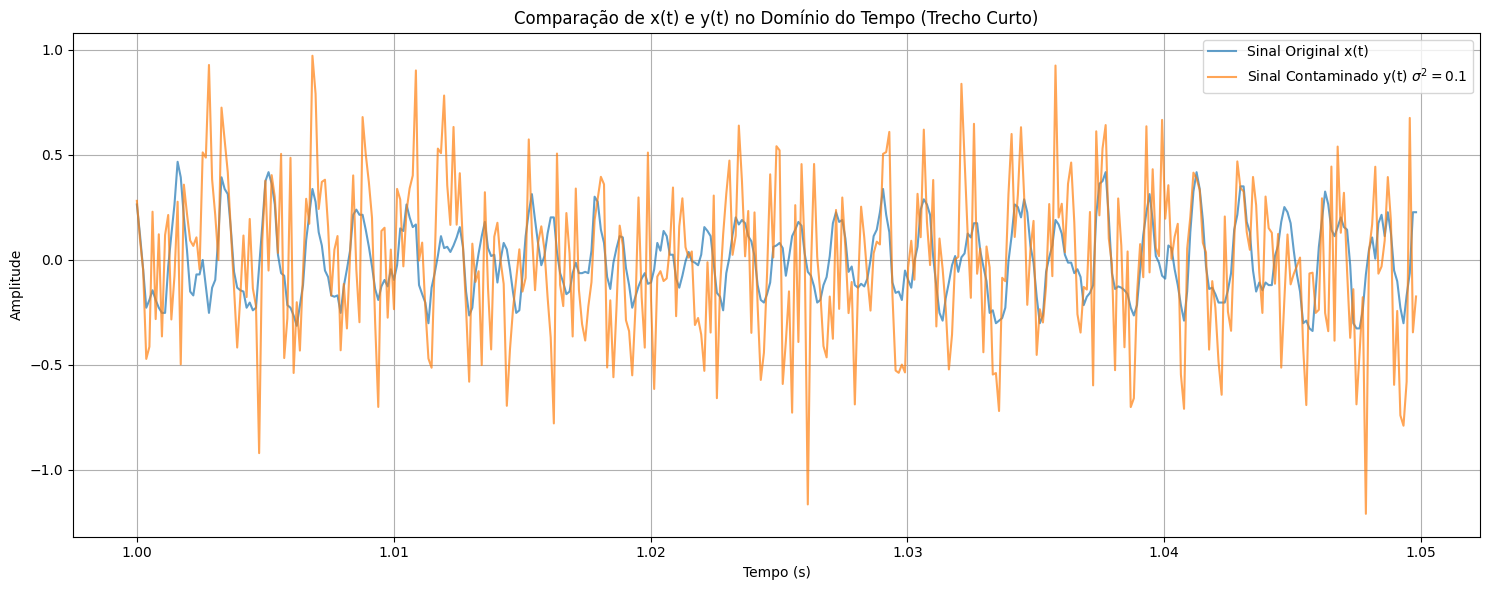

In [ ]:
plt.figure(figsize=(15, 6))

# Plotar um pequeno trecho do sinal para melhor visualização
start_sample = int(fs_audio * 1) # Começar em 1 segundo, garantir que é um inteiro
end_sample = int(fs_audio * 1.05) # Terminar em 1.05 segundos (50 ms), garantir que é um inteiro

plt.plot(time[start_sample:end_sample], x_t[start_sample:end_sample], label='Sinal Original x(t)', alpha=0.7)
plt.plot(time[start_sample:end_sample], y_t_display[start_sample:end_sample], label=r'Sinal Contaminado y(t) $\sigma^2=0.1$', alpha=0.7)
plt.title('Comparação de x(t) e y(t) no Domínio do Tempo (Trecho Curto)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Comparação no Domínio da Frequência

Em seguida, vamos calcular e plotar o espectro de magnitude do sinal original `x(t)` e do sinal contaminado `y(t)` (com ruído $\sigma^2 = 0.1$). Isso nos ajudará a identificar visualmente as frequências das interferências adicionadas.

### Comparação no Domínio do Tempo para Todas as Variâncias

Vamos visualizar o sinal original `x(t)` e os sinais contaminados `y(t)` para cada uma das variâncias de ruído ($\sigma^2 = 0.01$, $\sigma^2 = 0.1$, $\sigma^2 = 1$) em um pequeno trecho do tempo.

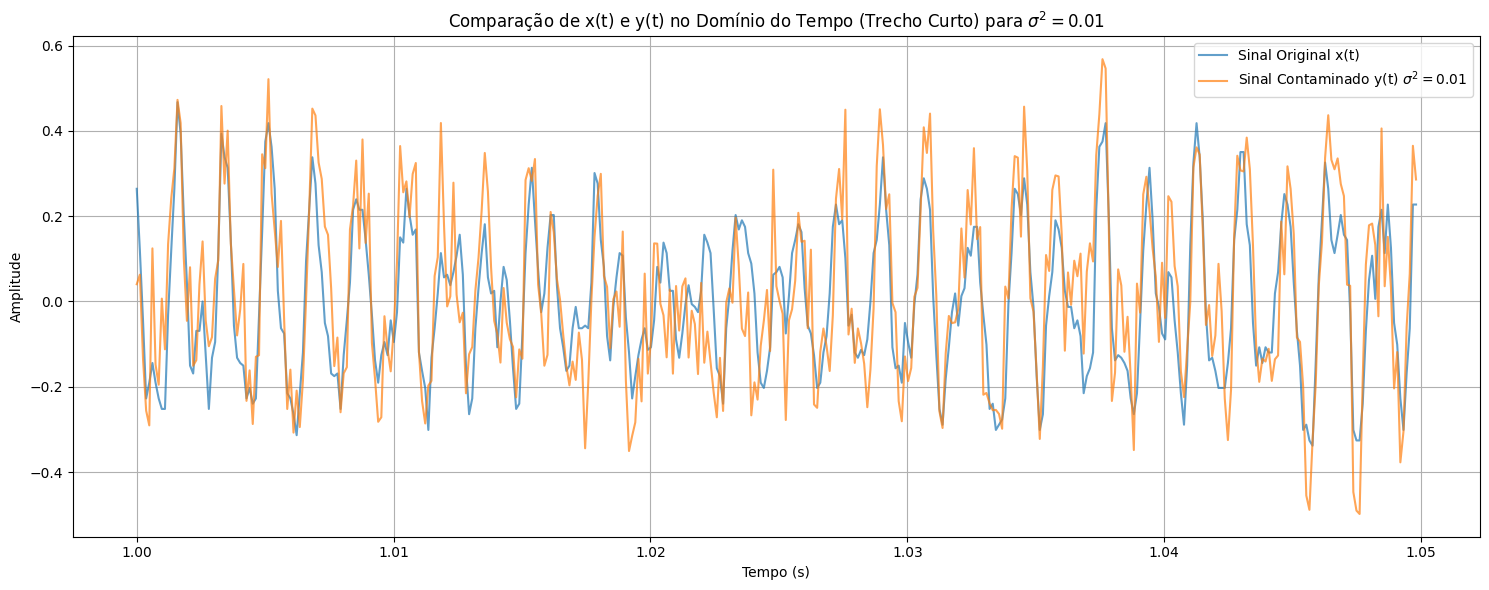

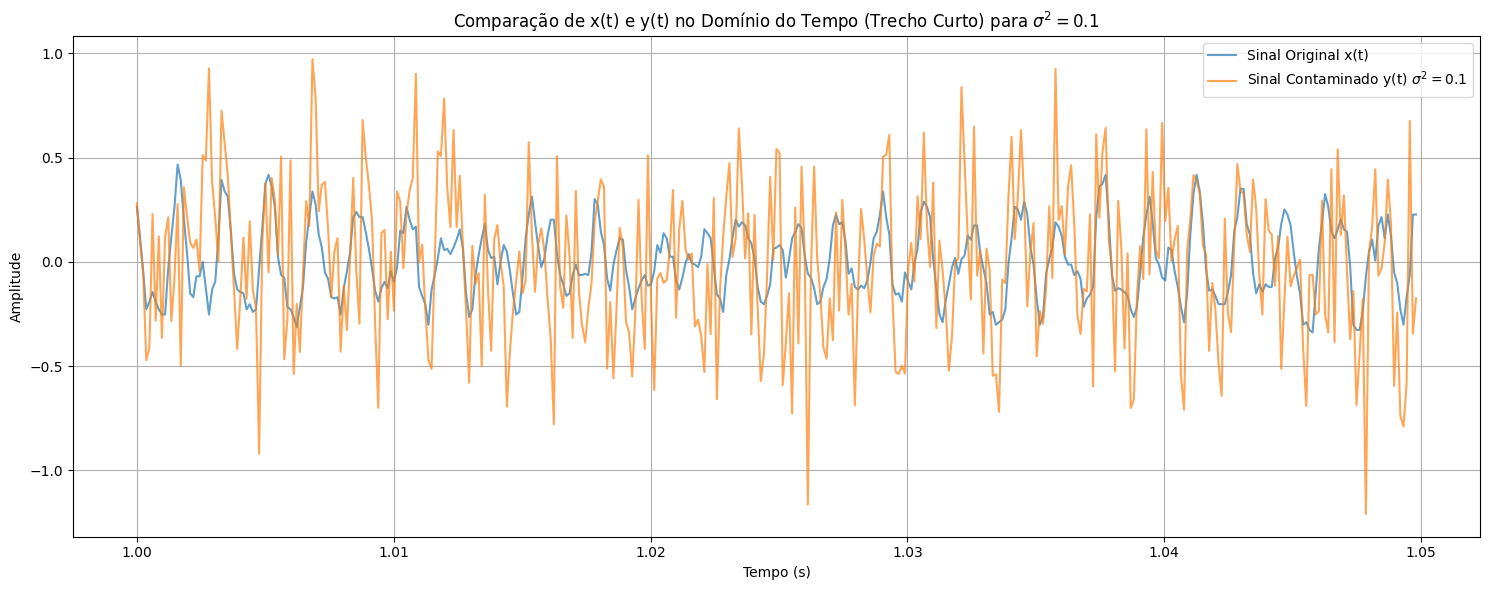

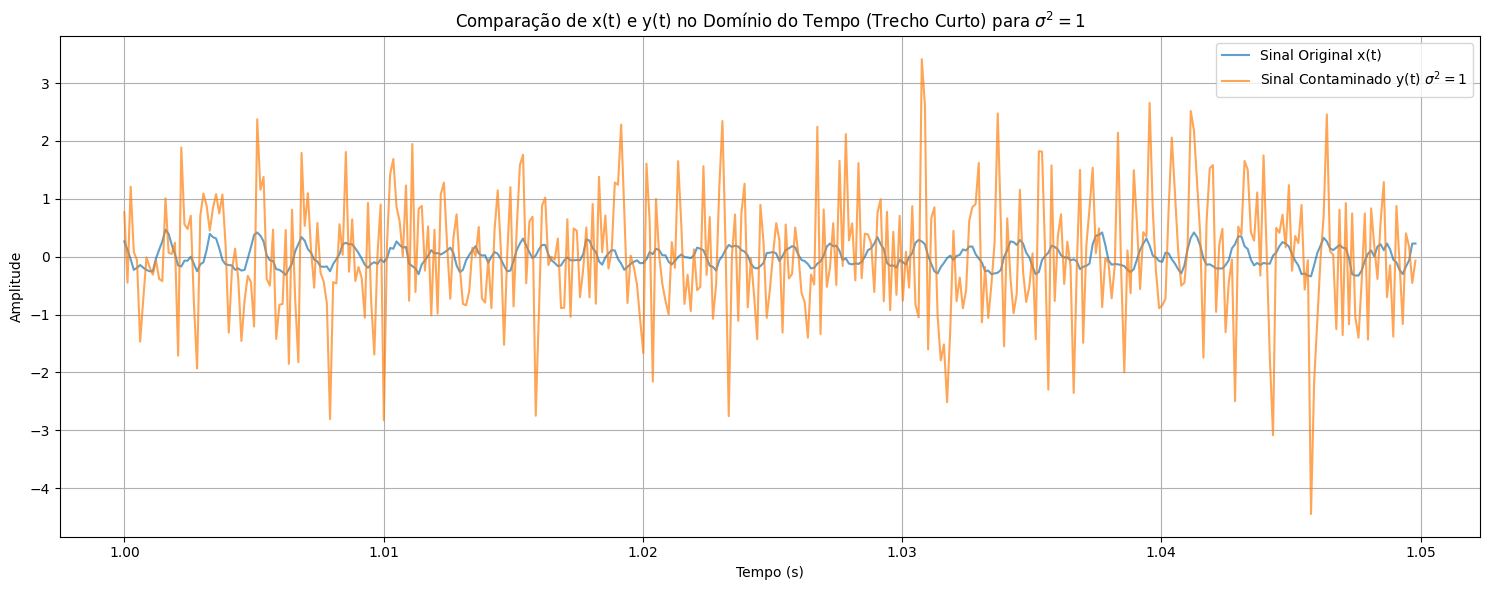

In [ ]:
for var_label, y_t_var in y_signals.items():
    plt.figure(figsize=(15, 6))

    # Plotar um pequeno trecho do sinal para melhor visualização
    start_sample = int(fs_audio * 1) # Começar em 1 segundo
    end_sample = int(fs_audio * 1.05) # Terminar em 1.05 segundos (50 ms)

    plt.plot(time[start_sample:end_sample], x_t[start_sample:end_sample], label='Sinal Original x(t)', alpha=0.7)
    plt.plot(time[start_sample:end_sample], y_t_var[start_sample:end_sample], label=r'Sinal Contaminado y(t) $\sigma^2=' + var_label + '$', alpha=0.7)
    plt.title(rf'Comparação de x(t) e y(t) no Domínio do Tempo (Trecho Curto) para $\sigma^2={var_label}$')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

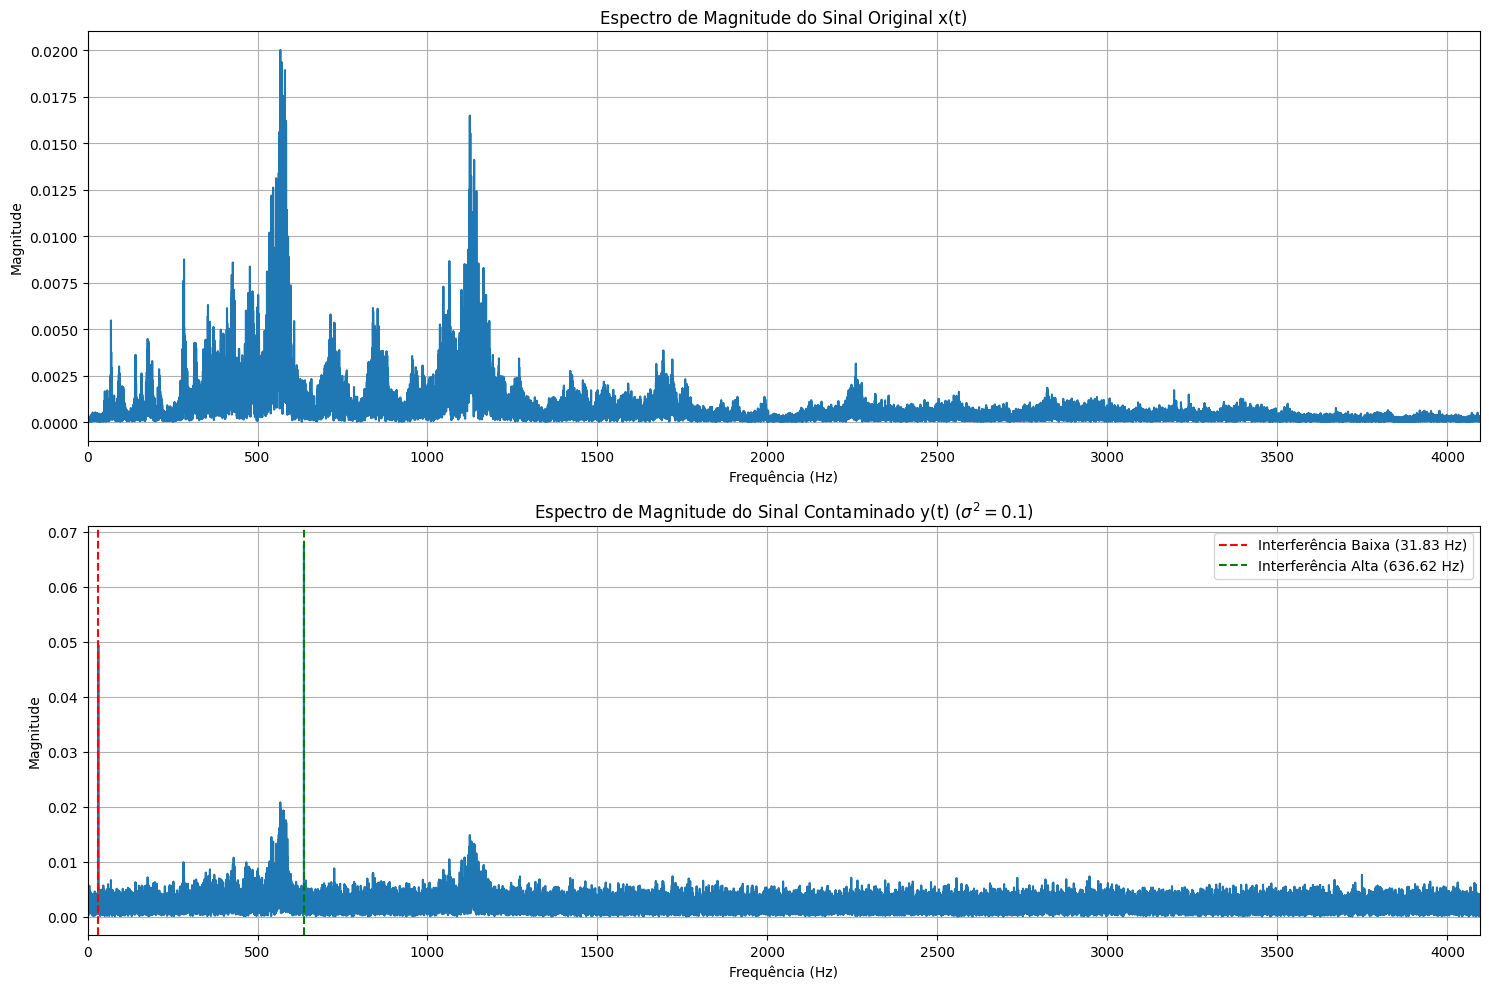

In [ ]:
def plot_spectrum(signal, fs, title, ax):
    N = len(signal)
    yf = np.fft.fft(signal)
    xf = np.fft.fftfreq(N, 1 / fs)

    # Plotar apenas a parte positiva das frequências
    ax.plot(xf[:N//2], 2/N * np.abs(yf[:N//2]))
    ax.set_title(title)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude')
    ax.grid(True)
    ax.set_xlim(0, fs / 2)

fig, axs = plt.subplots(2, 1, figsize=(15, 10))

plot_spectrum(x_t, fs_audio, 'Espectro de Magnitude do Sinal Original x(t)', axs[0])
plot_spectrum(y_t_display, fs_audio, 'Espectro de Magnitude do Sinal Contaminado y(t) ($\\sigma^2=0.1$)', axs[1])

# Adicionar marcadores para as frequências das interferências no espectro contaminado
axs[1].axvline(freq_low, color='red', linestyle='--', label=f'Interferência Baixa ({freq_low:.2f} Hz)')
axs[1].axvline(freq_high, color='green', linestyle='--', label=f'Interferência Alta ({freq_high:.2f} Hz)')
axs[1].legend()

plt.tight_layout()
plt.show()

### Comparação no Domínio da Frequência para Todas as Variâncias

Agora, vamos calcular e plotar o espectro de magnitude do sinal original `x(t)` e de cada sinal contaminado `y(t)` para todas as variâncias de ruído. Isso nos permitirá identificar visualmente as frequências das interferências adicionadas e o impacto do ruído branco.

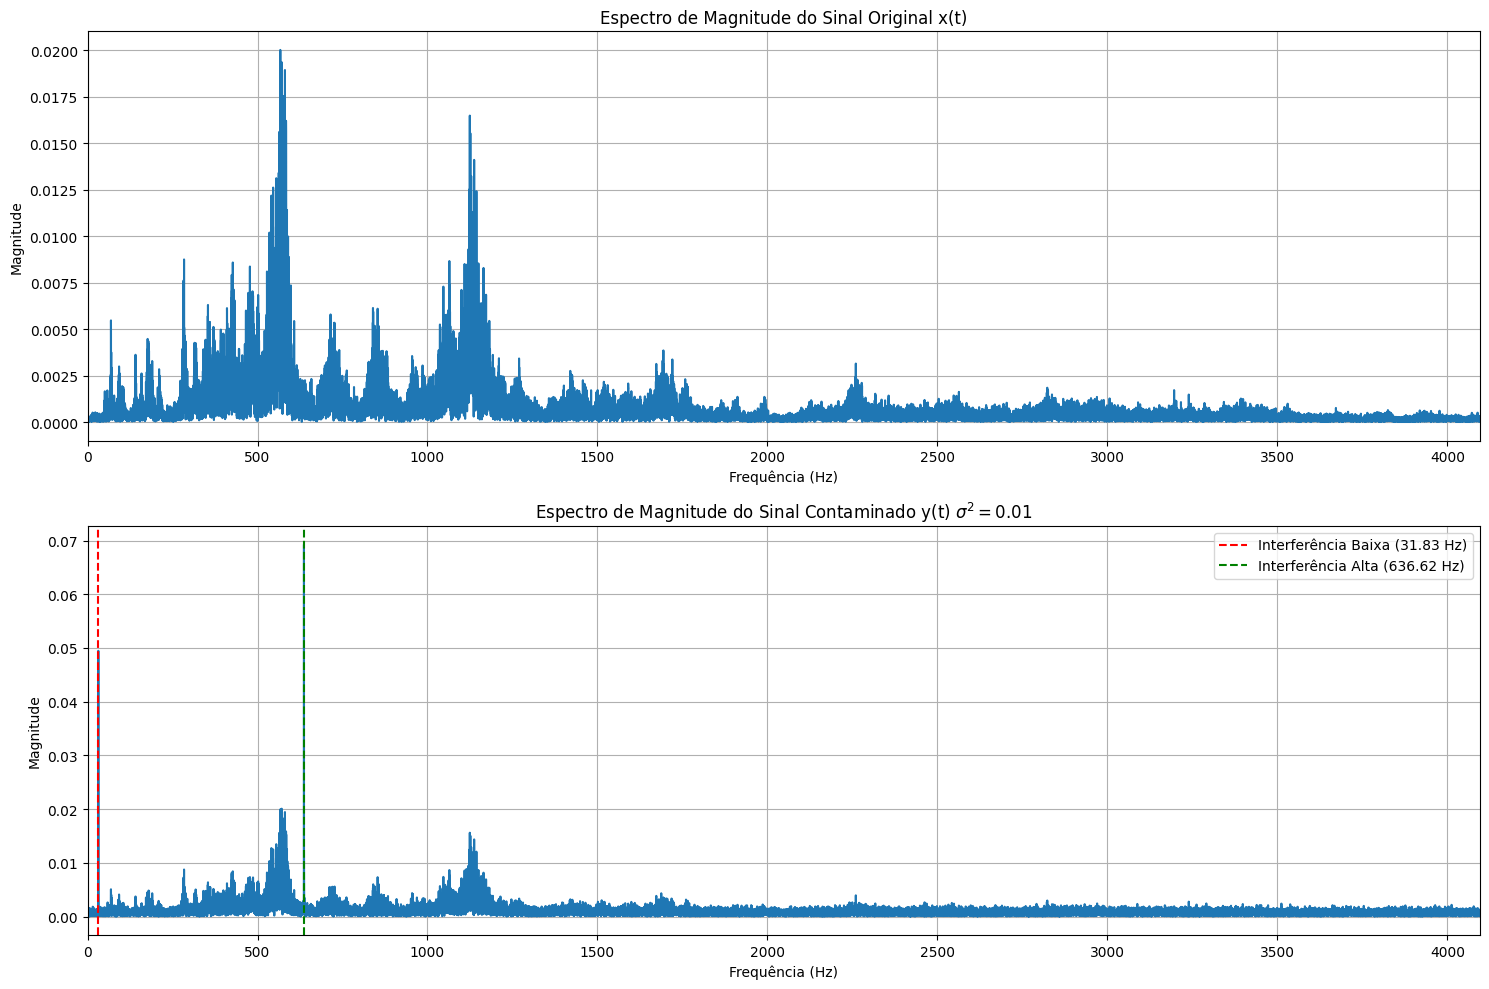

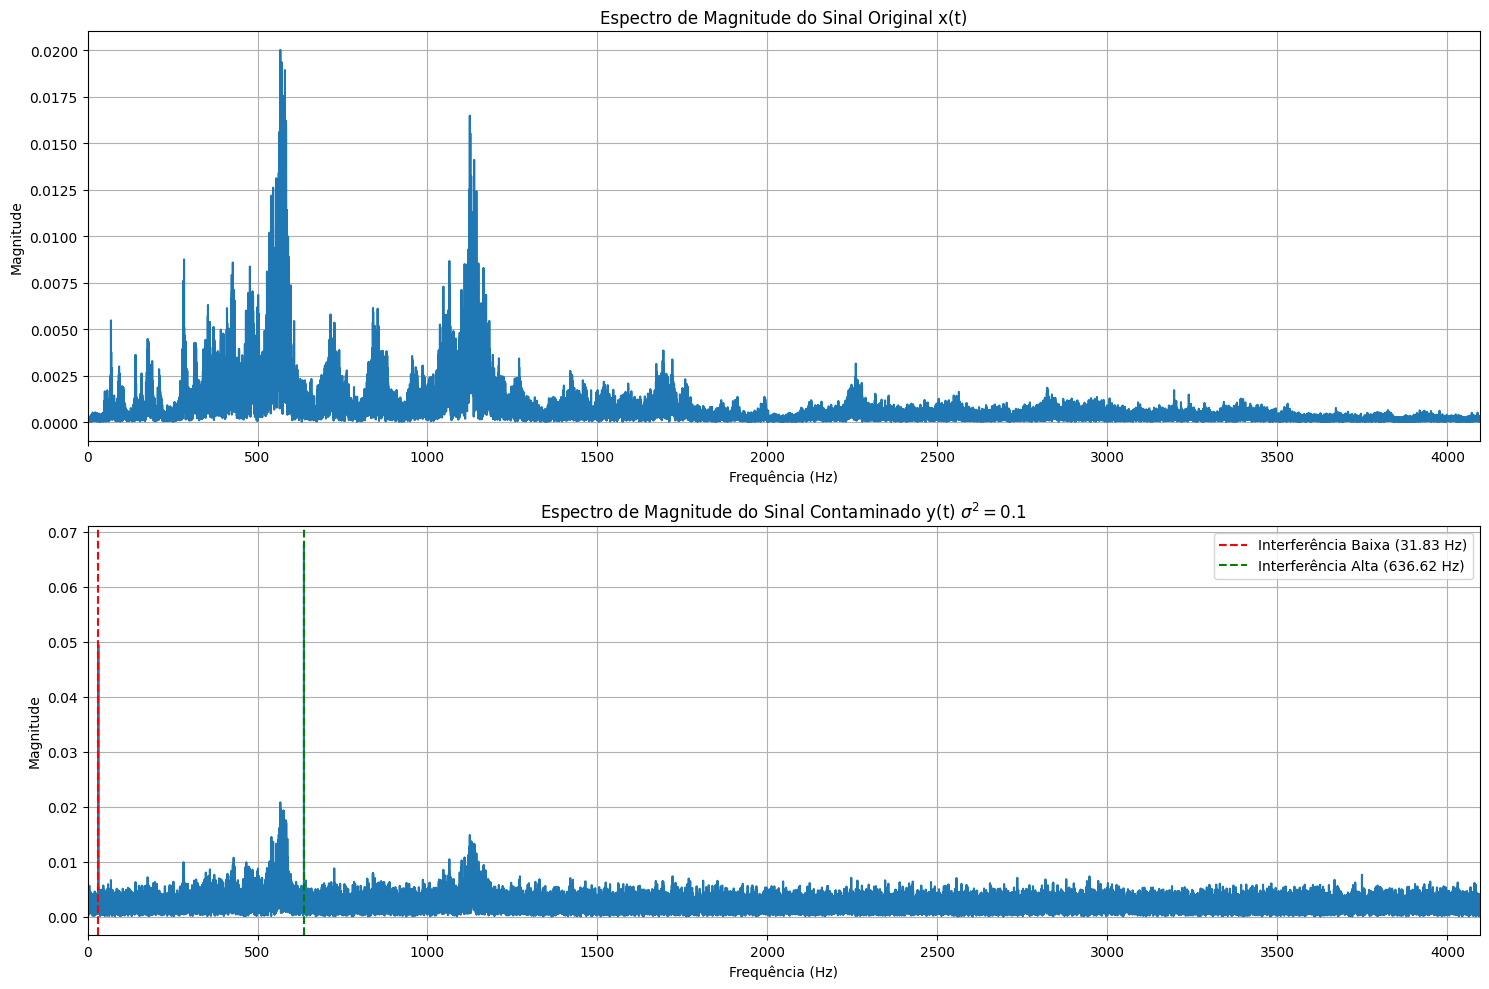

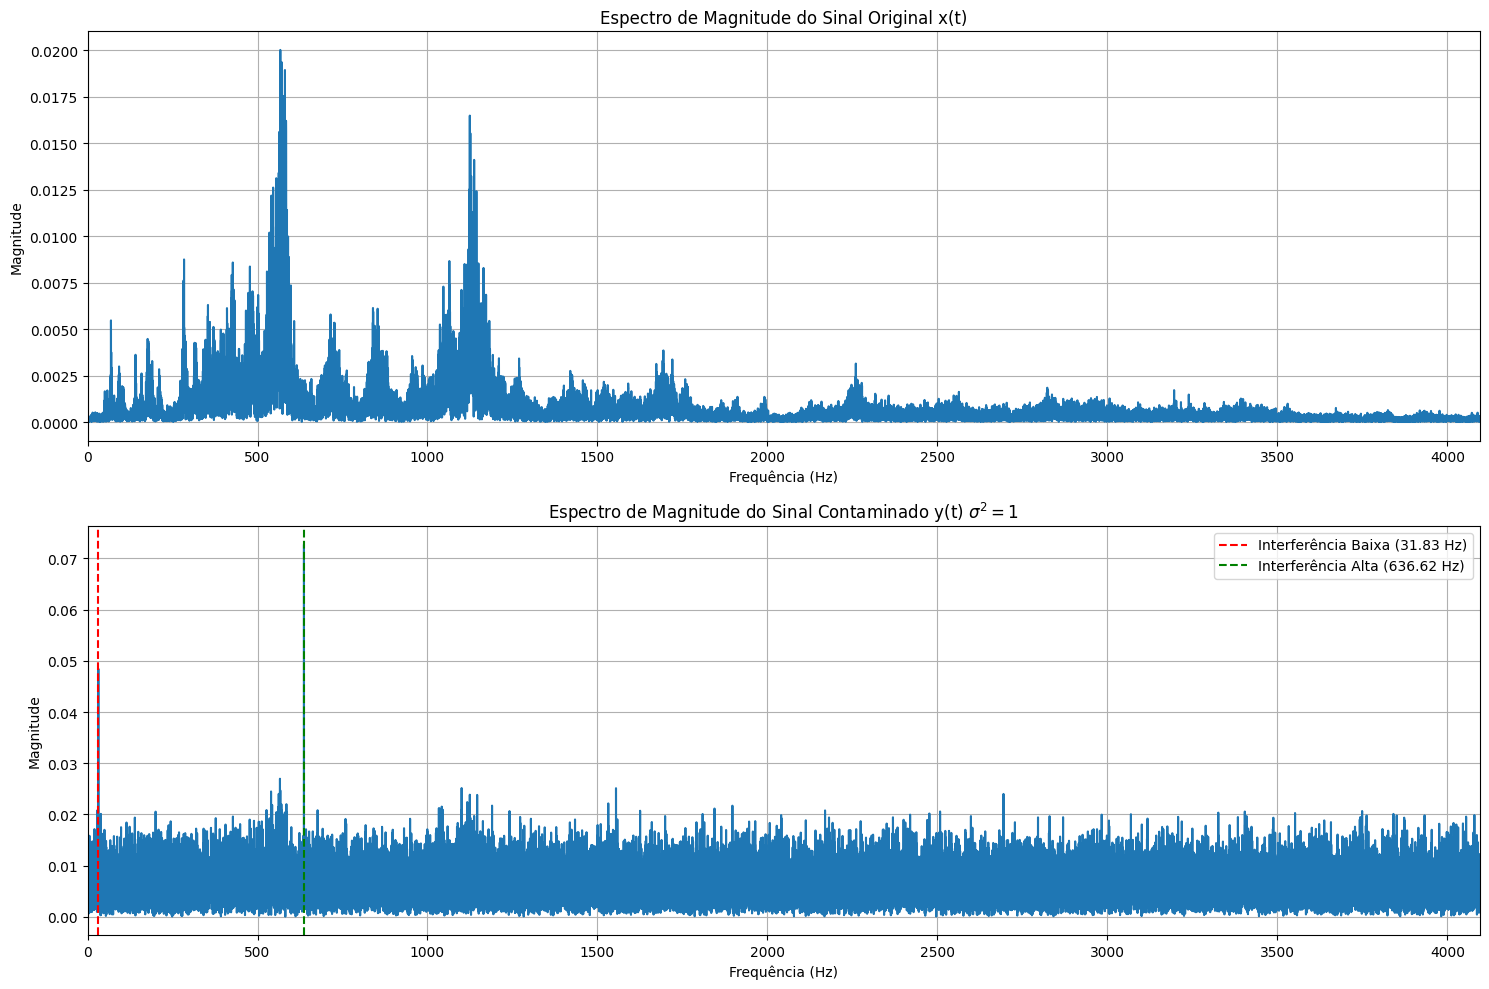

In [ ]:
for var_label, y_t_var in y_signals.items():
    fig, axs = plt.subplots(2, 1, figsize=(15, 10))

    plot_spectrum(x_t, fs_audio, 'Espectro de Magnitude do Sinal Original x(t)', axs[0])
    plot_spectrum(y_t_var, fs_audio, rf'Espectro de Magnitude do Sinal Contaminado y(t) $\sigma^2={var_label}$', axs[1])

    # Adicionar marcadores para as frequências das interferências no espectro contaminado
    axs[1].axvline(freq_low, color='red', linestyle='--', label=f'Interferência Baixa ({freq_low:.2f} Hz)')
    axs[1].axvline(freq_high, color='green', linestyle='--', label=f'Interferência Alta ({freq_high:.2f} Hz)')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

### Avaliação Subjetiva (Ouvindo os Sinais)

Para avaliar subjetivamente o impacto da contaminação, você pode ouvir o sinal original e cada uma das versões contaminadas.

#### Sinal Original x(t):

In [ ]:
Audio(x_t, rate=fs_audio)

#### Sinal Contaminado y(t) ($\sigma^2 = 0.01$):

In [ ]:
Audio(y_signals['0.01'], rate=fs_audio)

#### Sinal Contaminado y(t) ($\sigma^2 = 0.1$):

In [ ]:
Audio(y_signals['0.1'], rate=fs_audio)

#### Sinal Contaminado y(t) ($\sigma^2 = 1$):

In [ ]:
Audio(y_signals['1'], rate=fs_audio)

### Comentários sobre os Resultados Obtidos

**Domínio do Tempo:**
*   No gráfico do domínio do tempo, as oscilações das interferências sinusoidais e o ruído branco são visíveis no sinal `y(t)`. Em comparação com `x(t)`, o sinal contaminado apresenta maior amplitude e irregularidades. As interferências sinusoidais, embora com amplitudes menores que o sinal de áudio, contribuem para essa variação.

**Domínio da Frequência:**
*   O espectro de magnitude de `x(t)` mostra o conteúdo de frequência do áudio original, que é distribuído de forma mais complexa.
*   No espectro de magnitude de `y(t)`, são claramente visíveis picos proeminentes nas frequências das interferências sinusoidais (aproximadamente 31.83 Hz e 636.62 Hz). Esses picos se destacam sobre o espectro do áudio original e o "piso" de ruído.
*   O ruído branco adiciona um piso de ruído generalizado em todas as frequências, que é mais perceptível quanto maior a variância do ruído.

**Avaliação Subjetiva:**
*   Ao ouvir o sinal `y(t)` com ruído de baixa variância ($\sigma^2 = 0.01$), as interferências sinusoidais são audíveis como zumbidos ou tons, embora o áudio original ainda seja predominante. O ruído branco é sutil.
*   Com ruído de média variância ($\sigma^2 = 0.1$), as interferências se tornam mais perceptíveis, competindo com o áudio original. O ruído branco começa a dar uma característica de chiado ao sinal.
*   Para a variância de ruído mais alta ($\sigma^2 = 1$), o sinal de áudio original é significativamente mascarado pelas interferências e, principalmente, pelo ruído branco, tornando-o difícil de entender ou apreciar. O ruído é muito alto e as interferências tonais são bem evidentes.

Em resumo, a análise nos domínios do tempo e da frequência confirma a presença das interferências e do ruído, e a avaliação subjetiva reforça como esses elementos degradam a qualidade percebida do áudio, especialmente com o aumento da variância do ruído branco.

### 5b) Análise Espectral do Sinal Contaminado para Remoção de Interferências

---



Vamos agora analisar o espectro do sinal mais contaminado (`y(t)` com $\sigma^2 = 1$) para determinar as estratégias de filtragem.

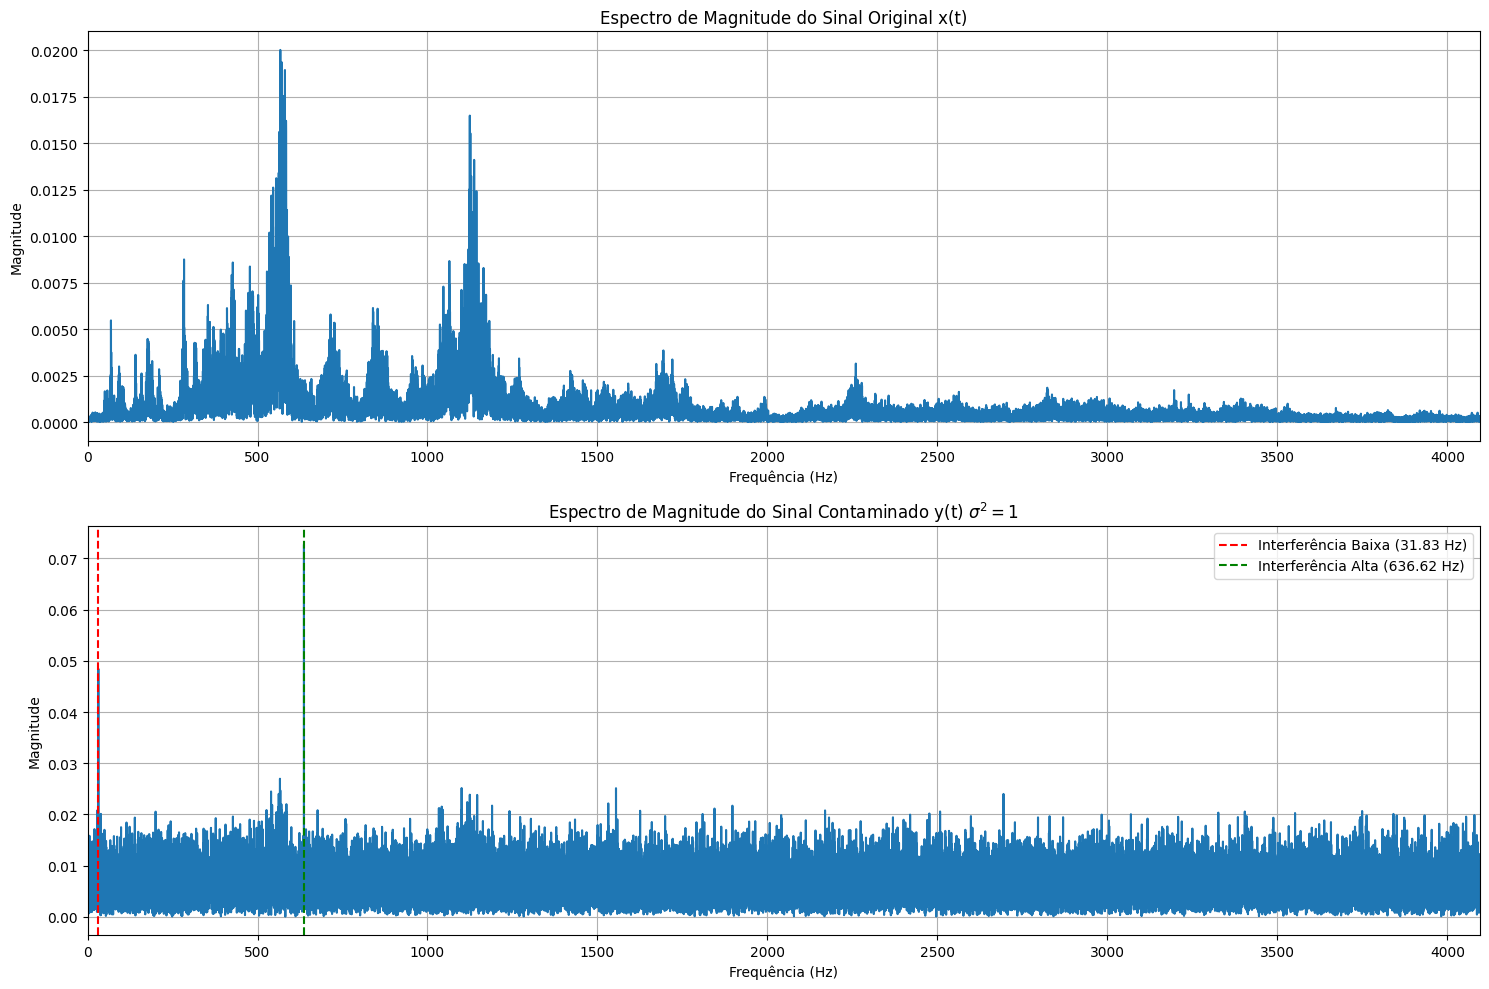

In [ ]:
# Re-plotar o espectro do sinal mais contaminado (sigma^2 = 1) para análise detalhada
fig, axs = plt.subplots(2, 1, figsize=(15, 10))

plot_spectrum(x_t, fs_audio, 'Espectro de Magnitude do Sinal Original x(t)', axs[0])
plot_spectrum(y_signals['1'], fs_audio, rf'Espectro de Magnitude do Sinal Contaminado y(t) $\sigma^2=1$', axs[1])

# Adicionar marcadores para as frequências das interferências no espectro contaminado
axs[1].axvline(freq_low, color='red', linestyle='--', label=f'Interferência Baixa ({freq_low:.2f} Hz)')
axs[1].axvline(freq_high, color='green', linestyle='--', label=f'Interferência Alta ({freq_high:.2f} Hz)')
axs[1].legend()

plt.tight_layout()
plt.show()

### Identificação de Componentes Interferentes e Estratégias de Filtragem

Com base na análise espectral do sinal contaminado (com $\sigma^2 = 1$), podemos identificar os seguintes componentes interferentes e propor estratégias de filtragem:

1.  **Componentes Interferentes Sinosoidais:**
    *   **Frequência Baixa (aproximadamente 31.83 Hz):** Observamos um pico claro e estreito nesta frequência no espectro do sinal contaminado. Este componente pode ser removido eficientemente usando um **filtro Notch** centrado em 31.83 Hz. A largura da banda de rejeição do filtro Notch pode ser ajustada (através do parâmetro `r`) para ser tão estreita quanto possível, minimizando a remoção de frequências desejadas próximas.
    *   **Frequência Alta (aproximadamente 636.62 Hz):** Similarmente, há um pico nítido nesta frequência. Este componente também seria um excelente candidato para remoção com um **filtro Notch** centrado em 636.62 Hz. Novamente, um `r` próximo a 1 (para alta seletividade) seria desejável para preservar o conteúdo de áudio adjacente.

2.  **Ruído Branco Gaussiano:**
    *   O ruído branco se manifesta como um "piso" de ruído generalizado que aumenta uniformemente em todo o espectro. Ele não possui picos de frequência específicos que possam ser removidos por filtros seletivos como o Notch, passa-altas ou passa-baixas sem impactar significativamente o sinal de áudio desejado.

3.  **Componentes que Podem Requerer Outros Filtros (Dependendo do Contexto):**
    *   Se houvesse interferências de banda larga em regiões específicas do espectro, poderíamos considerar:
        *   **Filtro Passa-Baixas:** Se a maior parte da energia do ruído ou interferência estivesse concentrada em frequências muito altas, acima da banda de interesse do áudio (e.g., acima de 4 kHz ou 8 kHz, dependendo do áudio e da `fs`), um LPF poderia ser usado para atenuá-las.
        *   **Filtro Passa-Altas:** Se houvesse ruído de baixa frequência (e.g., rumble, zumbido de transformador) abaixo da banda de áudio de interesse, um HPF poderia ser aplicado.
        *   **Filtro Passa-Faixas:** Se a banda de áudio desejada estivesse contida em uma faixa específica e houvesse ruído substancial fora dessa faixa tanto em frequências altas quanto baixas, um filtro passa-faixas poderia isolar a banda de interesse. No entanto, para este problema, onde as interferências são sinusoidais em pontos específicos e o ruído é branco, Notchs são mais apropriados para as sinusoides.

### Limitações Impostas pela Presença do Ruído Branco

A presença do ruído branco impõe as seguintes limitações:

*   **Não Removível Seletivamente:** O ruído branco, por sua natureza, tem potência distribuída uniformemente em todas as frequências. Isso significa que não podemos usar filtros de frequência seletivos (como passa-baixas, passa-altas, passa-faixas ou notch) para removê-lo sem atenuar ou remover as componentes de frequência do sinal de áudio original que são desejadas. Tentar filtrar o ruído branco com esses filtros resultaria na degradação da qualidade do áudio original.
*   **Redução da Relação Sinal-Ruído (SNR):** Aumenta o "piso" de ruído do sinal, o que reduz a relação sinal-ruído (SNR). Isso torna as componentes de áudio mais difíceis de discernir, especialmente em volumes baixos ou passagens silenciosas. Quanto maior a variância do ruído branco, pior a SNR e a inteligibilidade do sinal.
*   **Mascaramento de Interferências:** Em níveis muito altos, o ruído branco pode até mascarar as interferências sinusoidais ou outras características sutis no espectro, tornando-as mais difíceis de identificar e, consequentemente, de remover seletivamente.
*   **Necessidade de Técnicas Avançadas:** A remoção eficaz de ruído branco geralmente requer técnicas de processamento de sinal mais avançadas que não dependem apenas da filtragem no domínio da frequência, como redução de ruído adaptativa, subtrações espectrais ou métodos baseados em modelos estatísticos do ruído e do sinal. Estas técnicas visam estimar e subtrair o ruído sem danificar o sinal.